In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


## 2. Load Data
- Each function dataset has input dimensions (x1, x2, ..., x8) and output 'y'. (10 Data Points)



In [2]:
import os

try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# Dictionary to store all function datasets
functions_data = {}

for i in range(1, 9):

    # Build file paths
    function_folder = os.path.join(base_dir, f"function_{i}")
    inputs_path = os.path.join(function_folder, "initial_inputs.npy")
    outputs_path = os.path.join(function_folder, "initial_outputs.npy")

    # Load .npy arrays
    inputs = np.load(inputs_path)
    outputs = np.load(outputs_path)


    # Reshape to 2D if needed
    if inputs.ndim == 1:
        inputs = inputs.reshape(-1, 1)
    if outputs.ndim == 1:
        outputs = outputs.reshape(-1, 1)

    # Create column names (temporary)
    input_cols = [f"input_{j}" for j in range(inputs.shape[1])]
    output_cols = [f"output_{j}" for j in range(outputs.shape[1])]
    
    # Concatenate inputs + outputs
    combined = np.concatenate([inputs, outputs], axis=1)
    df_combined = pd.DataFrame(combined, columns=input_cols + output_cols)


    # Rename columns in-place
    new_input_names = {col: f"X{j+1}" for j, col in enumerate(input_cols)}
    new_output_names = {col: f"y{j+1}" for j, col in enumerate(output_cols)}
    df_combined.rename(columns={**new_input_names, **new_output_names}, inplace=True)


    # Store in dictionary
    functions_data[f"f{i}"] = df_combined

    print(f"Loaded function {i}: shape = {df_combined.shape}, columns = {df_combined.columns.tolist()}")


Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 1: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 2: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 3: shape = (15, 4), columns = ['X1', 'X2', 'X3', 'y1']
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 5: shape = (20, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']
Loaded function 8: shape = (40, 9), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'y1']


In [3]:
# Manually define Week 1 submission results
week1_results = {
    "f1": ([0.793600, 0.666269], 1.4034986520274933e-21),
    "f2": ([0.554975, 0.999446], -0.07640833812988071),
    "f3": ([0.389233, 0.386084, 0.558916], -0.04116779016532328),
    "f4": ([0.439369, 0.276427, 0.360198, 0.470119], -1.8014266350928305),
    "f5": ([0.037069, 0.974641, 0.864911, 0.019169], 684.5607486761136),
    "f6": ([0.363643, 0.001300, 0.920810, 0.821416, 0.136085], -0.6872415681590064),
    "f7": ([0.799542, 0.949047, 0.887638, 0.265662, 0.631518, 0.349925], 0.026543407526137847),
    "f8": ([0.311992, 0.966526, 0.355002, 0.358409, 0.551500, 0.690176, 0.717450, 0.542367], 8.4452078666581),
}

In [4]:
week2_results = {
    "f1": ([0.800601, 0.002800], 9.069108791316283e-223),
    "f2": ([0.999500, 0.001800], -0.07975546223482953),
    "f3": ([0.967200, 0.029200, 0.723300], -0.20496612752890705),
    "f4": ([0.542100, 0.336200, 0.419500, 0.404000], -2.041748838194795),
    "f5": ([0.624000, 0.735500, 0.976700, 0.994100], 2434.328593289806),
    "f6": ([0.666300, 0.229100, 0.516000, 0.821600, 0.201500], -0.5648568336407203),
    "f7": ([0.008500, 0.278800, 0.231600, 0.099300, 0.323000, 0.980800], 0.7653612109103147),
    "f8": ([0.293300, 0.174300, 0.080500, 0.056000, 0.429100, 0.492300, 0.221400, 0.410200], 9.835131961),
}

In [5]:
week3_results = {
    "f1": ([0.729726, 0.729276], 5.31459276351908e-15),
    "f2": ([0.727681, 0.187140], 0.5037032225936308),
    "f3": ([0.437962, 0.715305, 0.000876], -0.1117676821078815),
    "f4": ([0.402906, 0.437778, 0.329101, 0.424377], 0.07045398603133579),
    "f5": ([0.898795, 0.963833, 1.000000, 0.791851], 4171.124196806389),
    "f6": ([0.416408, 0.263572, 0.345102, 1.000000, 0.000000], -0.7670334120297669),
    "f7": ([0.000000, 0.189754, 0.123991, 0.253411, 0.406355, 0.251864], 0.4981320924641522),
    "f8": ([0.190768, 0.209525, 0.202591, 0.198246, 0.813824, 0.387519, 0.200772, 0.663670], 9.948688972661),
}

In [6]:
week4_results = {
    "f1": ([0.732162, 0.364472], 5.473776123300507e-57),
    "f2": ([0.715483, 0.563901], 0.5661662506769448),
    "f3": ([0.387933, 0.405240, 0.580181], -0.041279121306865105),
    "f4": ([0.351926, 0.442039, 0.451511, 0.443953], -0.27637133038944084),
    "f5": ([0.072013, 0.315203, 0.125702, 0.883341], 15.250051561683966),
    "f6": (	[0.494472, 0.050000, 0.451934, 0.152883, 0.386469], -1.421729209627387),
    "f7": ([0.097366, 0.334928, 0.369818, 0.382418, 0.464971, 0.750762], 1.5985145628892428),
}

In [7]:
week5_results = {
    "f1": ([0.812650, 0.143347], -1.0629331180647184e-161),
    "f2": ([0.678746, 0.850809], 0.6824523528240423),
    "f3": ([0.688252, 0.924125, 0.842251], -0.05314656740717209),
    "f4": ([0.342113, 0.430851, 0.327587, 0.458906], -0.49820890718197175),
    "f5": ([0.260034, 0.558879, 0.984293, 0.063132], 225.88673947929044),
    "f6": ([0.666300, 0.229100, 0.516000, 0.789473, 0.315789], -0.7791148650103992),
    "f7": ([0.053955, 0.757891, 0.608290, 0.473788, 0.364363, 0.971498], 0.32752252967109274),
    "f8": ([0.325520, 0.209525, 0.057274, 0.198246, 0.813824, 0.387519, 0.169663, 0.663670], 9.861549762954),
}

In [8]:
week6_results = {
    "f1": ([0.079265, 0.909848], 2.6078826238924974e-248),
    "f2": ([0.653993, 0.981188], 0.3798198130144502),
    "f3": ([0.788392, 0.913423, 0.403090], -0.03637482131814577),
    "f4": ([0.378009, 0.410452, 0.389136, 0.370426], 0.34655132659709453),
    "f5": ([0.000000, 0.856410, 1.000000, 0.433460], 849.8436606636637),
    "f6": ([0.537637, 0.403865, 0.951610, 0.943059, 0.050967], -0.6814591029200937),
    "f7": ([0.069772, 0.319669, 0.577421, 0.210909, 0.386068, 0.707262], 2.448290856114691),
    "f8": ([0.924338, 0.001471, 0.948665, 0.928797, 0.142329, 0.071686, 0.034416, 0.347751], 5.5407934131584),
}

In [9]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
}

for week, results in weekly_results.items():
    for func, (inputs, output) in results.items():
        # Convert inputs and outputs to DataFrame
        inputs = np.array(inputs).reshape(1, -1)
        output = np.array([output]).reshape(1, -1)
        
        # Dynamically generate input column names
        df_inputs = pd.DataFrame(inputs, columns=[f"X{i+1}" for i in range(inputs.shape[1])])
        # Use existing output column names from the function
        output_cols = [col for col in functions_data[func].columns if col.startswith("y")]
        df_outputs = pd.DataFrame(output, columns=output_cols)
        
        # Combine
        df_week = pd.concat([df_inputs, df_outputs], axis=1)
        
        # Append only rows that are not already in the DataFrame
        functions_data[func] = pd.concat([functions_data[func], df_week], ignore_index=True)
        functions_data[func] = functions_data[func].drop_duplicates(ignore_index=True)

# Optional: check updated shapes
for func, df in functions_data.items():
    print(f"{func} updated shape: {df.shape}")


f1 updated shape: (16, 3)
f2 updated shape: (16, 3)
f3 updated shape: (21, 4)
f4 updated shape: (36, 5)
f5 updated shape: (26, 5)
f6 updated shape: (26, 6)
f7 updated shape: (36, 7)
f8 updated shape: (45, 9)


In [10]:
for name, df in functions_data.items():
    print(df)

          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
14  0.812650  0.143347 -1.062933e-161
15  0.079265  0.909848  2.607883e-248
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  

In [11]:
for name, df in functions_data.items():
    print(f"\n{name} Summary Statistics")
    
    # Display numeric summary statistics
    display(df.describe().T)  # Transposed for easier reading (features as rows)





f1 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,16.0,0.589761,0.265506,0.079265,3.876788e-01,7.065721e-01,7.953503e-01,8.838898e-01
X2,16.0,0.513200,0.310094,0.002800,2.354373e-01,6.242615e-01,7.404898e-01,9.098480e-01
y1,16.0,-0.000225,0.000902,-0.003606,-2.657333e-162,6.793724e-80,6.337511e-41,5.314593e-15



f2 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,16.0,0.607219,0.222662,0.142699,0.450527,0.659896,0.718533,0.999500
X2,16.0,0.528974,0.352634,0.001800,0.207185,0.624460,0.796673,0.999446
y1,16.0,0.267670,0.269581,-0.079755,0.013865,0.269306,0.512526,0.682452



f3 Summary Statistics


...

,count,mean,std,min,25%,50%,75%,max
X1,26.0,0.542310,0.270257,0.021735,0.376834,0.578225,0.750576,0.957740
X2,26.0,0.478013,0.300478,0.001300,0.242644,0.379848,0.782285,0.931871
X3,26.0,0.501761,0.304502,0.016523,0.342640,0.483967,0.726444,0.978806
X4,26.0,0.585272,0.295590,0.045613,0.364471,0.679768,0.813430,1.000000
X5,26.0,0.367912,0.287115,0.000000,0.111077,0.322312,0.596788,0.892819
y1,26.0,-1.338817,0.514784,-2.571170,-1.688808,-1.301682,-0.855867,-0.564857



f7 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,36.0,0.454297,0.326667,0.000000,0.113492,0.502660,0.771175,0.942451
X2,36.0,0.408449,0.258963,0.011813,0.202224,0.359191,0.564890,0.949047
X3,36.0,0.402417,0.306182,0.003635,0.118830,0.350832,0.626816,0.924571
X4,36.0,0.474169,0.301313,0.073659,0.218109,0.401401,0.769030,0.961017
X5,36.0,0.460897,0.289821,0.014944,0.242170,0.417030,0.698286,0.998655
X6,36.0,0.515367,0.280089,0.051100,0.321010,0.602159,0.728771,0.980800
y1,36.0,0.340349,0.521163,0.002701,0.020559,0.094028,0.502713,2.448291



f8 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,45.0,0.520673,0.308115,0.009077,0.293300,0.506028,0.791888,0.985945
X2,45.0,0.454385,0.316917,0.001471,0.174300,0.482734,0.699506,0.973980
X3,45.0,0.495174,0.293994,0.022929,0.269548,0.420888,0.729546,0.998885
X4,45.0,0.421281,0.268171,0.009043,0.180148,0.424597,0.662216,0.928797
X5,45.0,0.477969,0.279493,0.009649,0.240298,0.429100,0.730693,0.986902
X6,45.0,0.454094,0.270282,0.022113,0.245548,0.409325,0.690176,0.990244
X7,45.0,0.544701,0.273676,0.034416,0.276241,0.591030,0.762483,0.992914
X8,45.0,0.508810,0.268499,0.041956,0.313683,0.525348,0.715962,0.988755
y1,45.0,7.916497,1.105694,5.540793,7.299872,7.957875,8.606117,9.948689


#### Pearson Correlation


f1 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,-0.123094,-0.060617
X2,-0.123094,1.000000,-0.144753
y1,-0.060617,-0.144753,1.000000


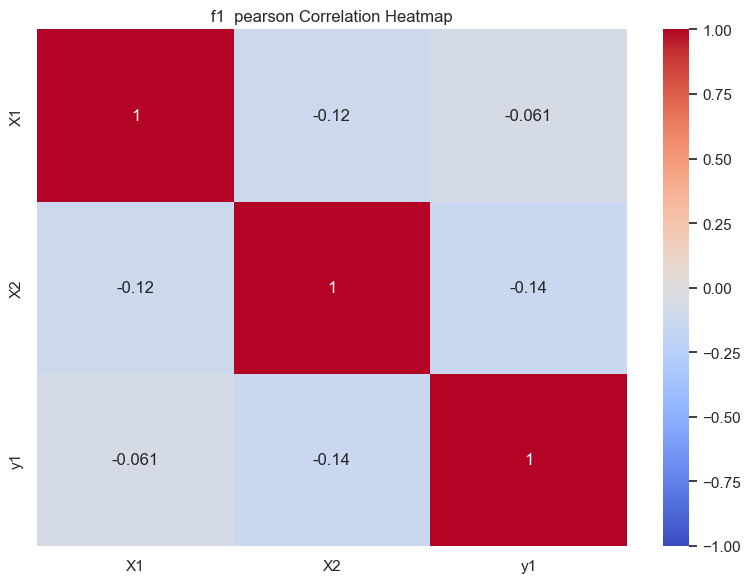


f2 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.173543,0.426512
X2,0.173543,1.000000,0.292896
y1,0.426512,0.292896,1.000000


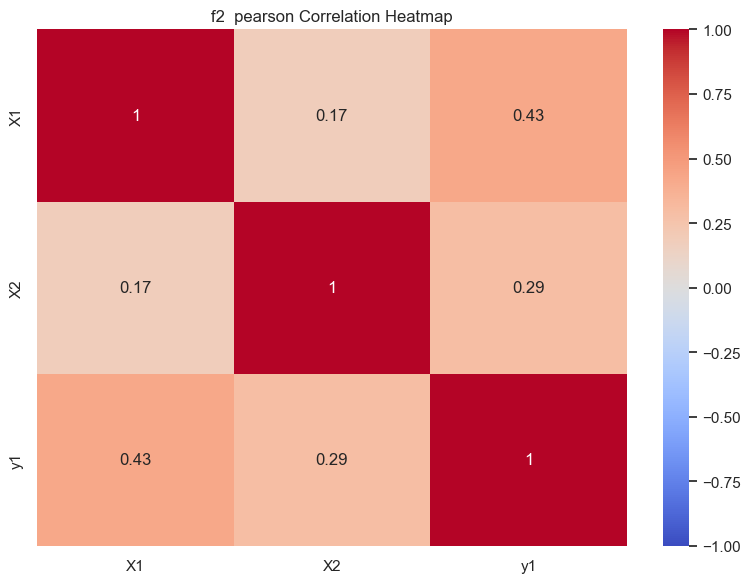


f3 Pearson Correlation Matrix


,X1,X2,X3,y1
X1,1.000000,0.233656,0.062134,0.133524
X2,0.233656,1.000000,-0.260279,0.290104
X3,0.062134,-0.260279,1.000000,-0.406759
y1,0.133524,0.290104,-0.406759,1.000000


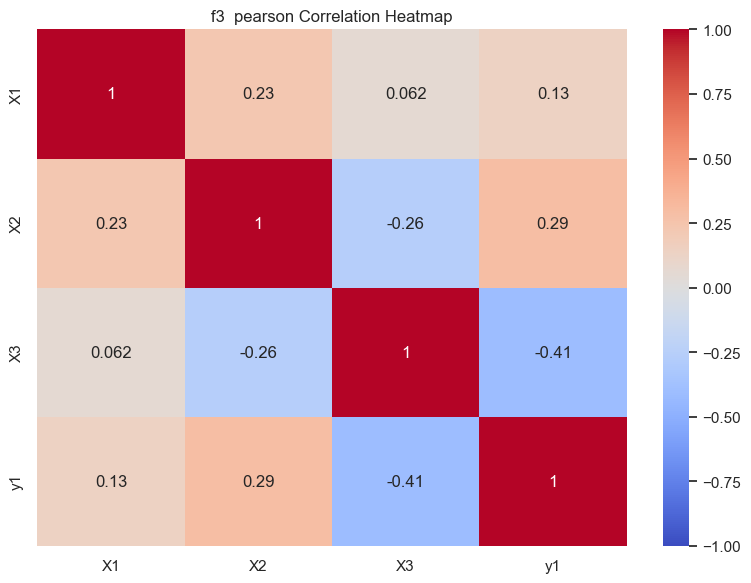


f4 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,0.256331,0.267698,0.195924,-0.510965
X2,0.256331,1.000000,-0.062587,0.191802,-0.423256
X3,0.267698,-0.062587,1.000000,-0.144744,-0.154439
X4,0.195924,0.191802,-0.144744,1.000000,-0.427139
y1,-0.510965,-0.423256,-0.154439,-0.427139,1.000000


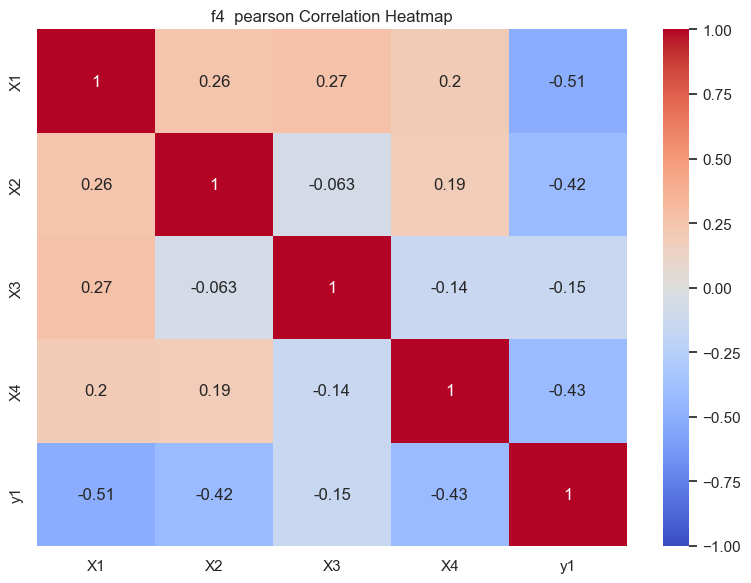


f5 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,-0.139237,-0.097574,0.218901,0.256951
X2,-0.139237,1.000000,0.244468,0.119899,0.466672
X3,-0.097574,0.244468,1.000000,-0.160046,0.532043
X4,0.218901,0.119899,-0.160046,1.000000,0.360196
y1,0.256951,0.466672,0.532043,0.360196,1.000000


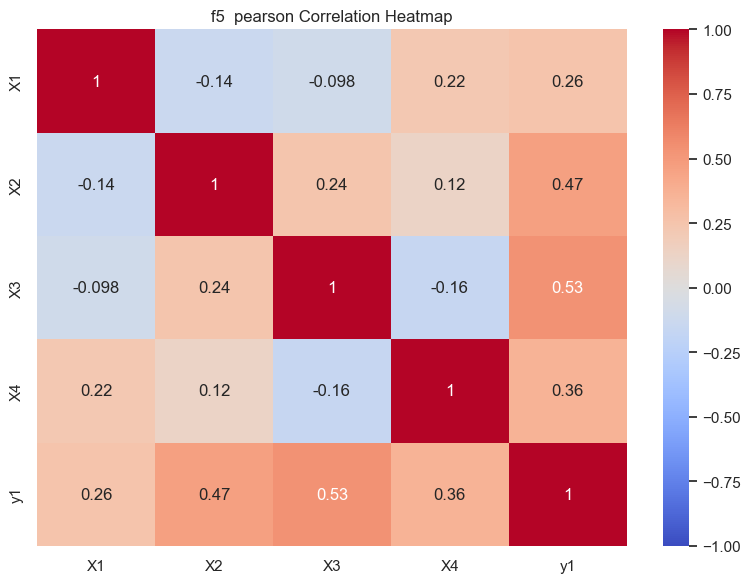


f6 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.190388,-0.068649,0.126655,-0.356531,0.061472
X2,-0.190388,1.000000,0.128555,-0.205284,0.324242,-0.481899
X3,-0.068649,0.128555,1.000000,0.254315,-0.194955,0.337905
X4,0.126655,-0.205284,0.254315,1.000000,-0.360215,0.634777
X5,-0.356531,0.324242,-0.194955,-0.360215,1.000000,-0.655822
y1,0.061472,-0.481899,0.337905,0.634777,-0.655822,1.000000


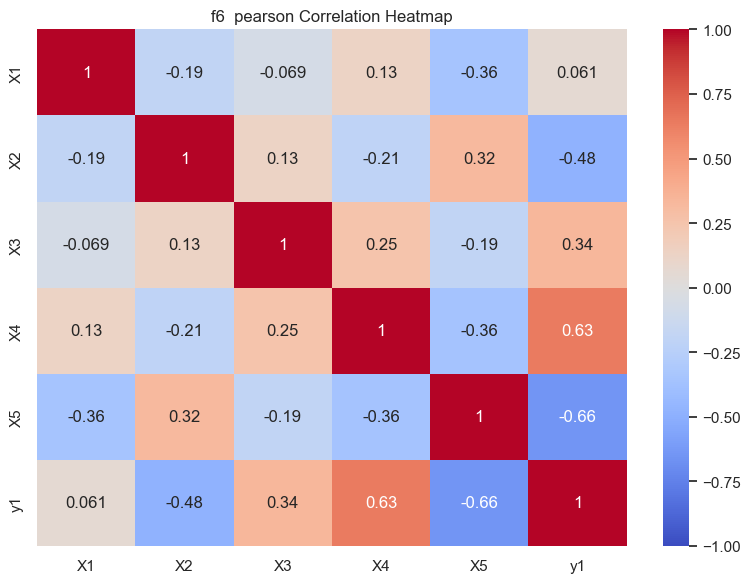


f7 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.015975,-0.113662,-0.016851,0.035492,-0.497328,-0.462942
X2,0.015975,1.000000,0.099587,0.133115,0.316533,0.172548,-0.082375
X3,-0.113662,0.099587,1.000000,0.180010,-0.252389,0.078660,0.107262
X4,-0.016851,0.133115,0.180010,1.000000,0.075589,-0.011636,-0.209298
X5,0.035492,0.316533,-0.252389,0.075589,1.000000,0.041728,-0.256305
X6,-0.497328,0.172548,0.078660,-0.011636,0.041728,1.000000,0.342832
y1,-0.462942,-0.082375,0.107262,-0.209298,-0.256305,0.342832,1.000000


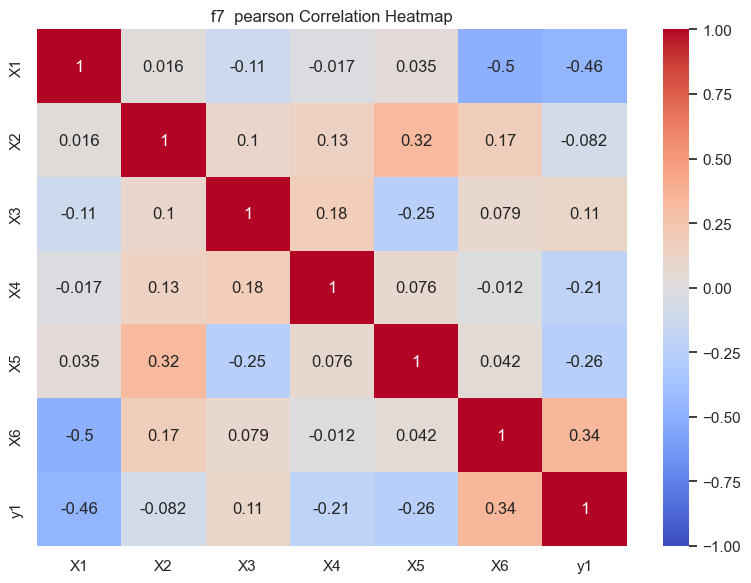


f8 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.121652,0.151582,0.206359,0.171512,0.106780,0.145730,0.088558,-0.659374
X2,0.121652,1.000000,0.078982,-0.193467,0.072485,0.067218,-0.010383,-0.245058,-0.192139
X3,0.151582,0.078982,1.000000,0.184400,-0.141143,-0.224452,-0.110521,-0.038730,-0.703163
X4,0.206359,-0.193467,0.184400,1.000000,-0.132370,-0.158705,-0.082588,0.316001,-0.273896
X5,0.171512,0.072485,-0.141143,-0.132370,1.000000,0.107954,0.151168,0.101011,0.024470
X6,0.106780,0.067218,-0.224452,-0.158705,0.107954,1.000000,0.058661,0.071306,0.115200
X7,0.145730,-0.010383,-0.110521,-0.082588,0.151168,0.058661,1.000000,-0.123179,-0.276014
X8,0.088558,-0.245058,-0.038730,0.316001,0.101011,0.071306,-0.123179,1.000000,0.107048
y1,-0.659374,-0.192139,-0.703163,-0.273896,0.024470,0.115200,-0.276014,0.107048,1.000000


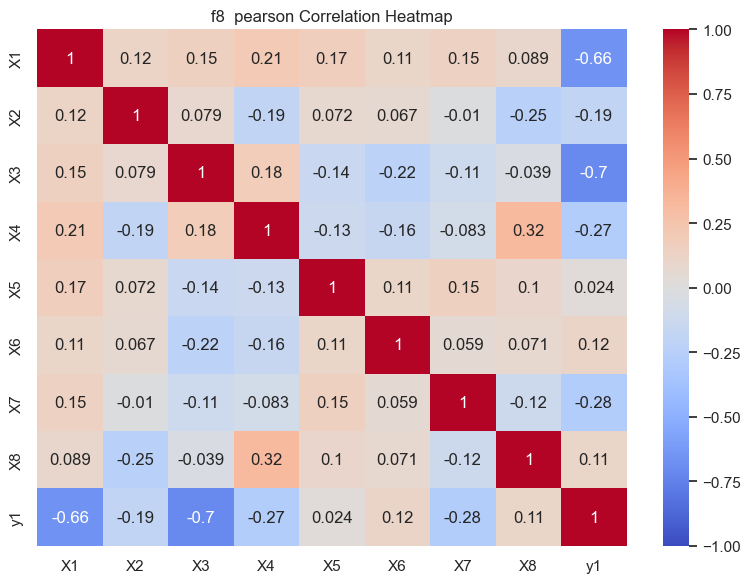

In [12]:
for name, df in functions_data.items():

    print(f"\n{name} Pearson Correlation Matrix")
    
    # Compute correlation matrix
    corr = df.corr()

    # Display numeric correlation table
    display(corr)

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1
    )
    plt.title(f"{name}  pearson Correlation Heatmap")
    plt.tight_layout()
    plt.show()

#### Spearman Correlation


f1 — Spearman Correlation


,X1,X2,y1
X1,1.000000,-0.367647,0.264706
X2,-0.367647,1.000000,0.488235
y1,0.264706,0.488235,1.000000


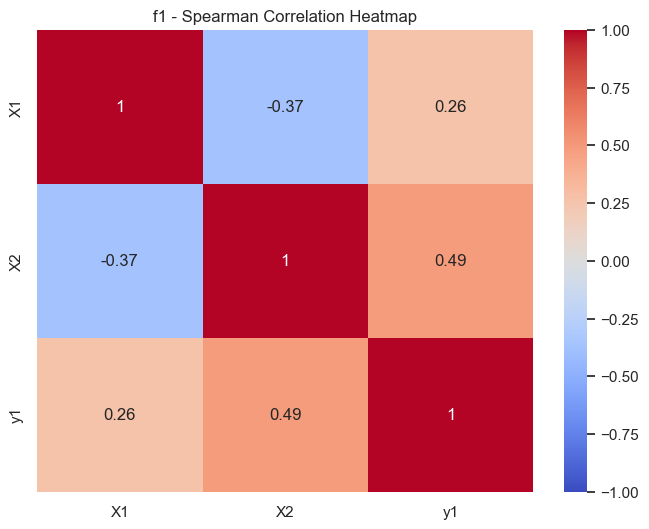


f2 — Spearman Correlation


,X1,X2,y1
X1,1.000000,0.061765,0.411765
X2,0.061765,1.000000,0.258824
y1,0.411765,0.258824,1.000000


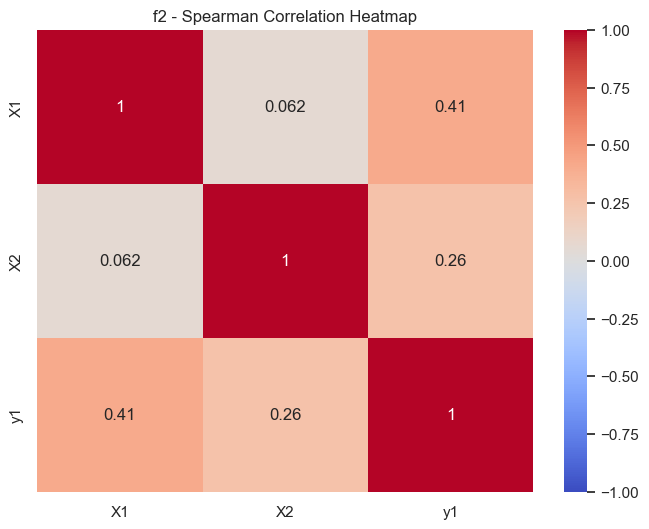


f3 — Spearman Correlation


,X1,X2,X3,y1
X1,1.000000,0.274026,-0.006494,0.081818
X2,0.274026,1.000000,-0.233766,0.364935
X3,-0.006494,-0.233766,1.000000,-0.131169
y1,0.081818,0.364935,-0.131169,1.000000


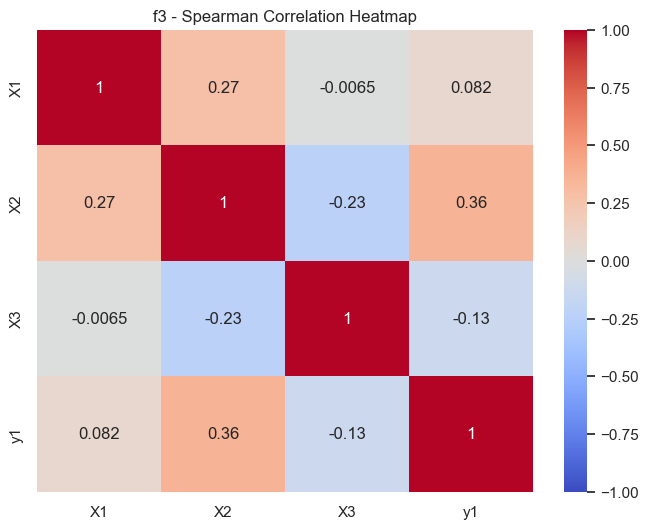


f4 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.267954,0.266152,0.195624,-0.508366
X2,0.267954,1.000000,-0.007465,0.170914,-0.440669
X3,0.266152,-0.007465,1.000000,-0.179151,-0.166023
X4,0.195624,0.170914,-0.179151,1.000000,-0.380695
y1,-0.508366,-0.440669,-0.166023,-0.380695,1.000000


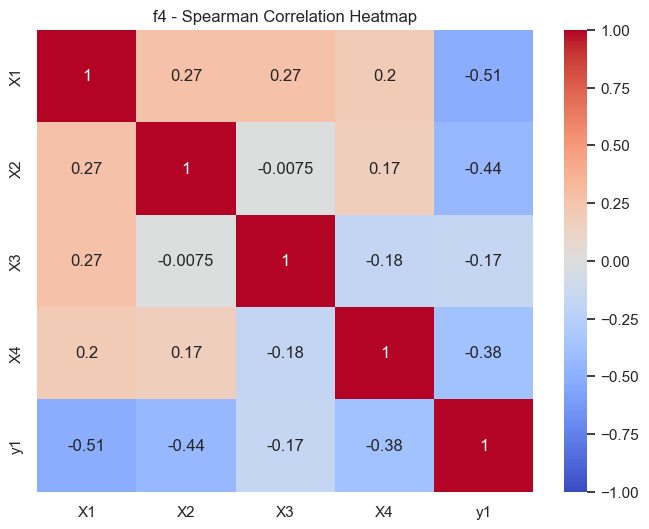


f5 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.200000,-0.113524,0.182906,-0.057094
X2,-0.200000,1.000000,0.333390,0.100855,0.470769
X3,-0.113524,0.333390,1.000000,-0.188066,0.580612
X4,0.182906,0.100855,-0.188066,1.000000,0.338803
y1,-0.057094,0.470769,0.580612,0.338803,1.000000


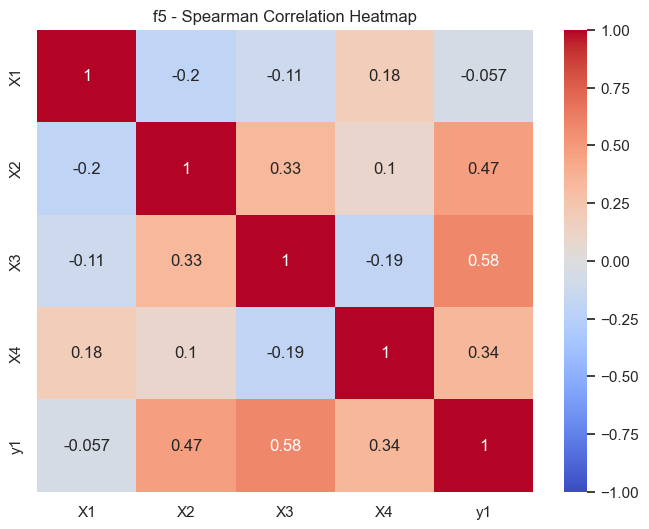


f6 — Spearman Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.139535,-0.042408,0.150111,-0.337836,-0.031458
X2,-0.139535,1.000000,0.075239,-0.175415,0.250299,-0.398017
X3,-0.042408,0.075239,1.000000,0.288254,-0.218157,0.324842
X4,0.150111,-0.175415,0.288254,1.000000,-0.441368,0.654701
X5,-0.337836,0.250299,-0.218157,-0.441368,1.000000,-0.638974
y1,-0.031458,-0.398017,0.324842,0.654701,-0.638974,1.000000


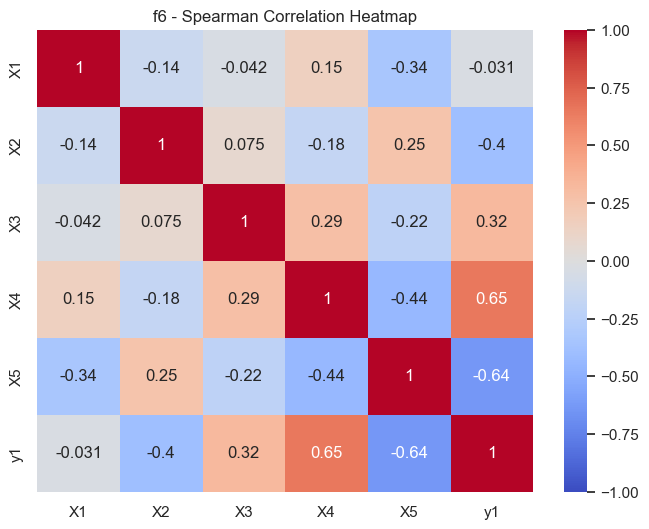


f7 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.022394,-0.099356,-0.007465,-0.004118,-0.472587,-0.484427
X2,-0.022394,1.000000,0.070785,0.208494,0.340026,0.154955,-0.148520
X3,-0.099356,0.070785,1.000000,0.131532,-0.253024,0.128443,0.256628
X4,-0.007465,0.208494,0.131532,1.000000,0.075161,0.039897,-0.172458
X5,-0.004118,0.340026,-0.253024,0.075161,1.000000,0.013642,-0.419048
X6,-0.472587,0.154955,0.128443,0.039897,0.013642,1.000000,0.330502
y1,-0.484427,-0.148520,0.256628,-0.172458,-0.419048,0.330502,1.000000


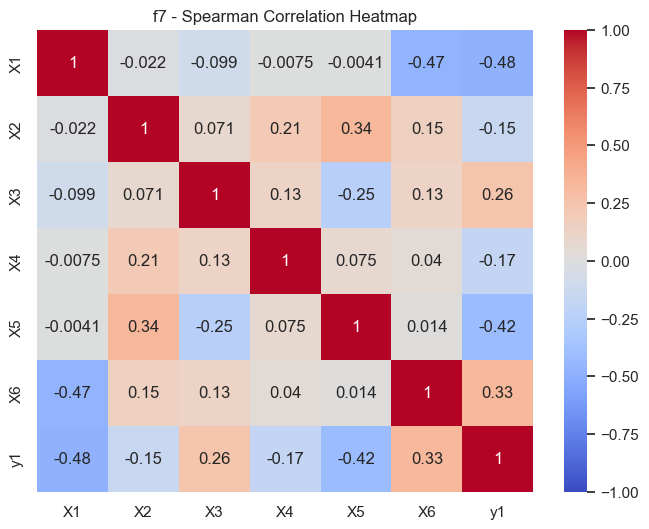


f8 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.123983,0.131357,0.197371,0.167463,0.102111,0.132411,0.068250,-0.648353
X2,0.123983,1.000000,0.099542,-0.202451,0.054747,0.052243,-0.004282,-0.228144,-0.211404
X3,0.131357,0.099542,1.000000,0.212326,-0.147502,-0.205079,-0.080501,-0.086366,-0.663636
X4,0.197371,-0.202451,0.212326,1.000000,-0.144871,-0.187166,-0.059488,0.295606,-0.258177
X5,0.167463,0.054747,-0.147502,-0.144871,1.000000,0.145530,0.151718,0.076092,0.043019
X6,0.102111,0.052243,-0.205079,-0.187166,0.145530,1.000000,0.073454,0.116806,0.071873
X7,0.132411,-0.004282,-0.080501,-0.059488,0.151718,0.073454,1.000000,-0.115616,-0.306851
X8,0.068250,-0.228144,-0.086366,0.295606,0.076092,0.116806,-0.115616,1.000000,0.106525
y1,-0.648353,-0.211404,-0.663636,-0.258177,0.043019,0.071873,-0.306851,0.106525,1.000000


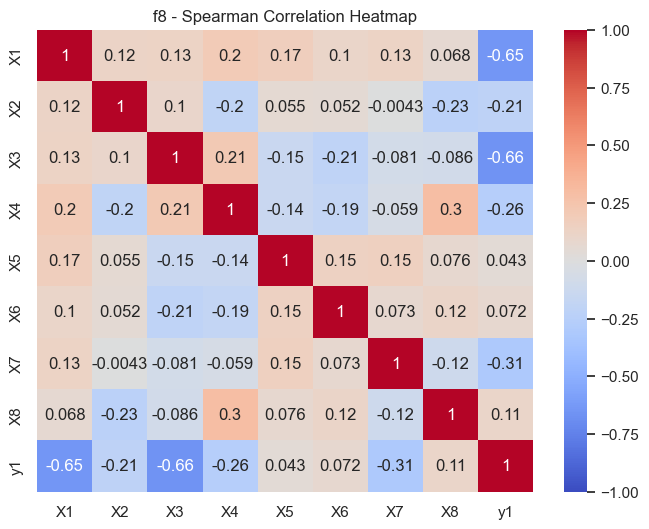

In [13]:
for name, df in functions_data.items():
    print(f"\n{name} — Spearman Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    spearman_corr = df[input_cols + output_cols].corr(method='spearman')
    display(spearman_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Spearman Correlation Heatmap")
    plt.show()

#### Kendall Correlation


f1 — Kendall Correlation


,X1,X2,y1
X1,1.000000,-0.283333,0.166667
X2,-0.283333,1.000000,0.350000
y1,0.166667,0.350000,1.000000


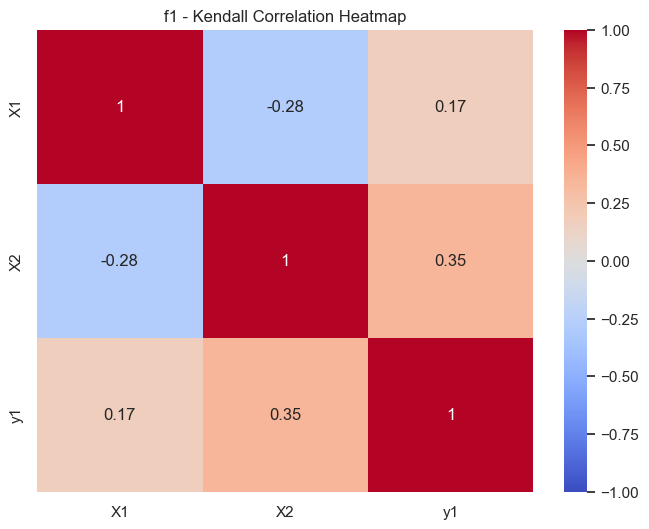


f2 — Kendall Correlation


,X1,X2,y1
X1,1.000000,0.033333,0.3
X2,0.033333,1.000000,0.2
y1,0.300000,0.200000,1.0


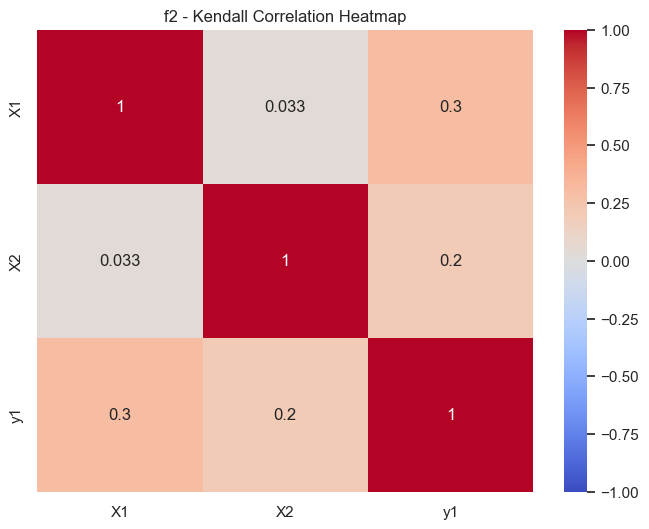


f3 — Kendall Correlation


,X1,X2,X3,y1
X1,1.000000,0.209524,0.000000,0.076190
X2,0.209524,1.000000,-0.180952,0.276190
X3,0.000000,-0.180952,1.000000,-0.066667
y1,0.076190,0.276190,-0.066667,1.000000


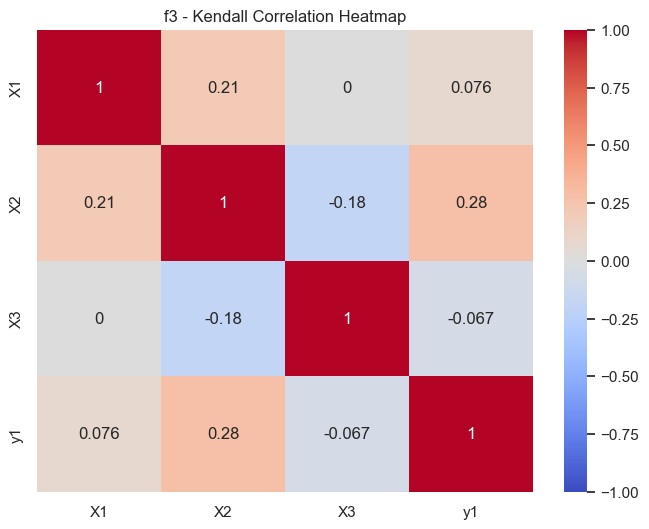


f4 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.180952,0.206349,0.133333,-0.342857
X2,0.180952,1.000000,0.015873,0.126984,-0.311111
X3,0.206349,0.015873,1.000000,-0.139683,-0.158730
X4,0.133333,0.126984,-0.139683,1.000000,-0.269841
y1,-0.342857,-0.311111,-0.158730,-0.269841,1.000000


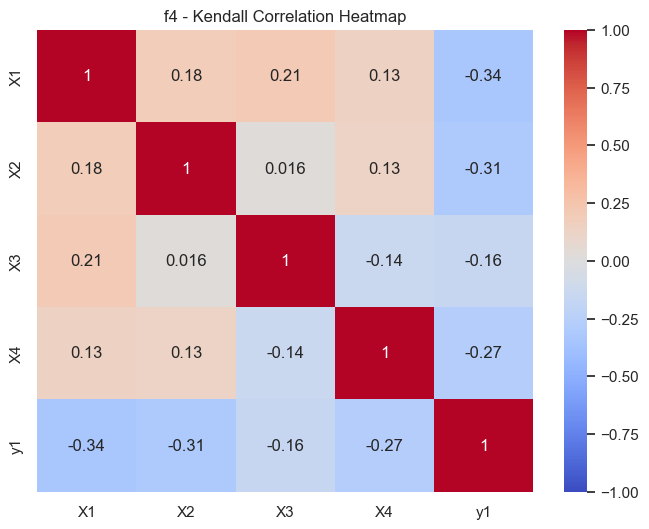


f5 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.144615,-0.092450,0.144615,-0.076923
X2,-0.144615,1.000000,0.203390,0.046154,0.304615
X3,-0.092450,0.203390,1.000000,-0.147920,0.431433
X4,0.144615,0.046154,-0.147920,1.000000,0.224615
y1,-0.076923,0.304615,0.431433,0.224615,1.000000


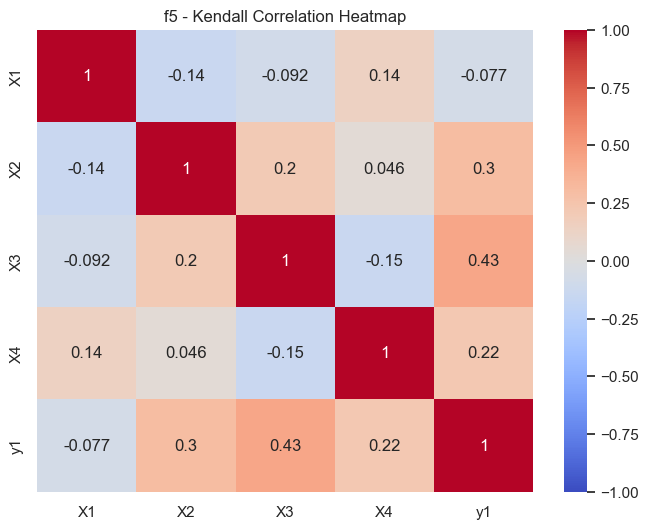


f6 — Kendall Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.111111,-0.018519,0.117103,-0.258860,-0.018490
X2,-0.111111,1.000000,0.043210,-0.117103,0.147920,-0.289677
X3,-0.018519,0.043210,1.000000,0.209553,-0.129430,0.234207
X4,0.117103,-0.117103,0.209553,1.000000,-0.353846,0.483077
X5,-0.258860,0.147920,-0.129430,-0.353846,1.000000,-0.452308
y1,-0.018490,-0.289677,0.234207,0.483077,-0.452308,1.000000


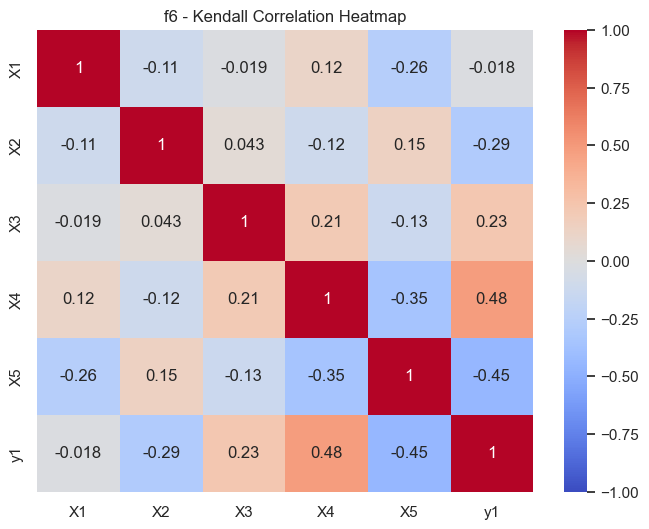


f7 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.006349,-0.066667,-0.006349,-0.015873,-0.333333,-0.371429
X2,0.006349,1.000000,0.044444,0.136508,0.234921,0.082540,-0.107937
X3,-0.066667,0.044444,1.000000,0.069841,-0.168254,0.098413,0.168254
X4,-0.006349,0.136508,0.069841,1.000000,0.057143,0.019048,-0.133333
X5,-0.015873,0.234921,-0.168254,0.057143,1.000000,0.022222,-0.276190
X6,-0.333333,0.082540,0.098413,0.019048,0.022222,1.000000,0.212698
y1,-0.371429,-0.107937,0.168254,-0.133333,-0.276190,0.212698,1.000000


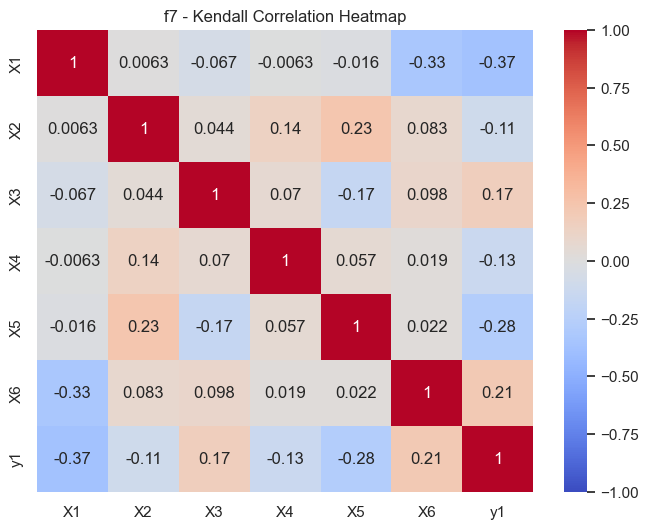


f8 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.096008,0.064646,0.126326,0.112178,0.045478,0.074747,0.041435,-0.466667
X2,0.096008,1.000000,0.055584,-0.150657,0.049545,0.003033,-0.015159,-0.138524,-0.124305
X3,0.064646,0.055584,1.000000,0.126326,-0.098029,-0.144517,-0.052525,-0.063669,-0.488889
X4,0.126326,-0.150657,0.126326,1.000000,-0.089990,-0.100101,-0.037393,0.211325,-0.174836
X5,0.112178,0.049545,-0.098029,-0.089990,1.000000,0.104146,0.106114,0.059656,0.041435
X6,0.045478,0.003033,-0.144517,-0.100101,0.104146,1.000000,0.059626,0.073812,0.035371
X7,0.074747,-0.015159,-0.052525,-0.037393,0.106114,0.059626,1.000000,-0.077817,-0.244444
X8,0.041435,-0.138524,-0.063669,0.211325,0.059656,0.073812,-0.077817,1.000000,0.075796
y1,-0.466667,-0.124305,-0.488889,-0.174836,0.041435,0.035371,-0.244444,0.075796,1.000000


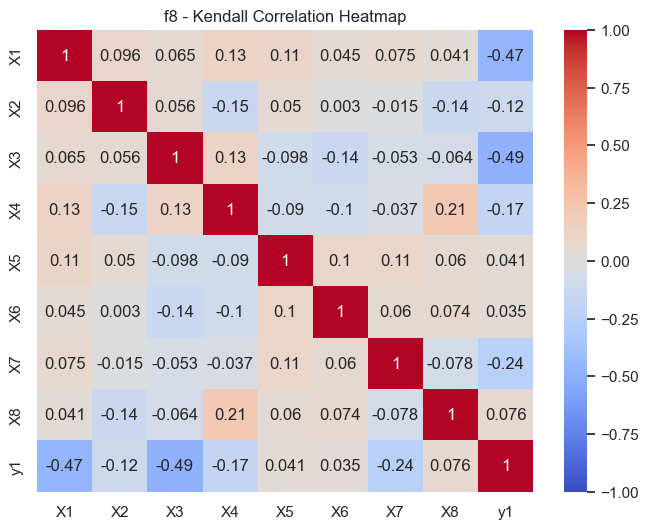

In [14]:
for name, df in functions_data.items():
    print(f"\n{name} — Kendall Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    kendall_corr = df[input_cols + output_cols].corr(method='kendall')
    display(kendall_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Kendall Correlation Heatmap")
    plt.show()


#### Mutual Information

In [15]:
from sklearn.feature_selection import mutual_info_regression

for name, df in functions_data.items():
    print(f"\n{name} — Mutual Information with Output")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values

    mi = mutual_info_regression(X, y, random_state=42)
    mi_df = pd.DataFrame({'Feature': input_cols, 'Mutual_Info': mi}).sort_values(by='Mutual_Info', ascending=False)
    display(mi_df)



f1 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,0.020833
1,X2,0.000000



f2 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,0.360342
1,X2,0.000000



f3 — Mutual Information with Output


...

,Feature,Mutual_Info
4,X5,0.219713
3,X4,0.160208
0,X1,0.000000
1,X2,0.000000
2,X3,0.000000



f7 — Mutual Information with Output


,Feature,Mutual_Info
5,X6,0.162900
4,X5,0.104838
0,X1,0.073122
1,X2,0.003101
2,X3,0.000000
3,X4,0.000000



f8 — Mutual Information with Output


,Feature,Mutual_Info
2,X3,0.376742
0,X1,0.342923
6,X7,0.130967
1,X2,0.009255
3,X4,0.000000
4,X5,0.000000
5,X6,0.000000
7,X8,0.000000


#### Partial Correlation

In [16]:
!pip install pingouin
import pingouin as pg

for name, df in functions_data.items():
    print(f"\n{name} — Partial Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    for x in input_cols:
        pcorr = pg.partial_corr(data=df, x=x, y=output_cols[0], covar=[c for c in input_cols if c != x])
        print(pcorr)



f1 — Partial Correlation
          n         r          CI95%     p-val
pearson  16 -0.079878  [-0.57, 0.45]  0.777193
          n         r          CI95%     p-val
pearson  16 -0.153663  [-0.62, 0.39]  0.584536

f2 — Partial Correlation
          n         r          CI95%     p-val
pearson  16  0.398967  [-0.14, 0.76]  0.140716
          n        r         CI95%     p-val
pearson  16  0.24572  [-0.3, 0.67]  0.377368

f3 — Partial Correlation
          n         r          CI95%     p-val
pearson  21  0.127066  [-0.35, 0.55]  0.604195
          n         r          CI95%     p-val
pearson  21  0.172144  [-0.31, 0.58]  0.480994
          n        r         CI95%     p-val
pearson  21 -0.37187  [-0.71, 0.1]  0.116943

f4 — Partial Correlation
          n         r           CI95%    p-val
pearson  36 -0.384365  [-0.64, -0.05]  0.02721
          n         r         CI95%    p-val
pearson  36 -0.339654  [-0.61, 0.0]  0.05313
          n        r          CI95%    p-val
pearson  36 -0.15

#### Feature vs Output Plots 


Feature vs Output Plots for f1
X shape for f1: (16, 2)
y shape for f1: (16,)


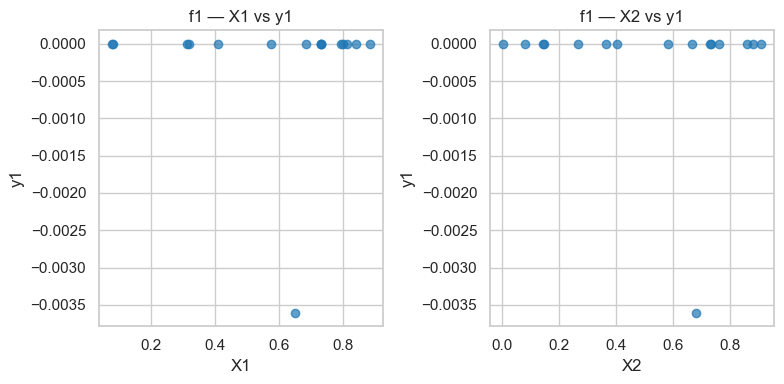


Feature vs Output Plots for f2
X shape for f2: (16, 2)
y shape for f2: (16,)


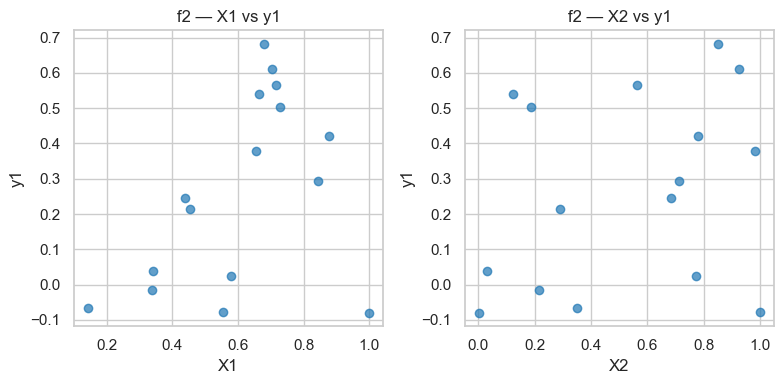


Feature vs Output Plots for f3
X shape for f3: (21, 3)
y shape for f3: (21,)


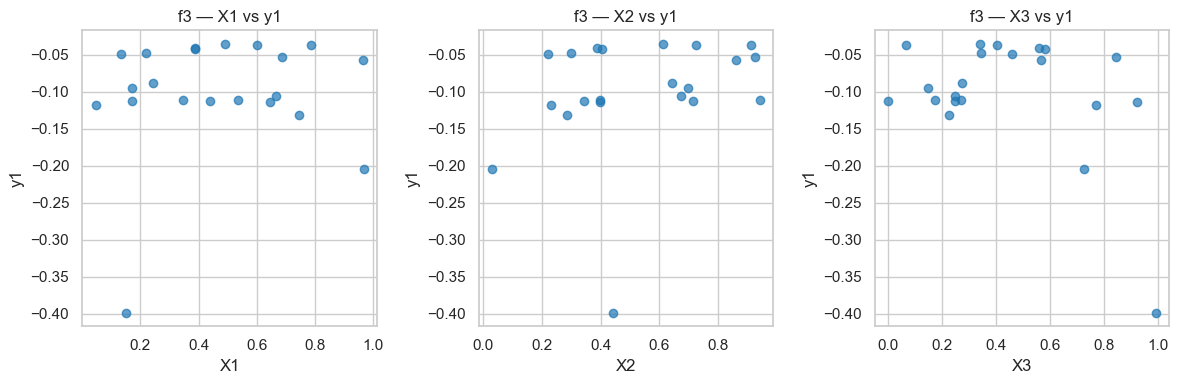


Feature vs Output Plots for f4
X shape for f4: (36, 4)
y shape for f4: (36,)


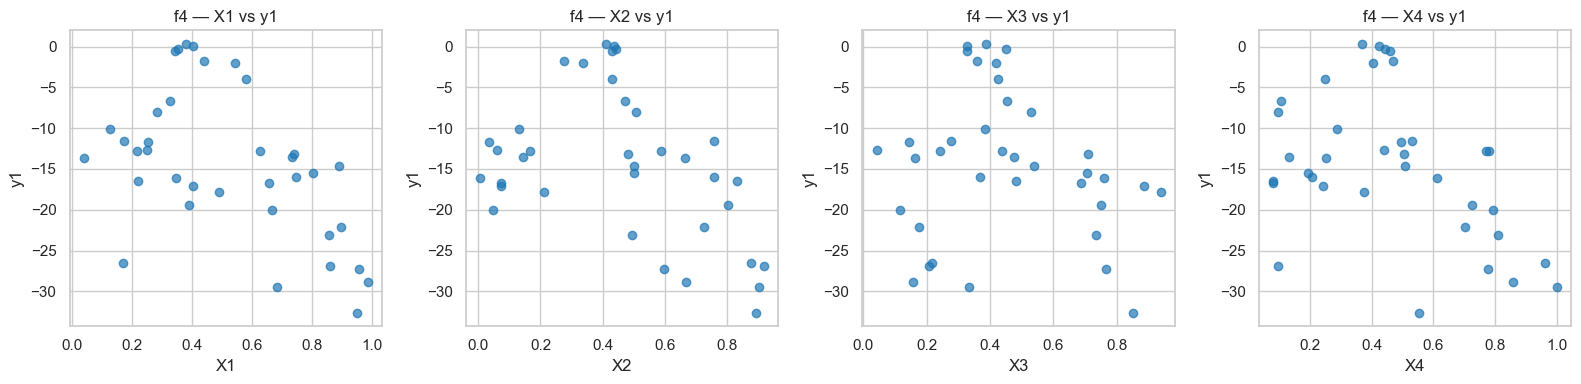


Feature vs Output Plots for f5
X shape for f5: (26, 4)
y shape for f5: (26,)


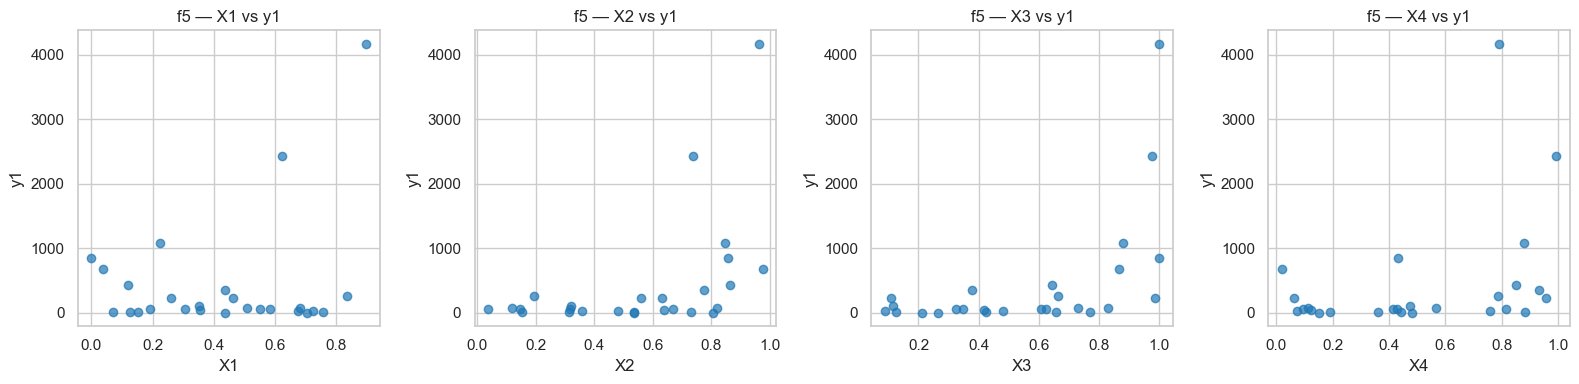


Feature vs Output Plots for f6
X shape for f6: (26, 5)
y shape for f6: (26,)


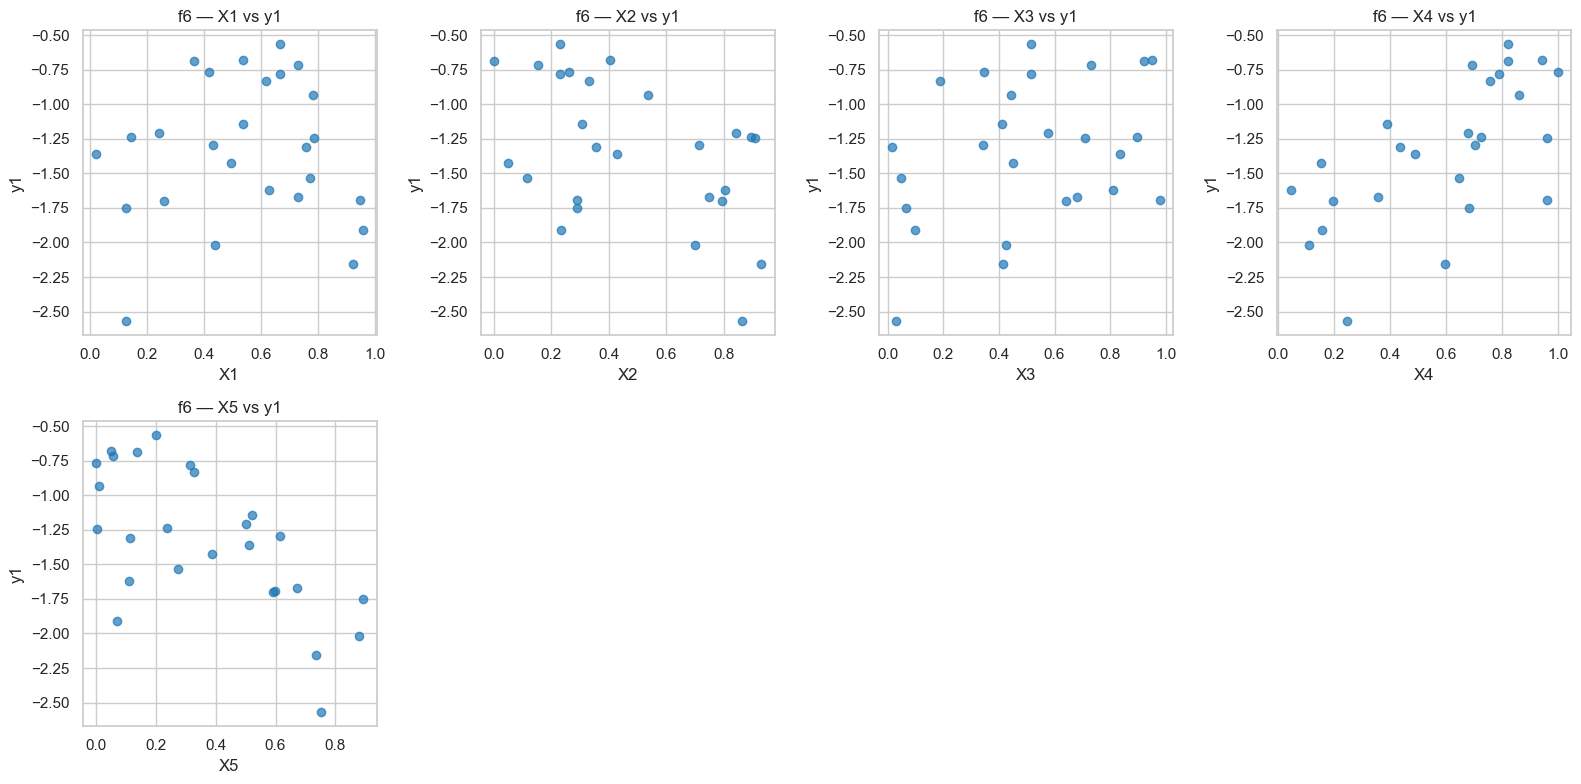


Feature vs Output Plots for f7
X shape for f7: (36, 6)
y shape for f7: (36,)


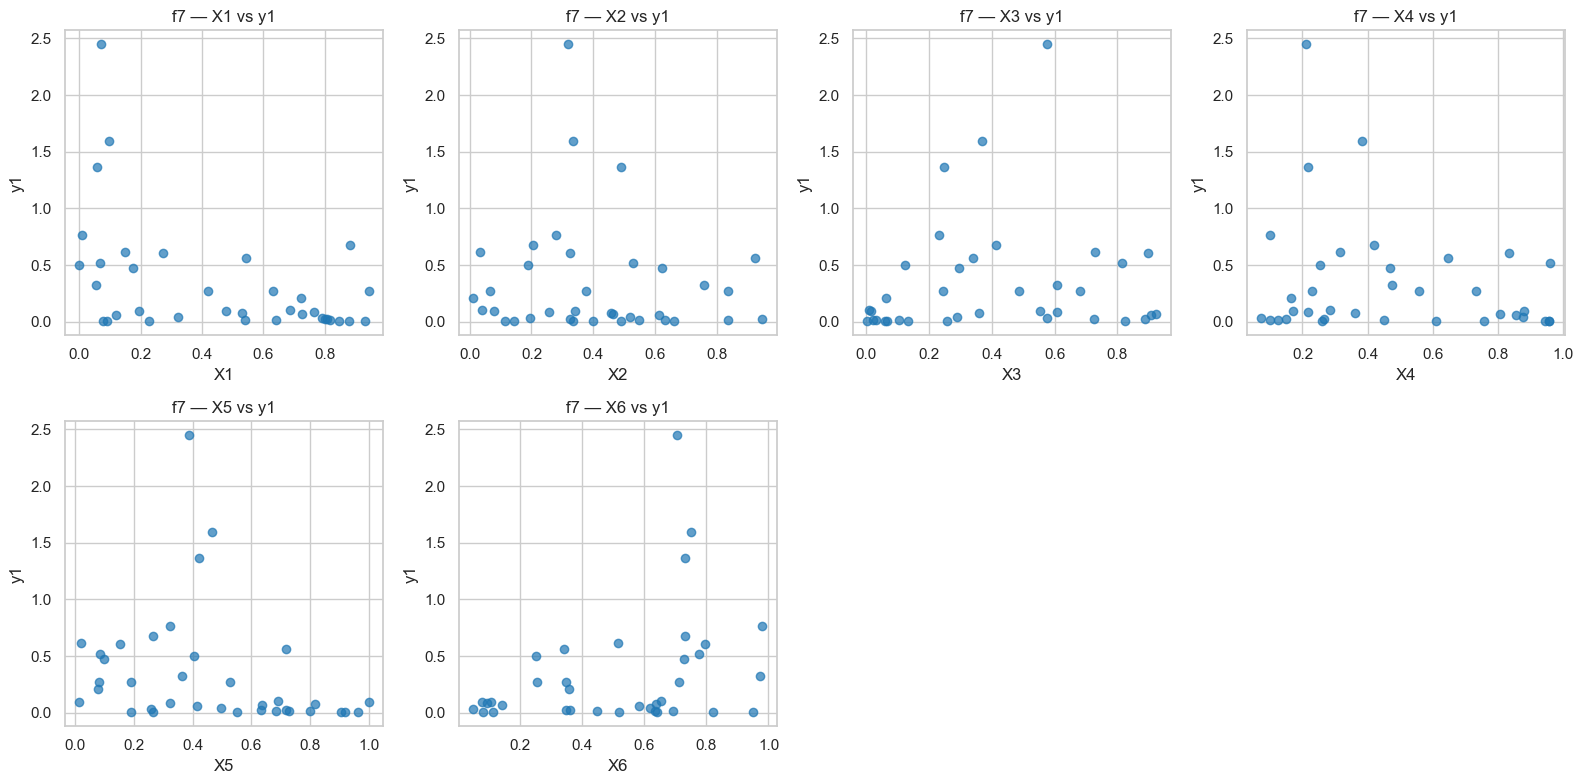


Feature vs Output Plots for f8
X shape for f8: (45, 8)
y shape for f8: (45,)


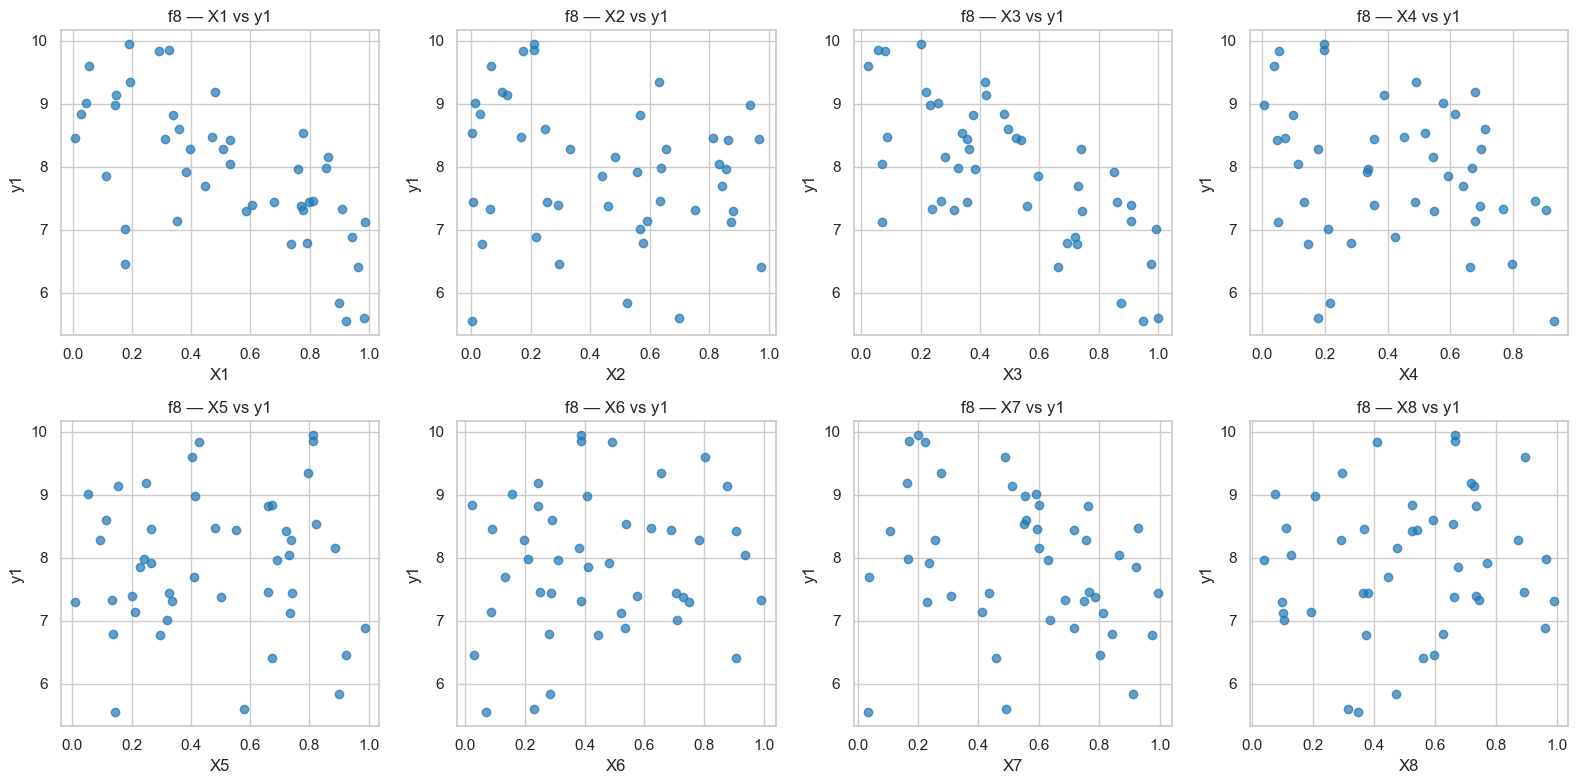

In [17]:
for name, df in functions_data.items():

    print(f"\nFeature vs Output Plots for {name}")


    # Extract input/output columns
    input_cols = [col for col in df.columns if col.startswith("X")]
    output_cols = [col for col in df.columns if col.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values  # use first output column for coloring/plot

    
    # Sanity checks
    print(f"X shape for {name}: {X.shape}")
    print(f"y shape for {name}: {y.shape}")

    assert X.shape[0] == y.shape[0], f"Mismatch in samples for {name}!"
    expected_features = len(input_cols)
    assert X.shape[1] == expected_features, f"Unexpected feature count in {name}!"


    # Plot each feature vs y
    n_features = X.shape[1]

    # Determine grid size (2 rows, dynamic columns)
    n_cols = min(4, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.ravel() if n_features > 1 else [axes]

    for i in range(n_features):
        ax = axes[i]
        ax.scatter(X[:, i], y, color='tab:blue', alpha=0.7)
        ax.set_xlabel(input_cols[i])
        ax.set_ylabel(output_cols[0])
        ax.set_title(f"{name} — {input_cols[i]} vs {output_cols[0]}")

    # Hide unused subplots
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()



=== f1 — Feature & Output Distributions ===


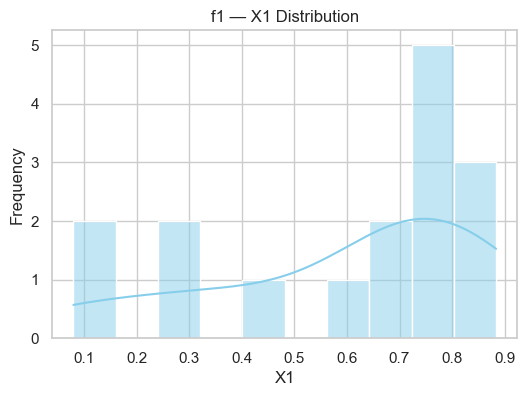

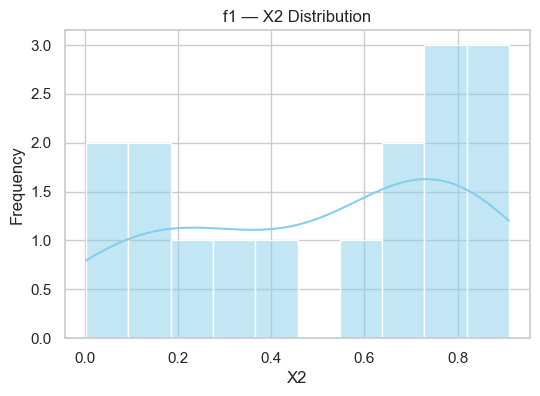

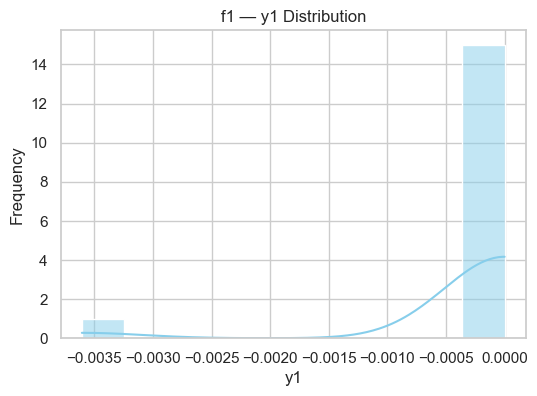


=== f2 — Feature & Output Distributions ===


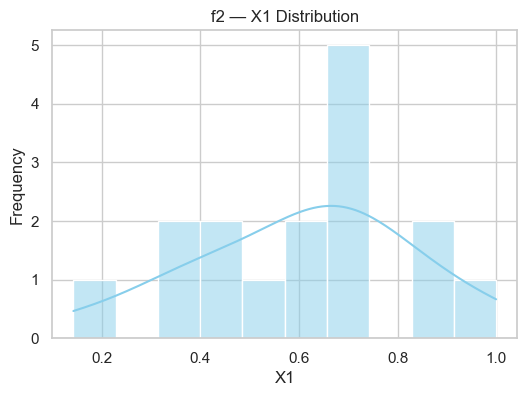

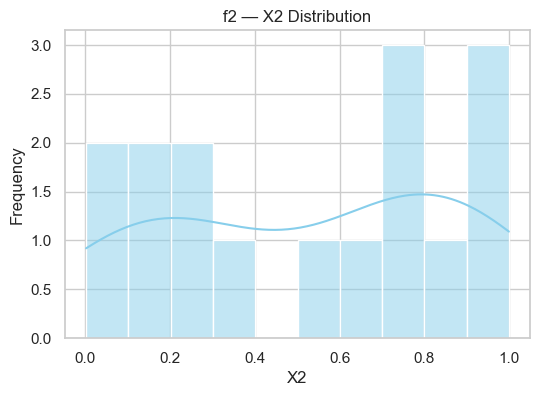

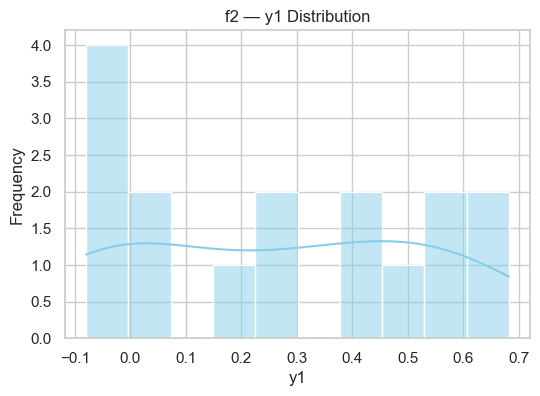


=== f3 — Feature & Output Distributions ===


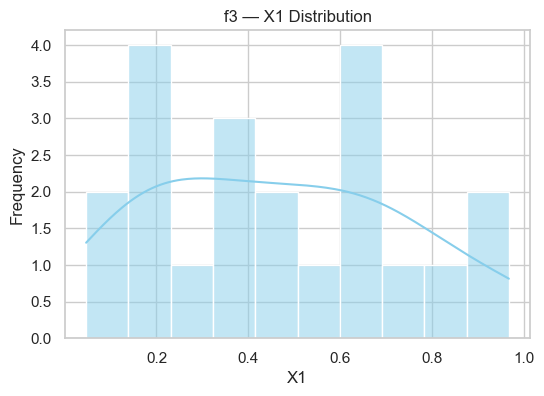

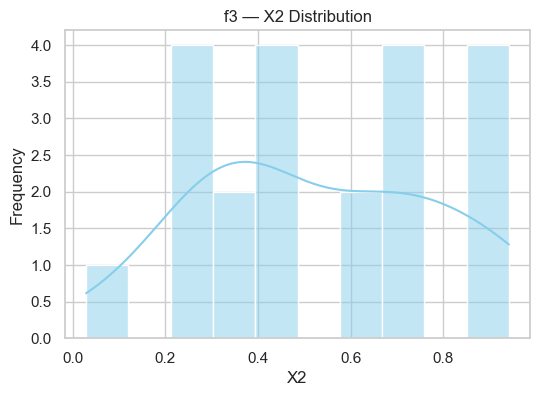

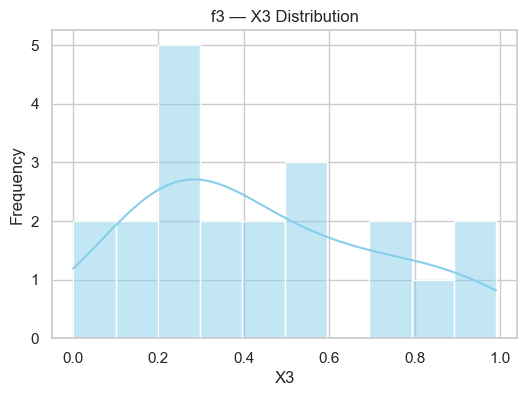

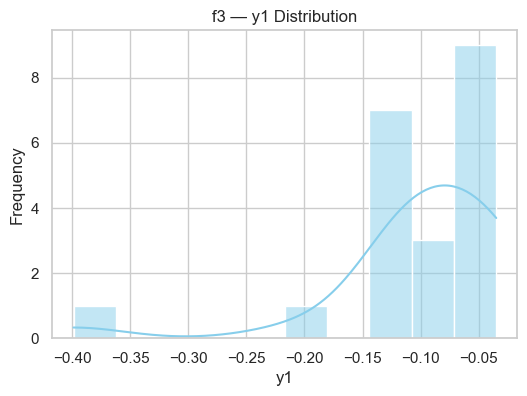


=== f4 — Feature & Output Distributions ===


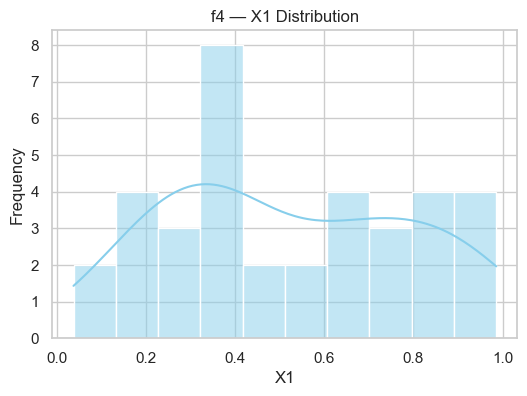

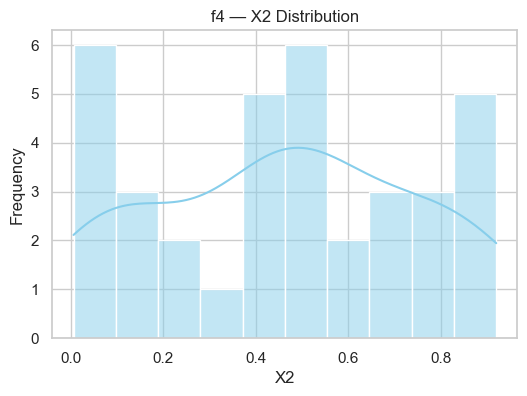

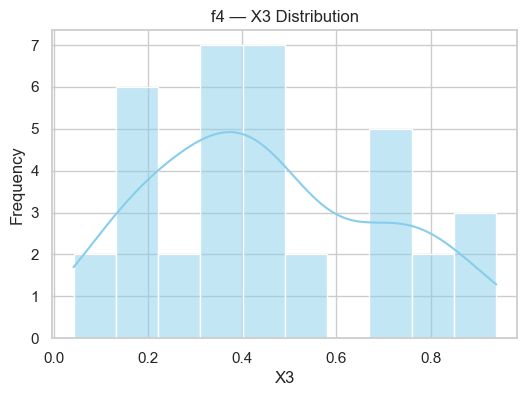

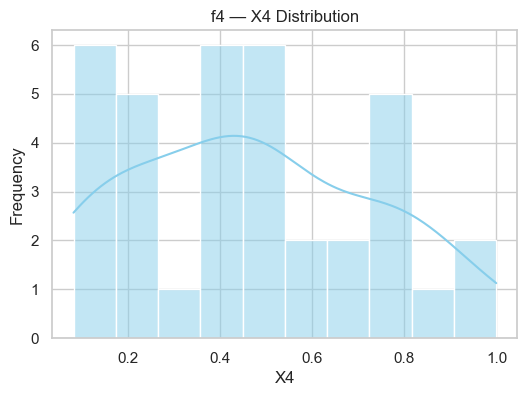

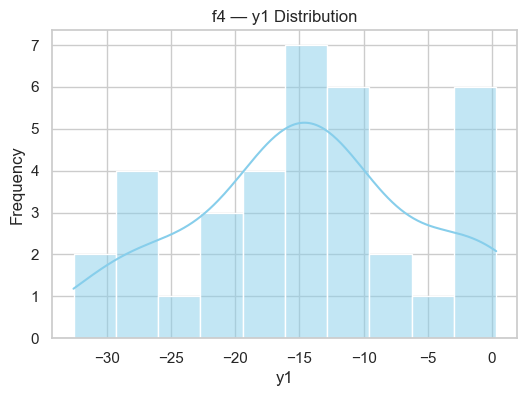


=== f5 — Feature & Output Distributions ===


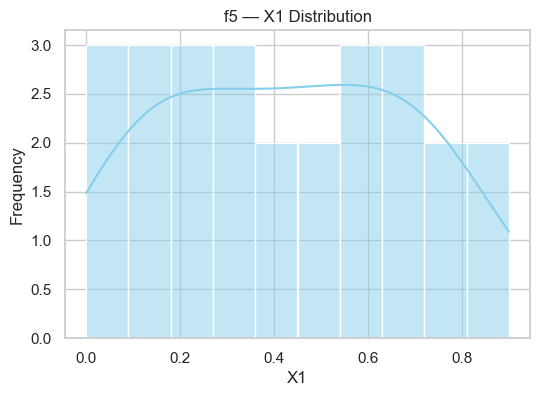

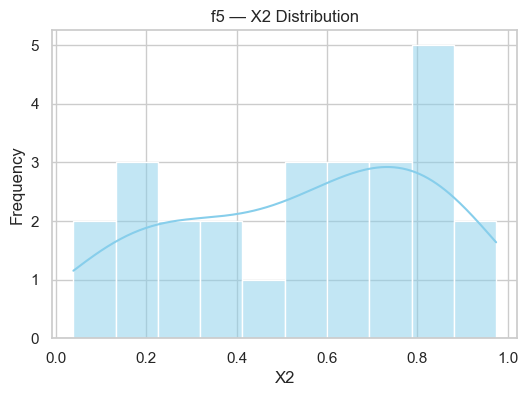

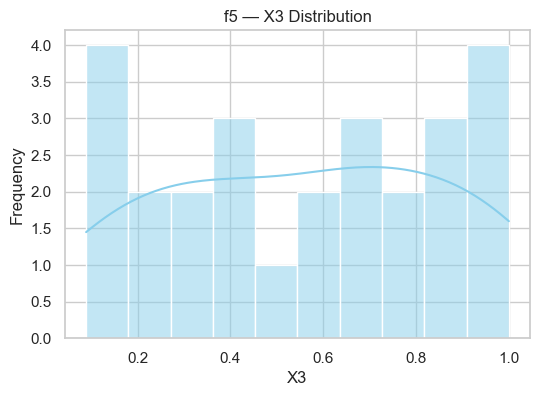

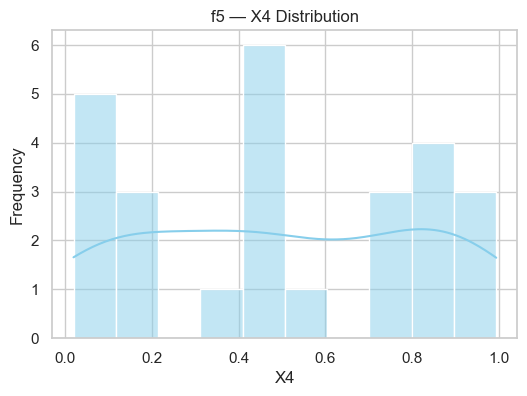

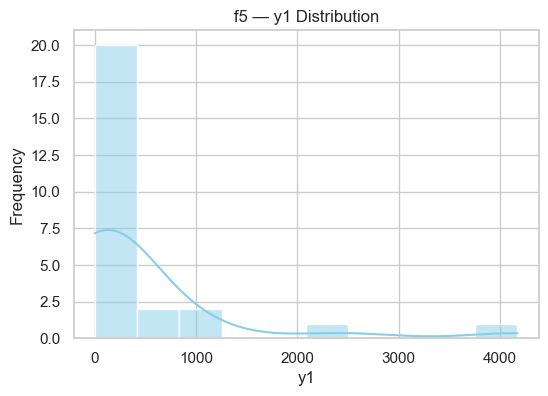


=== f6 — Feature & Output Distributions ===


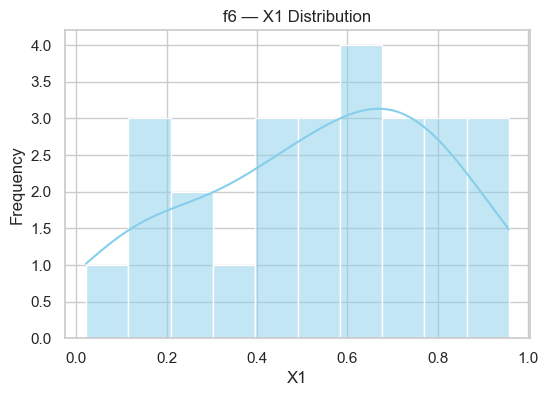

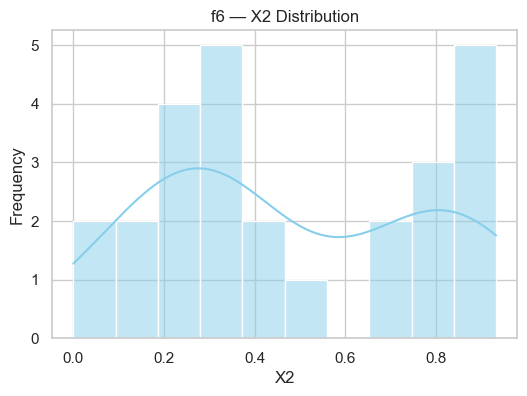

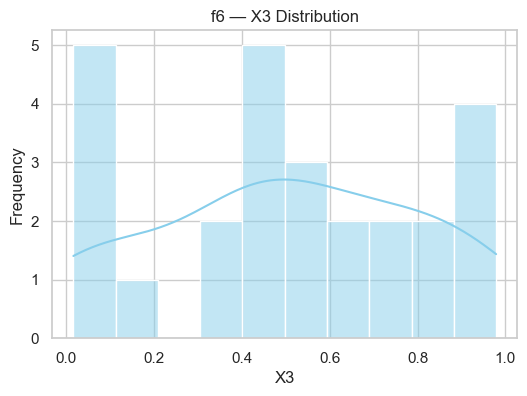

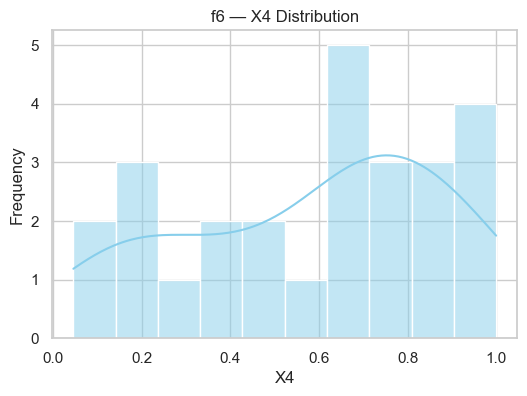

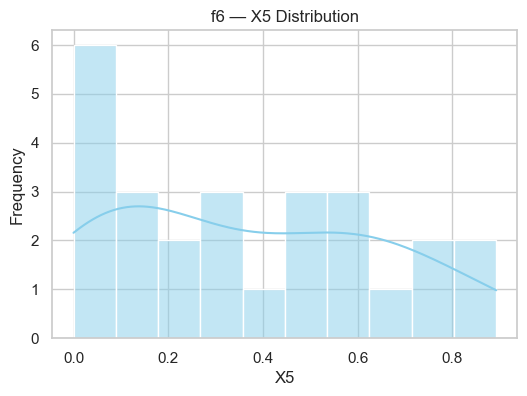

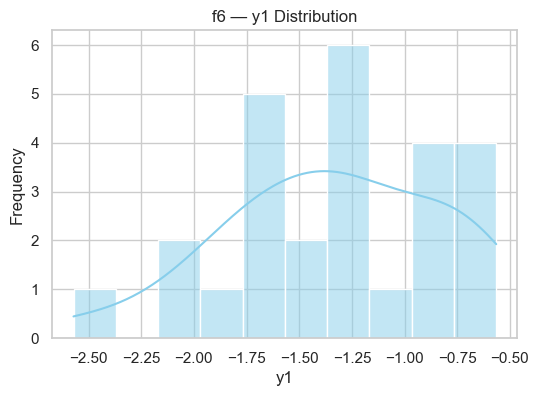


=== f7 — Feature & Output Distributions ===


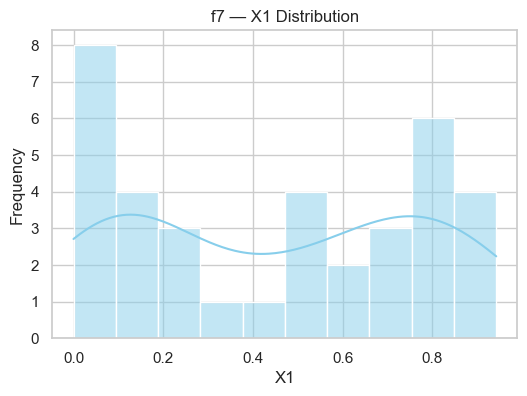

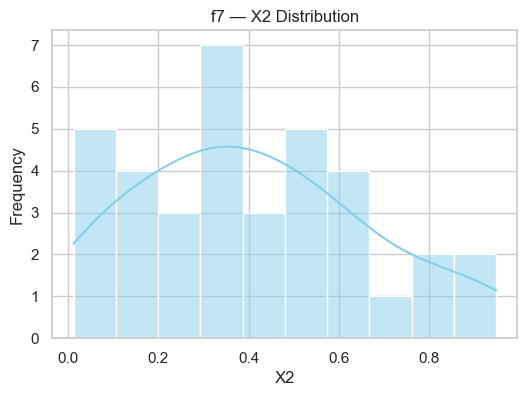

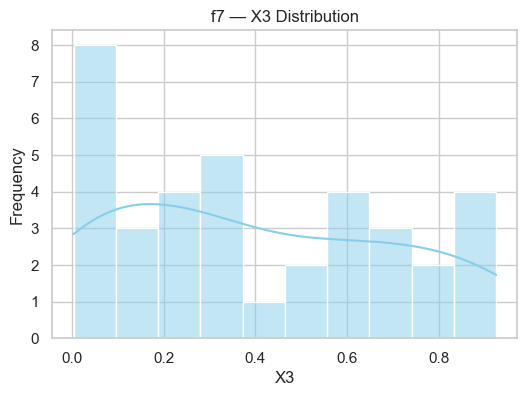

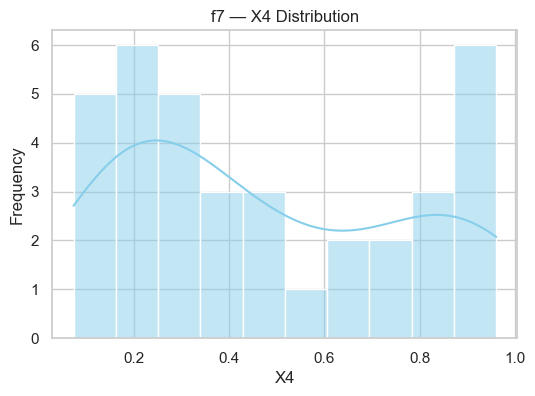

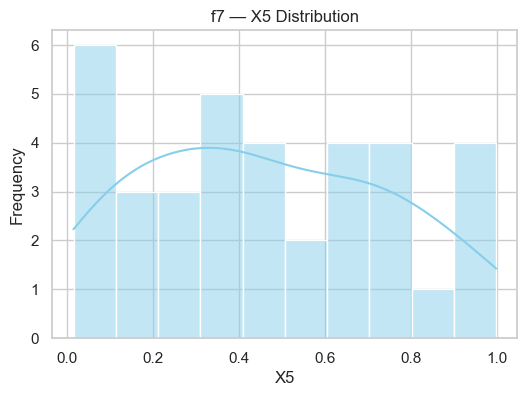

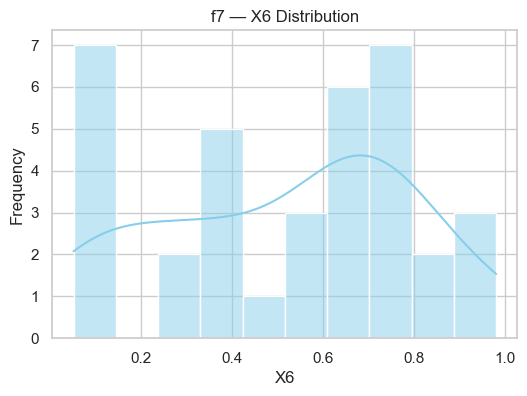

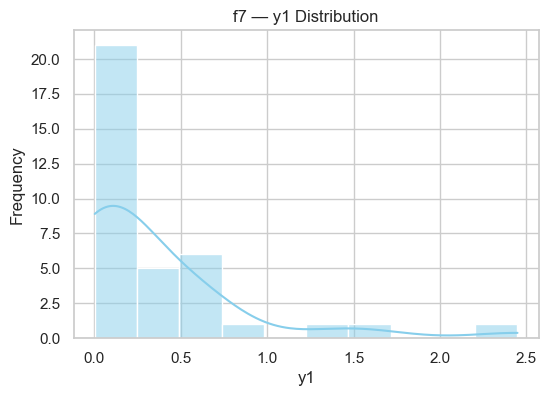


=== f8 — Feature & Output Distributions ===


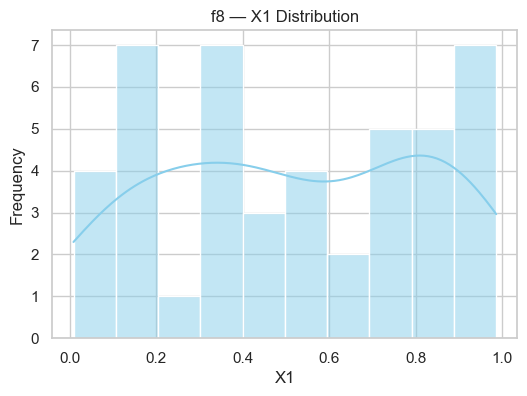

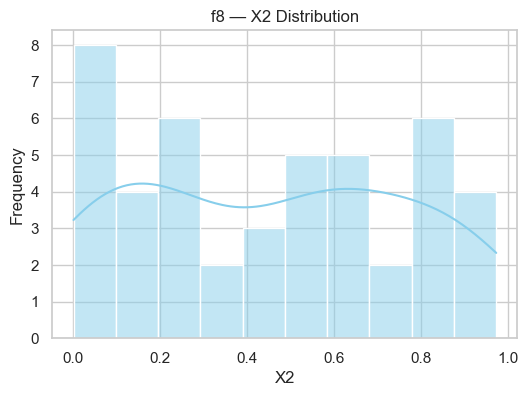

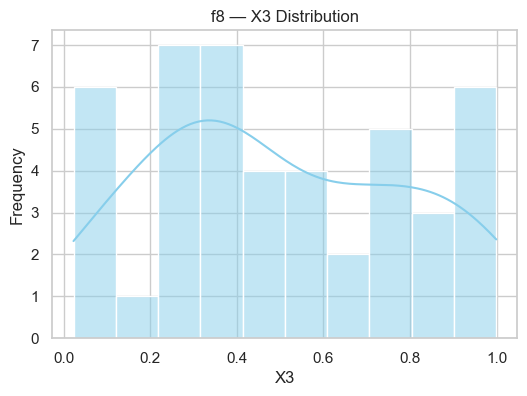

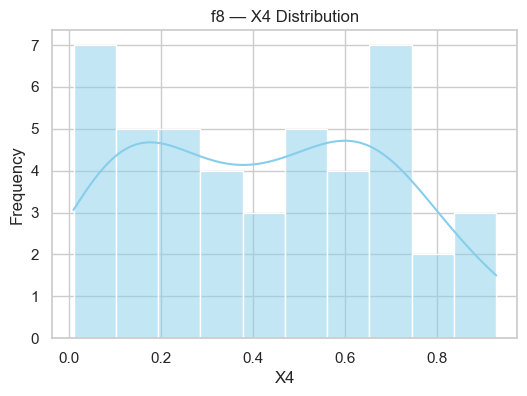

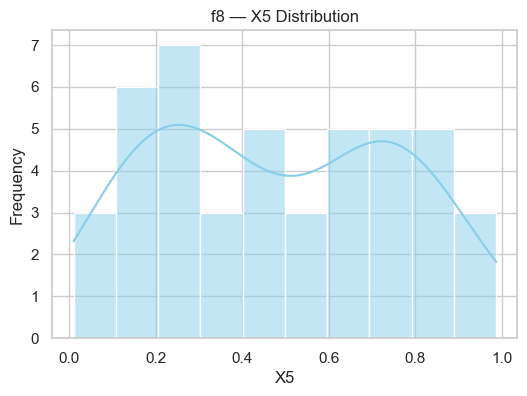

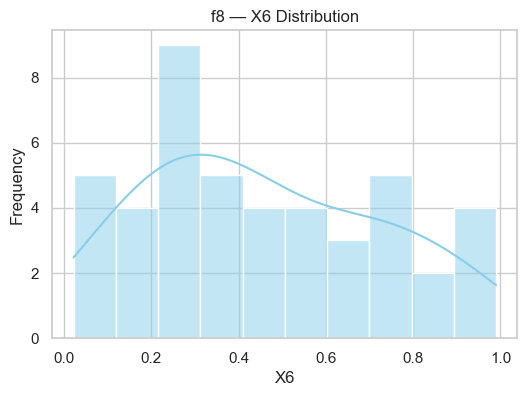

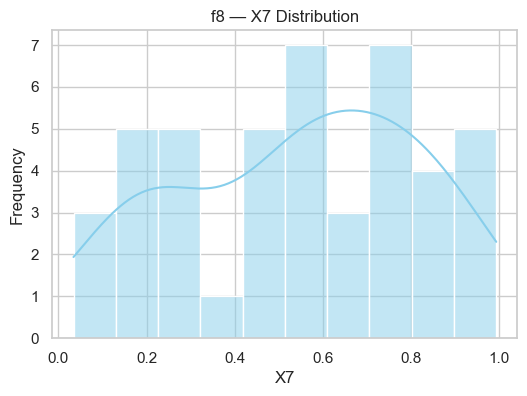

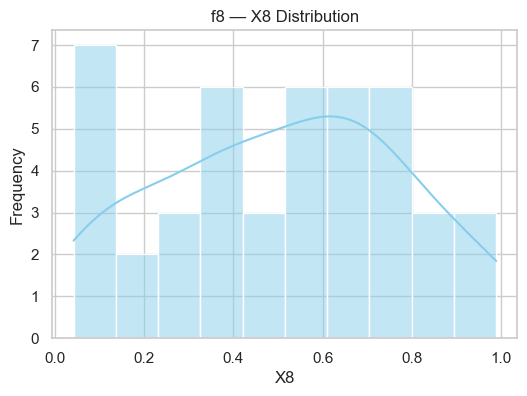

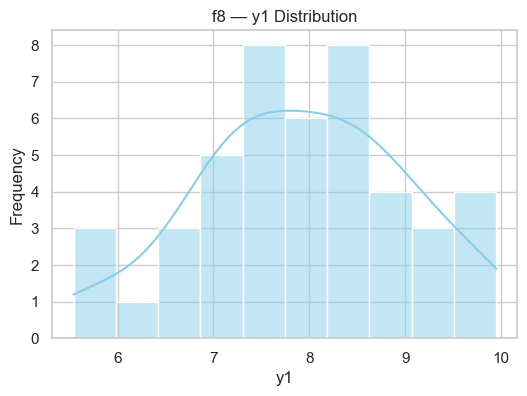

In [20]:
for name, df in functions_data.items():
    print(f"\n=== {name} — Feature & Output Distributions ===")
    
    # Identify input and output columns
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    all_cols = input_cols + output_cols
    
    for col in all_cols:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True, bins=10, color='skyblue')
        plt.title(f"{name} — {col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


#### Line Plot of y Values


f1 — Full Data Table
          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
14  0.812650  0.143347 -1.062933e-161
15  0.079265  0.909848  2.607883e-248

f1 — y vs Instance Plot


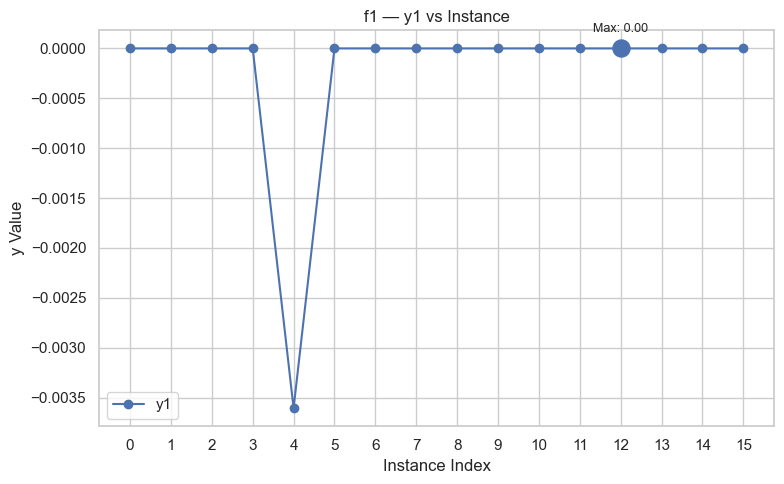


f2 — Full Data Table
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
11  0.999500  0.001800 -0.079755
12  0.727681  0.187140  0.503703
13  0.715483  0.563901  0.566166
14  0.678746  0.850809  0.682452
15  0.653993  0.981188  0.379820

f2 — y vs Instance Plot


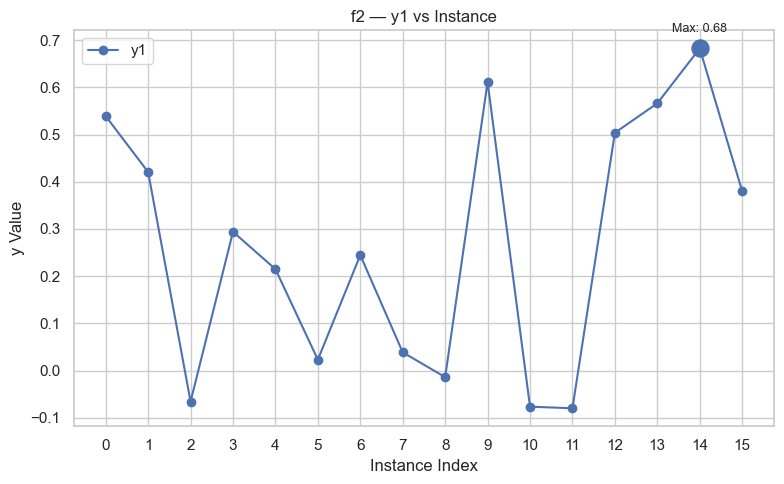


f3 — Full Data Table
          X1        X2        X3        y1
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.389233  0.386084  0.558916 -0.041168
16  0.967200  0.029200  0.723300 -0.204966
17  0.437962  0.715305  0.000876 -0.111768
18  0.387933  0.405240  0.580181 -0.041279
19  0.688252  0.924125  0.842251 -0.053147
20  0.788392  0.913423  0.403090 -0.036375

f3 — y vs Instance Plot


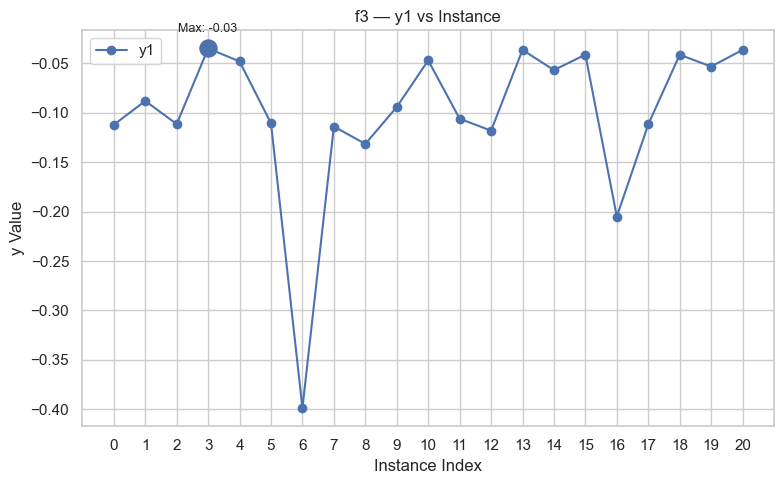


f4 — Full Data Table
          X1        X2        X3        X4         y1
0   0.896981  0.725628  0.175404  0.701694 -22.108288
1   0.889356  0.499588  0.539269  0.508783 -14.601397
2   0.250946  0.033693  0.145380  0.494932 -11.699932
3   0.346962  0.006250  0.760564  0.613024 -16.053765
4   0.124871  0.129770  0.384400  0.287076 -10.069633
5   0.801303  0.500231  0.706645  0.195103 -15.487083
6   0.247708  0.060445  0.042186  0.441324 -12.681685
7   0.746702  0.757092  0.369353  0.206566 -16.026400
8   0.400665  0.072574  0.886768  0.243842 -17.049235
9   0.626071  0.586751  0.438806  0.778858 -12.741766
10  0.957135  0.597644  0.766114  0.776210 -27.316396
11  0.732812  0.145250  0.476813  0.133366 -13.527649
12  0.655115  0.072392  0.687152  0.081517 -16.679115
13  0.219734  0.832031  0.482864  0.082569 -16.507159
14  0.488594  0.211965  0.939178  0.376192 -17.817999
15  0.167130  0.876555  0.217240  0.959801 -26.561821
16  0.216911  0.166086  0.241372  0.770062 -12.758324
17  0.

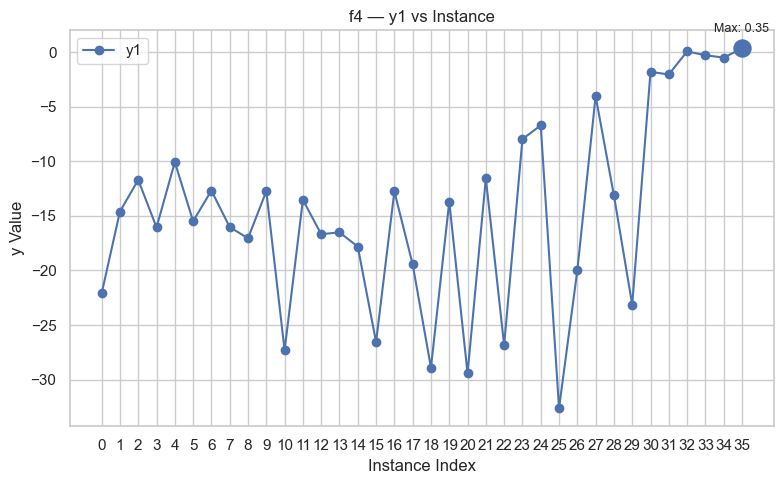


f5 — Full Data Table
          X1        X2        X3        X4           y1
0   0.191447  0.038193  0.607418  0.414584    64.443440
1   0.758653  0.536518  0.656000  0.360342    18.301380
2   0.438350  0.804340  0.210245  0.151295     0.112940
3   0.706051  0.534192  0.264243  0.482088     4.210898
4   0.836478  0.193610  0.663893  0.785649   258.370525
5   0.683432  0.118663  0.829046  0.567577    78.434389
6   0.553621  0.667350  0.323806  0.814870    57.571537
7   0.352356  0.322242  0.116979  0.473113   109.571876
8   0.153786  0.729382  0.422598  0.443074     8.847992
9   0.463442  0.630025  0.107906  0.957644   233.223610
10  0.677491  0.358510  0.479592  0.072880    24.423088
11  0.583973  0.147243  0.348097  0.428615    64.420147
12  0.306889  0.316878  0.622634  0.095399    63.476716
13  0.511142  0.817957  0.728710  0.112354    79.729130
14  0.438933  0.774092  0.378167  0.933696   355.806818
15  0.224189  0.846480  0.879484  0.878516  1088.859618
16  0.725262  0.479870  0.

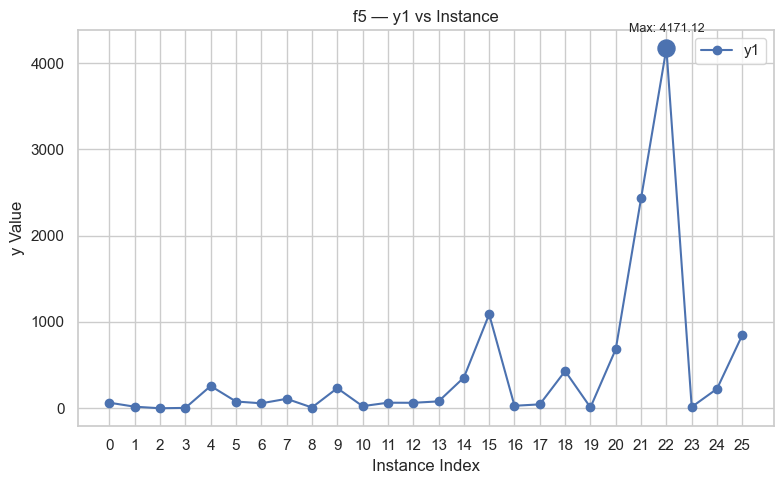


f6 — Full Data Table
          X1        X2        X3        X4        X5        y1
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
2   0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
3   0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
5   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
6   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
7   0.945069  0.288459  0.978806  0.961656  0.598016 -1.694343
8   0.125720  0.862725  0.028544  0.246605  0.751206 -2.571170
9   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
10  0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
11  0.957740  0.235669  0.099146  0.156806  0.071317 -1.912677
12  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
13  0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
14  0.439344  0.698924  0.426820 

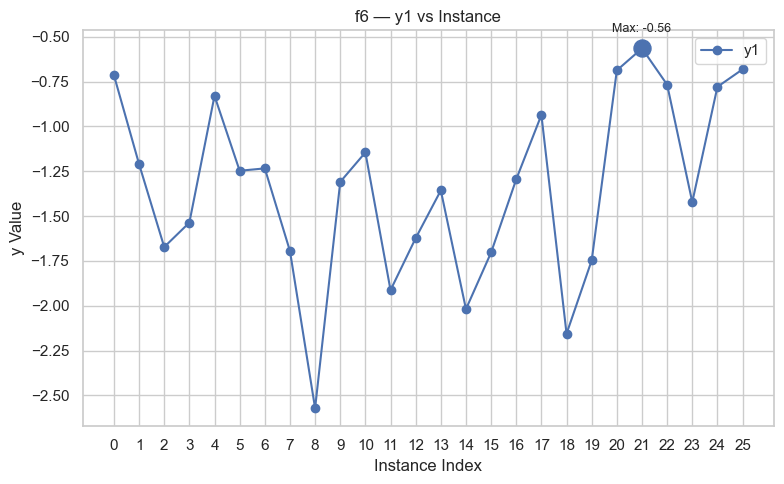


f7 — Full Data Table
          X1        X2        X3        X4        X5        X6        y1
0   0.272624  0.324495  0.897109  0.832951  0.154063  0.795864  0.604433
1   0.543003  0.924694  0.341567  0.646486  0.718440  0.343133  0.562753
2   0.090832  0.661529  0.065931  0.258577  0.963453  0.640265  0.007503
3   0.118867  0.615055  0.905816  0.855300  0.413631  0.585236  0.061424
4   0.630218  0.838097  0.680013  0.731895  0.526737  0.348429  0.273047
5   0.764919  0.255883  0.609084  0.218079  0.322943  0.095794  0.083747
6   0.057896  0.491672  0.247422  0.218118  0.420428  0.730970  1.364968
7   0.195252  0.079227  0.554580  0.170567  0.014944  0.107032  0.092645
8   0.642303  0.836875  0.021793  0.101488  0.683071  0.692416  0.017870
9   0.789943  0.195545  0.575623  0.073659  0.259049  0.051100  0.033565
10  0.528497  0.457424  0.360096  0.362046  0.816891  0.637476  0.073516
11  0.722615  0.011813  0.063646  0.165173  0.079244  0.359952  0.206310
12  0.075665  0.334502  0.132

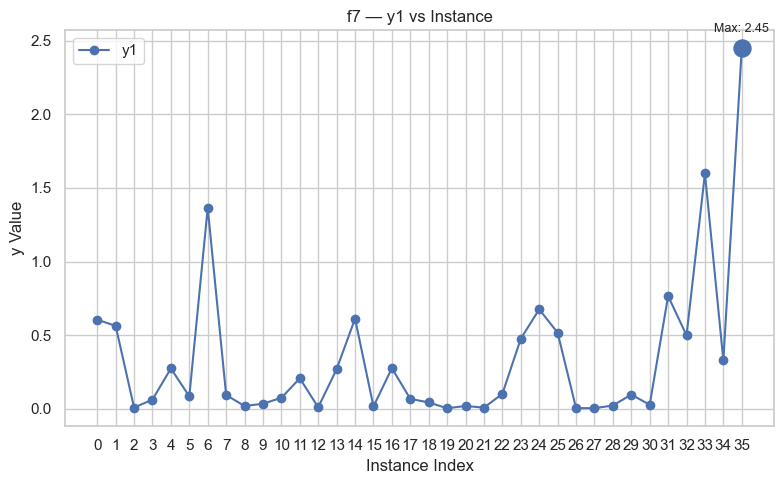


f8 — Full Data Table
          X1        X2        X3        X4        X5        X6        X7        X8        y1
0   0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311  0.734281  7.398721
1   0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384  0.107132  7.005227
2   0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415  0.367320  8.459482
3   0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827  0.292472  8.284008
4   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295  0.593882  8.606117
5   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347  0.660032  8.541748
6   0.908649  0.062250  0.238260  0.766604  0.132336  0.990244  0.688068  0.742496  7.327435
7   0.586371  0.880736  0.745021  0.546035  0.009649  0.748992  0.230907  0.097916  7.299872
8   0.761137  0.854672  0.382124  0.337352  0.689708  0.309853  0.631380  0.041956  7.957875
9   0.984933  0.699506  0.998885  0.180148  0.58

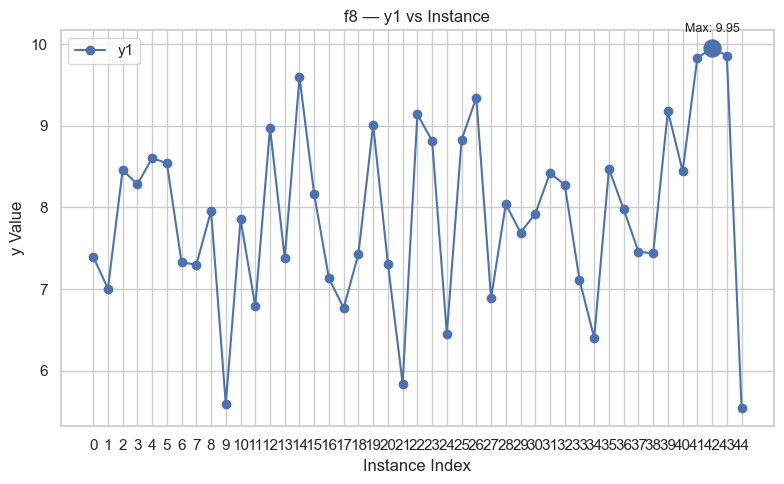

In [18]:
# Dictionary to store week labels for each DataFrame
week_labels_dict = {}
# Dictionary to track the next week number to assign
next_week_counter = {}

for name, df in functions_data.items():
    print(f"\n{name} — Full Data Table")
    print(df.to_string())
    print(f"\n{name} — y vs Instance Plot")
    
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    
    for col in output_cols:
        plt.figure(figsize=(8, 5))
        x = df.index
        y = df[col]
        plt.plot(x, y, marker='o', label=col)
        
        # Highlight maximum y
        max_idx = y.idxmax()
        max_val = y.max()
        plt.scatter(max_idx, max_val, s=150, zorder=5)
        plt.annotate(
            f"Max: {max_val:.2f}",
            (max_idx, max_val),
            textcoords="offset points",
            xytext=(0, 12),
            ha='center',
            fontsize=9
        )
        
        
        plt.xticks(x)
        plt.title(f"{name} — {col} vs Instance")
        plt.xlabel("Instance Index")
        plt.ylabel("y Value")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()



#### f1 | Scrambled Halton with Gradient Free CMA - ES HPT for near flat 2D Surface

In [26]:
import numpy as np
from scipy.stats.qmc import Halton, Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
import cma

In [27]:
# Extract existing data for Function 1
df = functions_data["f1"]

# Separate inputs (X) and outputs (y)
X_train_1 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_1 = df["y1"].values
print(X_train_1)
print(y_train_1)

[[0.3194038888 0.7629593743]
 [0.5743292145 0.879898105 ]
 [0.731023631  0.7329998764]
 [0.8403534169 0.264731614 ]
 [0.6501140598 0.6815263521]
 [0.4104371366 0.147554299 ]
 [0.3126911568 0.0787227779]
 [0.6834181689 0.8610574644]
 [0.0825072518 0.4034875064]
 [0.8838898288 0.5822539744]
 [0.7936       0.666269    ]
 [0.800601     0.0028      ]
 [0.729726     0.729276    ]
 [0.732162     0.364472    ]
 [0.81265      0.143347    ]
 [0.079265     0.909848    ]]
[ 0.            0.            0.            0.           -0.0036060626
 -0.           -0.            0.            0.            0.
  0.            0.            0.            0.           -0.
  0.          ]


In [28]:
# ml method name in this code
# gaussian process regression with cma es hyperparameter tuning
# objective of submission
# propose a new query point for an expensive 2d black box function using aggressive exploration
# rationale behind the chosen ml method
# gaussian processes provide a probabilistic surrogate model and cma es can tune its hyperparameters
# even when the likelihood surface is flat
# key assumptions
# the function is nearly flat, evaluations are expensive, and a space filling design is desirable
# exploration mechanism
# scrambled halton sequence spreads candidates across the unit square and a small ucb term
# selects a point that is both novel and weakly guided by the surrogate

def tune_gp_with_cma_es(X_train_1, y_train_1):
    """
    tune gaussian process hyperparameters using cma es

    X: array of shape (n_samples, 2) with input points in [0, 1]^2
    y: array of shape (n_samples,) with function values
    """

    # we work in log space for length scales and noise
    # this makes it easier to search over several orders of magnitude

    def build_kernel_from_params(theta):
        """
        convert log space parameters to a sklearn kernel

        theta[0], theta[1]: log length scales for the two dimensions
        theta[2]: log signal variance
        theta[3]: log noise level
        """
        length_scales = np.exp(theta[:2])
        signal_variance = np.exp(theta[2])
        noise_level = np.exp(theta[3])

        # constant kernel controls overall variance
        # matern kernel controls smoothness and correlation length
        # white kernel models observation noise
        kernel = ConstantKernel(signal_variance) * Matern(
            length_scale=length_scales,
            nu=2.5
        ) + WhiteKernel(noise_level=noise_level)
        return kernel

    def neg_log_marginal_likelihood(theta):
        """
        objective for cma es
        returns negative log marginal likelihood of the gaussian process

        cma es will try to minimise this value
        """
        kernel = build_kernel_from_params(theta)
        gp = GPR(
            kernel=kernel,
            normalize_y=True,
            alpha=0.0
        )
        try:
            gp.fit(X_train_1, y_train_1)
            # sklearn provides the log marginal likelihood
            nll = -gp.log_marginal_likelihood_value_
        except Exception:
            # if something goes wrong, return a large penalty
            nll = 1e6
        return nll

    # initial guess in log space
    # length scales around 0.5, signal variance 1.0, noise 1e-6
    theta0 = np.log(np.array([0.5, 0.5, 1.0, 1e-6]))

    # cma es settings
    sigma0 = 0.3  # initial step size
    options = {
        "maxiter": 200,
        "tolx": 1e-6,
        "verb_disp": 0  # turn off verbose output
    }

    best_theta = None
    best_nll = np.inf

    # multiple restarts improve robustness
    for _ in range(3):
        es = cma.CMAEvolutionStrategy(theta0, sigma0, options)
        while not es.stop():
            solutions = es.ask()
            values = [neg_log_marginal_likelihood(s) for s in solutions]
            es.tell(solutions, values)
        theta_opt = es.result.xbest
        nll_opt = neg_log_marginal_likelihood(theta_opt)
        if nll_opt < best_nll:
            best_nll = nll_opt
            best_theta = theta_opt

    # build final kernel and gp with best parameters
    final_kernel = build_kernel_from_params(best_theta)
    gp = GPR(
        kernel=final_kernel,
        normalize_y=True,
        alpha=0.0
    )
    gp.fit(X_train_1, y_train_1)

    return gp


def propose_f1_query(X_train_1, y_train_1, random_state=None):
    """
    propose the next query point for function f1

    X_train: array of shape (n_samples, 2) with past query points
    y_train: array of shape (n_samples,) with past function values
    """

    rng = np.random.RandomState(random_state)

    # step 1 tune the gaussian process hyperparameters with cma es
    gp = tune_gp_with_cma_es(X_train_1, y_train_1)

    # step 2 generate scrambled halton candidates in the 2d unit square
    n_candidates = 2000
    sampler = Halton(d=2, scramble=True, seed=rng.randint(1, 10_000))
    candidates = sampler.random(n_candidates)

    # step 3 enforce a minimum distance guard to avoid redundant evaluations
    min_dist = 0.05

    def min_distance_to_train(x):
        return np.min(np.linalg.norm(X_train_1 - x, axis=1))

    mask = np.array([min_distance_to_train(c) > min_dist for c in candidates])
    novel_candidates = candidates[mask]

    # if too few candidates survive, relax the distance slightly
    if len(novel_candidates) < 50:
        min_dist_relaxed = 0.03
        mask = np.array([min_distance_to_train(c) > min_dist_relaxed for c in candidates])
        novel_candidates = candidates[mask]

    # step 4 use the gaussian process to score the candidates
    means, stds = gp.predict(novel_candidates, return_std=True)

    # step 5 compute a very weak ucb acquisition
    # this keeps the selection almost uniform but slightly prefers higher mean
    beta = 0.05
    acquisition = means + beta * stds

    # step 6 choose the candidate with the highest acquisition value
    best_idx = np.argmax(acquisition)
    next_x = novel_candidates[best_idx]
    np.set_printoptions(suppress=True, precision=6)

    # print diagnostics to understand exploration behaviour
    print("gp kernel:", gp.kernel_)
    print("next_x:", np.round(next_x, 6))
    print("gp mean at next_x:", float(means[best_idx]))
    print("gp std at next_x:", float(stds[best_idx]))
    print("min distance to training set:", float(min_distance_to_train(next_x)))

    return next_x, gp

next_point, gp_model = propose_f1_query(X_train_1, y_train_1)


gp kernel: 0.811**2 * Matern(length_scale=[1e-05, 1e-05], nu=2.5) + WhiteKernel(noise_level=0.342)
next_x: [0.112598 0.525207]
gp mean at next_x: -0.0002253789152723369
gp std at next_x: 0.000872888785790056
min distance to training set: 0.1253840887798244


#### f2 | Max Value Entropy Search with Multi-Start L-BFGS-B GP HPT

In [29]:
# Extract existing data for Function 2
df = functions_data["f2"]

# Separate inputs (X) and outputs (y)
X_train_2 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_2 = df["y1"].values
print(X_train_2)
print(y_train_2)

[[0.6658   0.123969]
 [0.877791 0.778628]
 [0.142699 0.349005]
 [0.845275 0.71112 ]
 [0.454647 0.290455]
 [0.577713 0.771973]
 [0.438166 0.685018]
 [0.34175  0.028698]
 [0.338648 0.213867]
 [0.702637 0.926564]
 [0.554975 0.999446]
 [0.9995   0.0018  ]
 [0.727681 0.18714 ]
 [0.715483 0.563901]
 [0.678746 0.850809]
 [0.653993 0.981188]]
[ 0.538996  0.420586 -0.065624  0.293993  0.214965  0.023106  0.244619
  0.038749 -0.013858  0.611205 -0.076408 -0.079755  0.503703  0.566166
  0.682452  0.37982 ]


In [45]:
from sklearn.neighbors import KNeighborsRegressor as KNN

In [46]:
dim = 2
n_sobol = 5000          # number of interior sobol candidates
n_boundary = 1000       # number of boundary candidates
boundary_w = 0.05       # width of boundary strips near edges
min_dist_guard = 0.04   # minimum distance to existing points
n_restarts_lbfgs = 20   # number of l bfgs b restarts for gp hyperparameters


def sobol_candidates(d, n, seed=0):
    """
    generate n sobol quasi random candidates in [0, 1]^d
    sobol sequences cover low dimensional spaces more evenly than pure random sampling
    """
    return Sobol(d=d, scramble=True, seed=seed).random(n)


def boundary_candidates(d, n, width=0.05, seed=7):
    """
    generate candidates within boundary strips of width 'width'
    for 2d there are four strips: low and high for each dimension
    this forces exploration near edges that might otherwise be ignored
    """
    rng = np.random.default_rng(seed)
    strips = []
    for d_i in range(d):
        for edge in [0.0, 1.0]:
            n_strip = n // (2 * d)
            pts = rng.random((n_strip, d))
            if edge == 0.0:
                pts[:, d_i] = rng.uniform(0.0, width, n_strip)
            else:
                pts[:, d_i] = rng.uniform(1.0 - width, 1.0, n_strip)
            strips.append(pts)
    return np.clip(np.vstack(strips), 0.0, 1.0)


def min_dist_to_obs(x, x_obs):
    """
    compute the minimum euclidean distance from a point x to any observed point
    this is used to enforce a distance guard for exploration
    """
    return np.sqrt(((x_obs - x) ** 2).sum(axis=1)).min()


def fit_gp_lbfgsb(x, y):
    """
    fit a gaussian process with a matern kernel using l bfgs b hyperparameter tuning
    the gp models the function and provides both mean and uncertainty estimates
    l bfgs b uses gradients of the log marginal likelihood to find good hyperparameters
    """
    kernel = (
        Matern(
            length_scale=[1.0, 2.0],
            length_scale_bounds=[(0.02, 5.0), (0.05, 10.0)],
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=1e-3,
            noise_level_bounds=(1e-8, 0.5),
        )
    )

    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=n_restarts_lbfgs,
        normalize_y=True,
        random_state=0,
    )
    gp.fit(x, y)

    # print optimised hyperparameters so you can inspect the fitted model
    k = gp.kernel_
    ls = k.get_params().get("k1__length_scale", [])
    noise = k.get_params().get("k2__noise_level", 0.0)
    print("optimised l bfgs b hyperparameters:")
    print(f"  length scales: {[round(float(l), 4) for l in ls]}")
    print(f"  noise level: {round(float(noise), 6)}")
    print(f"  log marginal likelihood: {round(gp.log_marginal_likelihood_value_, 4)}")

    return gp


def mes_variance_proxy(gp, candidates):
    """
    compute a max value entropy style score using gp variance as a proxy
    for a gaussian process, points with high posterior variance are most informative
    here we simply use the standard deviation as the exploration score
    """
    _, sigma = gp.predict(candidates, return_std=True)
    return sigma


def propose_f2_query(x_train_2, y_train_2):
    """
    main function to propose the next evaluation point for the 2d function
    it combines sobol candidates, boundary candidates, a distance guard,
    a gaussian process surrogate, and a variance based exploration score
    """
    # step 1: generate interior sobol candidates
    sobol_pts = sobol_candidates(dim, n_sobol)

    # step 2: generate boundary candidates near edges
    bound_pts = boundary_candidates(dim, n_boundary, boundary_w)

    # step 3: combine and clip candidates to [0, 1]
    candidates = np.vstack([sobol_pts, bound_pts])
    candidates = np.clip(candidates, 0.0, 1.0)

    # step 4: apply distance guard to enforce exploration
    valid_mask = np.array(
        [min_dist_to_obs(c, x_train_2) >= min_dist_guard for c in candidates]
    )
    candidates = candidates[valid_mask]
    print(f"valid candidates after distance guard: {len(candidates)}")

    # step 5: fit gaussian process with l bfgs b hyperparameter tuning
    gp = fit_gp_lbfgsb(x_train_2, y_train_2)

    # step 6: compute variance based mes proxy scores
    scores = mes_variance_proxy(gp, candidates)

    # step 7: select candidate with highest score
    best_idx = np.argmax(scores)
    next_x = candidates[best_idx]
    mu_p, sigma_p = gp.predict(next_x.reshape(1, -1), return_std=True)

    # step 8: print diagnostic information for interpretation
    print("\nselected candidate for f2:")
    print(f"next_x: {next_x}")
    print(f"gp mean at next_x: {mu_p[0]:.6f}")
    print(f"gp sigma at next_x (mes score): {sigma_p[0]:.6f}")
    near_boundary = np.any(next_x < boundary_w) or np.any(next_x > 1.0 - boundary_w)
    print(f"near boundary: {near_boundary}")

    return next_x, gp
    
np.set_printoptions(suppress=True, precision=10)
next_x = propose_f2_query(X_train_2, y_train_2)


valid candidates after distance guard: 5570
optimised l bfgs b hyperparameters:
  length scales: [0.0497, 10.0]
  noise level: 0.007319
  log marginal likelihood: -12.4749

selected candidate for f2:
next_x: [0.000128692 0.346419896]
gp mean at next_x: 0.256265
gp sigma at next_x (mes score): 0.261818
near boundary: True


#### f3 | KNN‑Guided EI with Genetic Algorithm for HPT 

In [47]:
# Extract existing data for Function 2
df = functions_data["f3"]

# Separate inputs (X) and outputs (y)
X_train_3 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_3 = df["y1"].values
print(X_train_3)
print(y_train_3)

[[0.1715252069 0.3439168703 0.2487372011]
 [0.2421144606 0.6440742698 0.2724328092]
 [0.5349057202 0.3985009154 0.1733887289]
 [0.4925814146 0.6115931883 0.340176386 ]
 [0.1346216663 0.2199172405 0.4582062196]
 [0.3455232705 0.9413598306 0.2693634791]
 [0.1518366324 0.439990619  0.9908818666]
 [0.6455028352 0.3971429396 0.9197713377]
 [0.7469119452 0.2841963092 0.2262998549]
 [0.170476994  0.6970324007 0.1491694337]
 [0.2205493371 0.2978252442 0.3435553444]
 [0.6660136588 0.6719851513 0.2462952967]
 [0.0468089497 0.2313602408 0.7706175922]
 [0.6000972824 0.7251357252 0.0660886415]
 [0.9659948489 0.8611196897 0.5668291313]
 [0.389233     0.386084     0.558916    ]
 [0.9672       0.0292       0.7233      ]
 [0.437962     0.715305     0.000876    ]
 [0.387933     0.40524      0.580181    ]
 [0.688252     0.924125     0.842251    ]
 [0.788392     0.913423     0.40309     ]]
[-0.1121222005 -0.0879628602 -0.1114146543 -0.0348353134 -0.0480075844
 -0.1106209131 -0.3989255131 -0.1138685148 -0.

In [48]:
# ml method name
# knn guided expected improvement with genetic algorithm hyperparameter tuning
# objective of submission
# propose the next query point for a 4d expensive black box function
# rationale behind the chosen ml method
# knn models the mean without assuming smoothness
# a gaussian process models uncertainty
# a genetic algorithm tunes knn hyperparameters without gradients
# key assumptions
# knn is a better mean predictor than gp and gp uncertainty is still useful
# exploration mechanism
# expected improvement combines knn mean and gp uncertainty to pick promising and uncertain points

# global settings
dim = 3
n_sobol = 8000
min_dist_guard = 0.05
xi = 0.01


def sobol_candidates(d, n, seed=0):
    # generate n sobol candidates in the d dimensional unit cube
    sampler = Sobol(d=d, scramble=True, seed=seed)
    return sampler.random(n)


def min_dist_to_obs(x, X_train_3):
    # compute the minimum l2 distance from x to any observed point
    dists = np.sqrt(((X_train_3 - x) ** 2).sum(axis=1))
    return dists.min()


def weighted_knn_loo_mse(k, weights, X_train_3, y_train_3):
    # compute leave one out cross validation mse for weighted knn
    # this is the fitness function for the genetic algorithm
    n = len(X_train_3)
    k_actual = min(int(round(k)), n - 1)
    if k_actual < 1:
        return 1e6

    # apply feature weights to all points
    X_weighted = X_train_3 * weights
    errors = []

    for i in range(n):
        # leave one out split
        X_train = np.delete(X_weighted, i, axis=0)
        y_train = np.delete(y_train_3, i)
        X_test = X_weighted[i : i + 1]

        # compute distances from test point to training points
        dists = np.sqrt(((X_train - X_test) ** 2).sum(axis=1))

        # find indices of k nearest neighbors
        nn_idx = np.argsort(dists)[:k_actual]
        nn_dists = dists[nn_idx]

        # inverse distance weighting for prediction
        if nn_dists.min() < 1e-10:
            pred = y_train[nn_idx[0]]
        else:
            inv_dists = 1.0 / (nn_dists + 1e-10)
            pred = (inv_dists * y_train[nn_idx]).sum() / inv_dists.sum()

        errors.append((pred - y_train_3[i]) ** 2)

    return float(np.mean(errors))


def genetic_algorithm_knn_search(X_train_3, y_train_3,
                                 n_pop=30,
                                 n_gen=40,
                                 cr=0.8,
                                 mr=0.15,
                                 seed=42):
    # genetic algorithm to optimise k and feature weights for knn
    # chromosome structure: [k_normalised, w1, w2, w3, w4]
    # k_normalised in [0,1] maps to integer k in [2, n_obs - 1]
    # feature weights in [0.1, 3.0]

    n_obs = len(X_train_3)
    d = X_train_3.shape[1]
    k_min, k_max = 2, min(10, n_obs - 1)
    rng = np.random.default_rng(seed)

    def decode(chrom):
        # map chromosome to integer k and feature weights
        k_real = k_min + chrom[0] * (k_max - k_min)
        k_int = int(round(k_real))
        k_int = max(k_min, min(k_max, k_int))
        weights = 0.1 + chrom[1:] * 2.9
        return k_int, weights

    def fitness(chrom):
        # compute loo mse for a given chromosome
        k_int, weights = decode(chrom)
        return weighted_knn_loo_mse(k_int, weights, X_train_3, y_train_3)

    # initialise population uniformly in [0,1]
    pop = rng.random((n_pop, d + 1))
    fit_vals = np.array([fitness(ind) for ind in pop])

    best_fit = np.inf
    best_chrom = pop[0].copy()

    for gen in range(n_gen):
        new_pop = []

        # elitism: keep the best individual
        elite_idx = np.argmin(fit_vals)
        new_pop.append(pop[elite_idx].copy())

        # fill the rest of the population
        while len(new_pop) < n_pop:
            # tournament selection for two parents
            t1 = rng.choice(n_pop, 3, replace=False)
            t2 = rng.choice(n_pop, 3, replace=False)
            p1 = pop[t1[np.argmin(fit_vals[t1])]]
            p2 = pop[t2[np.argmin(fit_vals[t2])]]

            # uniform crossover
            child = p1.copy()
            mask = rng.random(len(child)) < cr
            child[mask] = p2[mask]

            # gaussian mutation
            mut_mask = rng.random(len(child)) < mr
            child[mut_mask] += rng.normal(0.0, 0.1, mut_mask.sum())
            child = np.clip(child, 0.0, 1.0)

            new_pop.append(child)

        pop = np.array(new_pop)
        fit_vals = np.array([fitness(ind) for ind in pop])

        # track global best
        gen_best_idx = np.argmin(fit_vals)
        gen_best_fit = fit_vals[gen_best_idx]
        if gen_best_fit < best_fit:
            best_fit = gen_best_fit
            best_chrom = pop[gen_best_idx].copy()

    best_k, best_weights = decode(best_chrom)
    print(f"ga best k: {best_k}")
    print(f"ga best feature weights: {[round(w, 3) for w in best_weights]}")
    print(f"ga best loo cv mse: {best_fit:.8f}")

    return best_k, best_weights


def fit_knn_ga(X_train_3, y_train_3):
    # fit knn with k and feature weights tuned by the genetic algorithm
    k_best, weights = genetic_algorithm_knn_search(X_train_3, y_train_3)
    X_weighted = X_train_3 * weights
    knn = KNN(
        n_neighbors=k_best,
        weights="distance",
        metric="euclidean",
    )
    knn.fit(X_weighted, y_train_3)
    return knn, weights, k_best


def fit_gp_for_uncertainty(X_train_3, y_train_3):
    # fit a gaussian process used only for uncertainty estimation
    kernel = (
        Matern(
            length_scale=[1.0] * dim,
            length_scale_bounds=[(1e-2, 10.0)] * dim,
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=1e-4,
            noise_level_bounds=(1e-8, 1.0),
        )
    )
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=5,
        normalize_y=True,
        random_state=0,
    )
    gp.fit(X_train_3, y_train_3)
    return gp


def expected_improvement(mu, sigma, best_y, xi=0.01):
    # compute expected improvement given mean, sigma, and current best
    improvement = mu - best_y - xi
    z = improvement / (sigma + 1e-9)
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma <= 0.0] = 0.0
    return ei


def propose_f3_query(X_train_3, y_train_3):
    # main function to propose the next query point for f3

    # step 1 generate sobol candidates
    candidates = sobol_candidates(dim, n_sobol, seed=0)

    # step 2 apply minimum distance guard
    valid_mask = np.array(
        [min_dist_to_obs(c, X_train_3) >= min_dist_guard for c in candidates]
    )
    candidates = candidates[valid_mask]
    print(f"valid candidates after distance guard: {len(candidates)}")

    # step 3 fit knn with ga tuned hyperparameters
    knn, weights, k_best = fit_knn_ga(X_train_3, y_train_3)

    # step 4 fit gp for uncertainty
    gp = fit_gp_for_uncertainty(X_train_3, y_train_3)

    # step 5 predict knn mean on weighted candidates
    candidates_weighted = candidates * weights
    mu_knn = knn.predict(candidates_weighted)

    # step 6 get gp sigma on candidates
    _, sigma = gp.predict(candidates, return_std=True)

    # optional diagnostic for knn surface flatness
    iqr = np.percentile(mu_knn, 75) - np.percentile(mu_knn, 25)
    print(f"knn iqr across candidates: {iqr:.6f}")

    # step 7 compute expected improvement
    best_y = float(np.max(y_train_3))
    scores = expected_improvement(mu_knn, sigma, best_y, xi=xi)

    # step 8 select best candidate
    best_idx = int(np.argmax(scores))
    next_x = candidates[best_idx]

    print("\nselected candidate for f3:")
    print(f"next_x: {next_x}")
    print(f"knn prediction at next_x: {mu_knn[best_idx]:.6f}")
    print(f"gp sigma at next_x: {sigma[best_idx]:.6f}")
    print(f"ei score at next_x: {scores[best_idx]:.8f}")
    print(f"ga feature weights used: {[round(w, 3) for w in weights]}")
    print(f"ga best k: {k_best}")

    return next_x, knn, gp, weights


next_x = propose_f3_query(X_train_3, y_train_3)

valid candidates after distance guard: 7924
ga best k: 6
ga best feature weights: [1.131, 1.665, 3.0]
ga best loo cv mse: 0.00586441
knn iqr across candidates: 0.039803

selected candidate for f3:
next_x: [0.1103430353 0.9154650597 0.6559161935]
knn prediction at next_x: -0.044414
gp sigma at next_x: 0.057424
ei score at next_x: 0.01443806
ga feature weights used: [1.131, 1.665, 3.0]
ga best k: 6


#### f4 | Opposition Based Sobol Sampling with ARD-GP + CMA-ES HPT for 4D Space

In [49]:
# Extract existing data for Function 2
df = functions_data["f4"]

# Separate inputs (X) and outputs (y)
X_train_4 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_4 = df["y1"].values
print(X_train_4)
print(y_train_4)

[[0.8969810544 0.7256279703 0.1754043089 0.7016943694]
 [0.8893563957 0.4995878554 0.5392688578 0.5087834391]
 [0.2509462428 0.0336931305 0.1453800247 0.4949324206]
 [0.3469620609 0.0062504002 0.7605636064 0.6130235572]
 [0.1248711812 0.1297701931 0.384400483  0.2870761011]
 [0.8013027073 0.5002310937 0.70664456   0.195102841 ]
 [0.2477082619 0.0604454273 0.0421863451 0.4413242505]
 [0.7467022421 0.7570915044 0.3693530596 0.206566281 ]
 [0.4006650272 0.0725742511 0.8867682538 0.2438422898]
 [0.6260705962 0.5867512593 0.4388057822 0.7788576938]
 [0.9571352931 0.597644383  0.7661138516 0.7762099053]
 [0.732812426  0.145249979  0.4768127176 0.133365734 ]
 [0.6551154792 0.0723918269 0.6871517458 0.0815165642]
 [0.2197344292 0.8320313351 0.4828641625 0.0825692306]
 [0.4885941895 0.2119650956 0.9391779074 0.3761917259]
 [0.1671304856 0.8765545583 0.217239545  0.9598009846]
 [0.2169111881 0.166085829  0.2413722564 0.7700624757]
 [0.3874878367 0.8045322582 0.7517954828 0.7238274385]
 [0.985621

In [50]:
from scipy.optimize import minimize

In [51]:
# ml method name
# opposition based ard gaussian process with upper confidence bound acquisition
# objective of submission
# propose the next query point for a 4d expensive black box function
# rationale behind the chosen ml method
# a gaussian process provides a probabilistic model with mean and uncertainty
# opposition based sampling improves global coverage
# cma es tunes gp hyperparameters in a multimodal likelihood landscape
# key assumptions
# the function is smooth enough for a matern gp and all four inputs are informative
# exploration mechanism
# use ucb to score candidates by combining predicted mean and uncertainty

# global settings for the strategy
n_sobol = 10000
n_restarts_ucb = 50
beta = 3.0
min_dist_guard = 0.05


def sobol_candidates(d, n, seed=0):
    # generate n sobol candidates in the d dimensional unit cube
    sampler = Sobol(d=d, scramble=True, seed=seed)
    return sampler.random(n)


def opposition_candidates(candidates):
    # compute opposition points as 1 minus x for each candidate
    return 1.0 - candidates


def min_dist_to_obs(x, X_train_4):
    # compute the minimum l2 distance from x to any observed point
    dists = np.sqrt(((X_train_4 - x) ** 2).sum(axis=1))
    return dists.min()


def gp_nll_cmaes(log_params, X_train_4, y_train_4, dim):
    # negative log marginal likelihood for cma es
    # log_params contains log length scales and log noise
    try:
        ls = np.clip(np.exp(log_params[:dim]), 1e-4, 50.0)
        noise = np.clip(np.exp(log_params[dim]), 1e-10, 0.5)
        kernel = Matern(length_scale=ls, nu=2.5) + WhiteKernel(noise_level=noise)
        gp = GPR(
            kernel=kernel,
            optimizer=None,
            normalize_y=True
        )
        gp.fit(X_train_4, y_train_4)
        return -gp.log_marginal_likelihood_value_
    except Exception:
        # return a large penalty if something goes wrong
        return 1e6


def fit_gp_cmaes(X_train_4, y_train_4):
    # fit an ard matern gaussian process with hyperparameters tuned by cma es
    dim = X_train_4.shape[1]

    try:
        import cma
    except ImportError:
        # fallback to l bfgs b if cma is not available
        warnings.warn("cma not installed. falling back to l bfgs b with 25 restarts.")
        kernel = (
            Matern(
                length_scale=[1.0] * dim,
                length_scale_bounds=[(1e-3, 15.0)] * dim,
                nu=2.5
            )
            + WhiteKernel(
                noise_level=1e-4,
                noise_level_bounds=(1e-8, 0.1)
            )
        )
        gp = GPR(
            kernel=kernel,
            n_restarts_optimizer=25,
            normalize_y=True,
            random_state=0
        )
        gp.fit(X_train_4, y_train_4)
        return gp

    best_nll = np.inf
    best_params = None
    rng = np.random.default_rng(0)

    # run cma es multiple times to reduce risk of poor local minima
    for restart in range(3):
        # initial guess in log space
        x0 = [0.0] * dim + [-9.2]
        x0 = np.array(x0) + rng.normal(0.0, 0.5, len(x0))

        es = cma.CMAEvolutionStrategy(
            x0,
            0.5,
            {
                "maxiter": 300,
                "tolx": 1e-6,
                "verbose": -9,
                "bounds": [
                    [-7.0] * dim + [-18.4],  # lower bounds in log space
                    [2.7] * dim + [-2.3],    # upper bounds in log space
                ],
            },
        )

        es.optimize(gp_nll_cmaes, args=(X_train_4, y_train_4, dim))

        if es.result.fbest < best_nll:
            best_nll = es.result.fbest
            best_params = es.result.xbest

    ls = np.clip(np.exp(best_params[:dim]), 1e-4, 50.0)
    noise = np.clip(np.exp(best_params[dim]), 1e-10, 0.5)

    print(f"cma es best negative log likelihood: {best_nll:.4f}")
    print("cma es optimised ard length scales:")
    for i, l in enumerate(ls):
        print(f"  x{i + 1}: {l:.4f}")
    print(f"noise level: {noise:.6f}")

    kernel = (
        Matern(
            length_scale=ls,
            length_scale_bounds="fixed",
            nu=2.5
        )
        + WhiteKernel(
            noise_level=noise,
            noise_level_bounds="fixed"
        )
    )
    gp = GPR(
        kernel=kernel,
        optimizer=None,
        normalize_y=True
    )
    gp.fit(X_train_4, y_train_4)
    return gp


def ucb_neg(x_flat, gp, beta):
    # negative upper confidence bound for use with scipy minimisation
    mu, sigma = gp.predict(x_flat.reshape(1, -1), return_std=True)
    return -(mu[0] + beta * sigma[0])


def optimise_ucb(gp, X_train_4, y_train_4, beta, n_restarts):
    # optimise ucb using l bfgs b from multiple starting points
    dim = X_train_4.shape[1]
    bounds = [(0.0, 1.0)] * dim
    best_val = np.inf
    best_x = None
    rng = np.random.default_rng(7)

    # find current best point in observed data
    best_idx = np.argmax(y_train_4)
    best_point = X_train_4[best_idx]
    opp_centre = 1.0 - best_point

    # half of the restarts start near the opposition of the best point
    n_opp = n_restarts // 2
    opp_starts = opp_centre + rng.normal(0.0, 0.15, size=(n_opp, dim))
    opp_starts = np.clip(opp_starts, 0.0, 1.0)

    # the rest are random in the unit cube
    n_rand = n_restarts - n_opp
    random_starts = rng.random(size=(n_rand, dim))

    all_starts = np.vstack([opp_starts, random_starts])

    for x0 in all_starts:
        res = minimize(
            ucb_neg,
            x0,
            args=(gp, beta),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 200, "ftol": 1e-10},
        )
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    best_x = np.clip(best_x, 0.0, 1.0)
    best_ucb = -best_val
    return best_x, best_ucb


def propose_f4_query(X_train_4, y_train_4):
    # main function to propose the next query point for f4
    dim = X_train_4.shape[1]

    # generate sobol candidates and their opposition points
    sobol_pts = sobol_candidates(dim, n_sobol, seed=0)
    opp_pts = opposition_candidates(sobol_pts)
    all_cands = np.clip(np.vstack([sobol_pts, opp_pts]), 0.0, 1.0)

    # apply minimum distance guard
    valid_mask = np.array(
        [min_dist_to_obs(c, X_train_4) >= min_dist_guard for c in all_cands]
    )
    candidates = all_cands[valid_mask]
    print(f"valid candidates after distance guard: {len(candidates)}")

    # fit gaussian process with cma es tuned hyperparameters
    gp = fit_gp_cmaes(X_train_4, y_train_4)

    # optimise ucb in continuous space
    x_grad, ucb_grad = optimise_ucb(
        gp,
        X_train_4,
        y_train_4,
        beta=beta,
        n_restarts=n_restarts_ucb,
    )

    # compute ucb on discrete candidate pool as a backup
    mu_pool, sigma_pool = gp.predict(candidates, return_std=True)
    ucb_pool = mu_pool + beta * sigma_pool
    best_pool_idx = np.argmax(ucb_pool)
    x_pool = candidates[best_pool_idx]
    ucb_pool_val = ucb_pool[best_pool_idx]

    # choose between gradient based and pool based candidate
    if ucb_grad > ucb_pool_val and min_dist_to_obs(x_grad, X_train_4) >= min_dist_guard:
        next_x = x_grad
        source = "gradient and opposition optimised ucb"
        mu_p, sigma_p = gp.predict(next_x.reshape(1, -1), return_std=True)
        best_ucb = ucb_grad
    else:
        next_x = x_pool
        source = "discrete opposition enhanced pool"
        mu_p, sigma_p = gp.predict(next_x.reshape(1, -1), return_std=True)
        best_ucb = ucb_pool_val

    # compute distance to opposition of current best for diagnostics
    best_idx = np.argmax(y_train_4)
    best_point = X_train_4[best_idx]
    opp_of_best = 1.0 - best_point
    dist_to_opp = np.sqrt(((next_x - opp_of_best) ** 2).sum())

    print("\nselected candidate for f4:")
    print(f"source: {source}")
    print(f"next_x: {next_x}")
    print(f"gp mean at next_x: {mu_p[0]:.6f}")
    print(f"gp sigma at next_x: {sigma_p[0]:.6f}")
    print(f"ucb score at next_x: {best_ucb:.6f}")
    print(f"distance to opposition of current best: {dist_to_opp:.4f}")

    return next_x, gp

next_x = propose_f4_query(X_train_4, y_train_4)

valid candidates after distance guard: 19982
cma es best negative log likelihood: 10.7082
cma es optimised ard length scales:
  x1: 0.8259
  x2: 0.7764
  x3: 0.8350
  x4: 0.7667
noise level: 0.000000

selected candidate for f4:
source: gradient and opposition optimised ucb
next_x: [0.4024350144 0.4859383728 0.4056910345 0.3806149939]
gp mean at next_x: 0.023327
gp sigma at next_x: 0.263604
ucb score at next_x: 0.814138
distance to opposition of current best: 0.4038


#### f5 | Log Transformed AR-GP with EI around X3 Region and distance guards

In [52]:
# Extract existing data for Function 5
df = functions_data["f5"]

# Separate inputs (X) and outputs (y)
X_train_5 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_5 = df["y1"].values
print(X_train_5)
print(y_train_5)

[[0.1914470845 0.0381933714 0.6074178109 0.414584137 ]
 [0.7586529492 0.5365177381 0.6560003817 0.360341553 ]
 [0.4383498727 0.8043397048 0.2102452664 0.1512948161]
 [0.7060508341 0.5341919612 0.2642433452 0.482087549 ]
 [0.836477993  0.1936096469 0.663892697  0.7856488829]
 [0.6834322499 0.1186626418 0.8290459097 0.5675766059]
 [0.5536214795 0.6673499787 0.3238058192 0.8148697537]
 [0.3523562695 0.322241532  0.1169793676 0.4731125216]
 [0.1537857059 0.7293816904 0.4225984367 0.4430741656]
 [0.4634422674 0.6300245101 0.1079064558 0.9576438987]
 [0.6774911484 0.3585095065 0.4795922245 0.0728804811]
 [0.5839734125 0.1472426462 0.3480974621 0.428614651 ]
 [0.3068887187 0.3168781266 0.6226344813 0.0953990581]
 [0.5111417749 0.8179569972 0.7287104181 0.1123536231]
 [0.4389333758 0.7740917617 0.3781670864 0.9336962068]
 [0.2241890233 0.8464804905 0.8794841797 0.8785156842]
 [0.7252617232 0.4798704863 0.0889468426 0.7597602201]
 [0.3554816095 0.6396193667 0.4176176789 0.1226038397]
 [0.119879

In [53]:
from scipy.stats import norm

In [54]:
# ml method name
# log transformed ard gaussian process with expected improvement acquisition
# objective of submission
# propose a new query point for a 5d expensive black box function using a gp model
# rationale behind the chosen ml method
# the log transform stabilises variance, and the ard gp can focus on the dominant x3 dimension
# key assumptions
# x3 is a dominant driver and the log transformed outputs are well modelled by a gp
# exploration mechanism
# candidates are concentrated near the x3 boundary and scored by expected improvement

# X_train_5 and y_train_5 must be provided by the user
# X_train_5: array of shape (n_samples, 5)
# y_train_5: array of shape (n_samples,)

x3_idx = 2          # index of x3 in the input
x3_lower = 0.90     # lower bound of the x3 strip
n_strip = 6000      # number of strip candidates
n_global = 2000     # number of global candidates
min_dist_guard = 0.04
xi = 0.001          # expected improvement parameter


def log_transform(y, shift=1.0):
    """
    apply a log transform to the outputs

    this reduces skew and makes the distribution more gaussian like
    """
    y_safe = np.maximum(y, 1e-6)
    return np.log(y_safe + shift)


def sobol_strip(d, n, x3_idx, x3_lower, seed=0):
    """
    generate sobol candidates with x3 restricted to [x3_lower, 1]

    this concentrates candidates near the x3 boundary where high values are expected
    """
    sampler = Sobol(d=d, scramble=True, seed=seed)
    pts = sampler.random(n)
    pts[:, x3_idx] = x3_lower + pts[:, x3_idx] * (1.0 - x3_lower)
    return np.clip(pts, 0.0, 1.0)


def sobol_global(d, n, seed=100):
    """
    generate global sobol candidates in the full unit cube

    this provides insurance against missing other high value regions
    """
    sampler = Sobol(d=d, scramble=True, seed=seed)
    return sampler.random(n)


def min_dist_to_obs(x, X_train_5):
    """
    compute the minimum l2 distance from x to any observed point

    this is used to avoid sampling points that are too close to existing data
    """
    dists = np.sqrt(((X_train_5 - x) ** 2).sum(axis=1))
    return dists.min()


def fit_log_gp_lbfgsb(X_train_5, y_train_5):
    """
    fit an ard matern gaussian process on log transformed outputs

    l bfgs b with multiple restarts is used to optimise length scales and noise
    """
    dim = X_train_5.shape[1]
    y_log = log_transform(y_train_5)

    # set length scale bounds
    # x3 gets tighter bounds because it is the dominant dimension
    ls_bounds = [(0.05, 15.0)] * dim
    ls_bounds[x3_idx] = (0.01, 3.0)

    kernel = (
        Matern(
            length_scale=[1.0] * dim,
            length_scale_bounds=ls_bounds,
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1e-4,
            noise_level_bounds=(1e-8, 0.01)
        )
    )

    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=25,
        normalize_y=True,
        random_state=0
    )
    gp.fit(X_train_5, y_log)

    # print optimised length scales for inspection
    k = gp.kernel_
    params = k.get_params()
    ls_key = [kk for kk in params if "length_scale" in kk and "bounds" not in kk]
    if ls_key:
        ls = params[ls_key[0]]
        print("l bfgs b optimised ard length scales:")
        for d_i, l in enumerate(ls):
            marker = "<-- dominant" if d_i == x3_idx else ""
            print(f"  x{d_i + 1}: {float(l):.4f} {marker}")
    print(f"log marginal likelihood: {gp.log_marginal_likelihood_value_:.4f}")

    return gp, y_log


def ei_log(gp, candidates, best_y_log, xi=0.001):
    """
    compute expected improvement in log transformed space

    this measures the expected gain over the current best log value
    """
    mu, sigma = gp.predict(candidates, return_std=True)
    improvement = mu - best_y_log - xi
    z = improvement / (sigma + 1e-9)
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma <= 0.0] = 0.0
    return ei, mu, sigma


def propose_f5_query(X_train_5, y_train_5):
    """
    main function to propose the next query point for f5

    uses a log transformed ard gp and expected improvement over concentrated candidates
    """
    dim = X_train_5.shape[1]

    # generate strip and global candidates
    strip_pts = sobol_strip(dim, n_strip, x3_idx, x3_lower, seed=0)
    global_pts = sobol_global(dim, n_global, seed=100)
    candidates = np.vstack([strip_pts, global_pts])

    # apply minimum distance guard
    valid_mask = np.array(
        [min_dist_to_obs(c, X_train_5) >= min_dist_guard for c in candidates]
    )
    candidates = candidates[valid_mask]
    print(f"valid candidates: {len(candidates)}")
    if len(candidates) == 0:
        raise RuntimeError("no valid candidates after distance guard")

    frac_strip = (candidates[:, x3_idx] >= x3_lower).mean()
    print(f"fraction in x3 strip (x3 >= {x3_lower}): {frac_strip:.3f}")

    # fit log gp with l bfgs b hyperparameter tuning
    gp, y_log = fit_log_gp_lbfgsb(X_train_5, y_train_5)

    # compute expected improvement in log space
    best_y_log = np.max(y_log)
    ei_scores, mu_log, sigma_log = ei_log(gp, candidates, best_y_log, xi)

    # select best candidate
    best_idx = np.argmax(ei_scores)
    next_x = candidates[best_idx]
    mu_best = mu_log[best_idx]
    sigma_best = sigma_log[best_idx]
    predicted_original = np.exp(mu_best) - 1.0

    print("\nselected candidate for f5:")
    print(f"next_x: {next_x}")
    print(f"x3 value: {next_x[x3_idx]:.4f} (in strip: {next_x[x3_idx] >= x3_lower})")
    print(f"gp log mean at next_x: {mu_best:.4f}")
    print(f"gp log sigma at next_x: {sigma_best:.4f}")
    print(f"approx predicted original scale: {predicted_original:.1f}")
    print(f"ei score at next_x: {ei_scores[best_idx]:.8f}")

    return next_x, gp, y_log

next_x = propose_f5_query(X_train_5, y_train_5)

valid candidates: 7998
fraction in x3 strip (x3 >= 0.9): 0.775
l bfgs b optimised ard length scales:
  x1: 0.9486 
  x2: 0.2942 
  x3: 0.5040 <-- dominant
  x4: 0.3987 
log marginal likelihood: -29.6235

selected candidate for f5:
next_x: [0.9988913815 0.9262981284 0.9854151239 0.9644595664]
x3 value: 0.9854 (in strip: True)
gp log mean at next_x: 8.2054
gp log sigma at next_x: 0.8902
approx predicted original scale: 3659.8
ei score at next_x: 0.29314270


#### f6 | Differential Evolution Tuned ARD-GP with UCB

In [55]:
# Extract existing data for Function 2
df = functions_data["f6"]

# Separate inputs (X) and outputs (y)
X_train_6 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_6 = df["y1"].values
print(X_train_6)
print(y_train_6)

[[0.7281861047 0.1546925696 0.7325516687 0.6939965091 0.0564013105]
 [0.2423843472 0.8440999723 0.5778090988 0.6790212843 0.5019528879]
 [0.7295226101 0.7481062003 0.6797746409 0.3565522793 0.6710536835]
 [0.7706202417 0.1144037442 0.0467799319 0.6483242845 0.2735490527]
 [0.6188122987 0.3318021372 0.1872878678 0.756238474  0.3288347983]
 [0.7849580941 0.9106823491 0.7081201035 0.959225429  0.0049114959]
 [0.1451107857 0.8966845977 0.8963222346 0.7262715367 0.2362719909]
 [0.9450690681 0.2884590506 0.9788057636 0.961655587  0.5980159364]
 [0.125720155  0.8627246922 0.0285443322 0.2466052719 0.7512062409]
 [0.7575943554 0.3558314149 0.0165228997 0.434207205  0.1124330444]
 [0.5367969035 0.3087809072 0.4118792851 0.3882251767 0.5225283039]
 [0.9577396689 0.2356685723 0.0991458496 0.1568059339 0.0713173731]
 [0.6293078953 0.8034836781 0.811408439  0.0456131858 0.110624462 ]
 [0.0217353077 0.4280842403 0.8359394371 0.4894886594 0.5110817347]
 [0.4393442639 0.6989238329 0.4268202222 0.10947

In [56]:
from scipy.optimize import differential_evolution

In [57]:
# ml method name
# ard gaussian process with differential evolution hyperparameter tuning and ucb acquisition
# objective of submission
# propose a new query point for a 5d expensive black box function using a gp model
# rationale behind the chosen ml method
# ard gp can learn which dimensions are active, and differential evolution can
# search a multimodal hyperparameter space without gradients
# key assumptions
# only some input dimensions are strongly relevant and the gp likelihood is multimodal
# exploration mechanism
# sobol candidates are scored by ucb, which combines predicted mean and uncertainty

# X_train_6 and y_train_6 must be provided by the user
# X_train_6: array of shape (n_samples, 5)
# y_train_6: array of shape (n_samples,)

n_sobol = 10000
min_dist_guard = 0.05
beta = 3.0


def sobol_candidates(d, n, seed=0):
    """
    generate n sobol candidates in [0, 1]^d

    this provides a space filling design over the input domain
    """
    sampler = Sobol(d=d, scramble=True, seed=seed)
    return sampler.random(n)


def min_dist_to_obs(x, X_train_6):
    """
    compute the minimum l2 distance from x to any observed point

    this is used to avoid sampling points that are too close to existing data
    """
    dists = np.sqrt(((X_train_6 - x) ** 2).sum(axis=1))
    return dists.min()


def gp_nll_de(log_params, X_train_6, y_train_6, dim):
    """
    negative log marginal likelihood for differential evolution

    log_params contains log length scales for each dimension and log noise level
    differential evolution minimises this function to find good hyperparameters
    """
    try:
        # first dim entries are log length scales
        ls = np.clip(np.exp(log_params[:dim]), 1e-4, 100.0)
        # last entry is log noise level
        noise = np.clip(np.exp(log_params[dim]), 1e-10, 1.0)

        kernel = Matern(length_scale=ls, nu=2.5) + WhiteKernel(noise_level=noise)
        gp = GPR(
            kernel=kernel,
            optimizer=None,
            normalize_y=True
        )
        gp.fit(X_train_6, y_train_6)
        return -gp.log_marginal_likelihood_value_
    except Exception:
        # if something goes wrong, return a large penalty
        return 1e6


def fit_gp_de(X_train_6, y_train_6):
    """
    fit an ard matern gaussian process using differential evolution

    differential evolution searches over log length scales and log noise level
    to minimise the negative log marginal likelihood
    """
    dim = X_train_6.shape[1]

    # bounds in log space
    # length scales in [1e-3, 50.0], noise in [1e-8, 0.5]
    bounds_log = [(-7.0, 3.9)] * dim + [(-18.4, -0.7)]

    result = differential_evolution(
        gp_nll_de,
        bounds=bounds_log,
        args=(X_train_6, y_train_6, dim),
        strategy="best1bin",
        maxiter=200,
        popsize=20,
        mutation=(0.5, 1.5),
        recombination=0.7,
        tol=1e-6,
        seed=42,
        workers=1,
        polish=True
    )

    ls = np.clip(np.exp(result.x[:dim]), 1e-4, 100.0)
    noise = np.clip(np.exp(result.x[dim]), 1e-10, 1.0)

    print(f"de best negative log likelihood: {result.fun:.4f}")
    print("de optimised ard length scales:")
    for d_i, l in enumerate(ls):
        print(f"  x{d_i + 1}: {float(l):.4f}")
    print(f"noise level: {noise:.6f}")

    kernel = (
        Matern(
            length_scale=ls,
            length_scale_bounds="fixed",
            nu=2.5
        )
        + WhiteKernel(
            noise_level=noise,
            noise_level_bounds="fixed"
        )
    )

    gp = GPR(
        kernel=kernel,
        optimizer=None,
        normalize_y=True
    )
    gp.fit(X_train_6, y_train_6)
    return gp


def ucb(mu, sigma, beta):
    """
    compute the upper confidence bound acquisition value

    ucb balances exploitation (mu) and exploration (sigma)
    """
    return mu + beta * sigma


def propose_f6_query(X_train_6, y_train_6):
    """
    main function to propose the next query point for f6

    uses differential evolution tuned ard gp and ucb over sobol candidates
    """
    dim = X_train_6.shape[1]

    # generate sobol candidates in the 5d unit cube
    candidates = sobol_candidates(dim, n_sobol, seed=0)

    # apply minimum distance guard
    valid_mask = np.array(
        [min_dist_to_obs(c, X_train_6) >= min_dist_guard for c in candidates]
    )
    candidates = candidates[valid_mask]
    print(f"valid candidates after distance guard: {len(candidates)}")

    # fit gp with differential evolution hyperparameter tuning
    gp = fit_gp_de(X_train_6, y_train_6)

    # predict mean and standard deviation for all candidates
    mu_pool, sigma_pool = gp.predict(candidates, return_std=True)

    # compute ucb scores
    scores = ucb(mu_pool, sigma_pool, beta)

    # select best candidate
    best_idx = np.argmax(scores)
    next_x = candidates[best_idx]
    mu_p = mu_pool[best_idx]
    sigma_p = sigma_pool[best_idx]

    print("\nselected candidate for f6:")
    print(f"next_x: {next_x}")
    print(f"gp mean at next_x: {mu_p:.6f}")
    print(f"gp sigma at next_x: {sigma_p:.6f}")
    print(f"ucb score at next_x: {scores[best_idx]:.6f}")

    return next_x, gp
    
next_x = propose_f6_query(X_train_6, y_train_6)

valid candidates after distance guard: 9999
de best negative log likelihood: 23.8385
de optimised ard length scales:
  x1: 0.4243
  x2: 1.2791
  x3: 0.9982
  x4: 0.8158
  x5: 0.9861
noise level: 0.030878

selected candidate for f6:
next_x: [0.2123418124 0.0076313857 0.9558518007 0.999487428  0.7634350229]
gp mean at next_x: -1.004616
gp sigma at next_x: 0.330850
ucb score at next_x: -0.012065


#### f7 | TURBO (3 Trust Regions) with CMA-ES Ensemble HPT for Diffuse 7D Surface

In [58]:
# Extract existing data for Function 2
df = functions_data["f7"]

# Separate inputs (X) and outputs (y)
X_train_7 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_7 = df["y1"].values
print(X_train_7)
print(y_train_7)


[[0.272623822  0.3244953623 0.8971088103 0.8329511521 0.1540626854
  0.7958636235]
 [0.543002577  0.9246939037 0.3415674592 0.6464858491 0.7184403268
  0.3431326637]
 [0.090832248  0.6615293818 0.0659309106 0.258577008  0.9634528514
  0.6402653979]
 [0.1188669749 0.6150549402 0.9058163852 0.8553003036 0.4136314288
  0.5852356278]
 [0.6302176412 0.8380968963 0.6800130516 0.7318950901 0.5267367145
  0.3484292134]
 [0.7649191728 0.255882917  0.6090842239 0.2180790419 0.3229427692
  0.0957936551]
 [0.057895542  0.4916722186 0.2474222237 0.2181184364 0.4204283295
  0.7309698429]
 [0.1952518811 0.0792266506 0.5545804617 0.1705668197 0.0149441764
  0.1070317101]
 [0.6423029816 0.8368745468 0.0217926915 0.1014880095 0.6830708283
  0.6924164003]
 [0.7899425542 0.1955450053 0.5756233261 0.0736591873 0.2590491743
  0.0510998642]
 [0.5284973277 0.4574243553 0.3600956902 0.3620455064 0.8168909784
  0.6374763663]
 [0.7226152153 0.0118128367 0.0636459129 0.165173106  0.079244146
  0.3599516574]
 [0.0

In [59]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR

In [60]:
# ml method name
# turbo m style trust region bayesian optimisation with an ensemble of gp, svr, and knn
# objective of submission
# propose a new query point for an expensive 7d black box function using multiple trust regions
# rationale behind the chosen ml method
# local models inside trust regions can capture structure better than a single global model
# an ensemble of gp, svr, and knn reduces model bias and improves robustness
# cma es tunes ensemble weights and trust region length when gradients are not available
# key assumptions
# f7 benefits from local modelling, ensemble learning, and adaptive trust region sizes
# exploration mechanism
# sobol candidates are generated inside each trust region
# thompson sampling with inflated uncertainty selects candidates that are promising and uncertain

# X_train_7 and y_train_7 must be defined by the user before calling select_next_point_7
# X_train_7: array of shape (n_samples, 7)
# y_train_7: array of shape (n_samples,)

dim = 6
variance_inflation = 3.0
n_candidates_per_tr = 2000
n_ts_draws = 100
min_dist_guard = 0.04
tr_length_init = 0.40


def sobol_in_region(lb, ub, n, seed=0):
    """
    generate sobol candidates inside a given hyper rectangle

    lb and ub are lower and upper bounds in each dimension
    this provides a space filling design inside a trust region
    """
    sampler = Sobol(d=dim, scramble=True, seed=seed)
    raw = sampler.random(n)
    return np.clip(lb + raw * (ub - lb), 0.0, 1.0)


def min_dist_to_obs(x, X_train_7):
    """
    compute the minimum l2 distance from x to any observed point

    this is used to enforce a minimum distance guard so we do not
    sample points that are too close to existing evaluations
    """
    dists = np.sqrt(((X_train_7 - x) ** 2).sum(axis=1))
    return dists.min()


def compute_cv_mse(model_class, model_kwargs, x, y):
    """
    compute cross validated mean squared error for a given model class

    this is used as a fitness measure for cma es when tuning ensemble weights
    """
    from sklearn.base import clone
    n = len(x)
    n_folds = min(5, n)
    model = model_class(**model_kwargs)
    scores = cross_val_score(
        model,
        x,
        y,
        cv=n_folds,
        scoring="neg_mean_squared_error"
    )
    return -scores.mean()


def cmaes_ensemble_weights(X_train_7, y_train_7, tr_length_init):
    """
    use cma es to tune ensemble weights and trust region length

    the fitness function is the weighted cross validated mse of gp, svr, and knn
    """

    try:
        import cma
    except ImportError:
        warnings.warn("cma not installed. using uniform weights and fixed tr_length.")
        return np.array([1.0 / 3, 1.0 / 3, 1.0 / 3]), tr_length_init

    # compute individual model cv mse values on global data
    mse_gp = compute_cv_mse(
        GPR,
        dict(
            kernel=Matern(nu=2.5),
            normalize_y=True,
            random_state=0
        ),
        X_train_7,
        y_train_7
    )

    mse_svr = compute_cv_mse(
        SVR,
        dict(
            kernel="rbf",
            C=10.0,
            epsilon=0.1,
            gamma="scale"
        ),
        X_train_7,
        y_train_7
    )

    k_knn = min(5, len(X_train_7) - 1)
    mse_knn = compute_cv_mse(
        KNN,
        dict(
            n_neighbors=k_knn,
            weights="distance"
        ),
        X_train_7,
        y_train_7
    )

    def fitness(raw):
        """
        fitness function for cma es

        raw contains three weight parameters and one trust region length parameter
        """
        raw_w = np.array(raw[:3])
        # softmax normalisation with minimum floor of 0.05 per model
        exp_w = np.exp(raw_w - raw_w.max())
        weights = 0.05 + 0.85 * (exp_w / exp_w.sum())
        w_gp, w_svr, w_knn = weights
        # ensemble cv mse as weighted sum of individual cv mses
        return float(w_gp * mse_gp + w_svr * mse_svr + w_knn * mse_knn)

    # starting point: uniform weights and mid range trust region length
    x0 = [0.0, 0.0, 0.0, 0.5]

    es = cma.CMAEvolutionStrategy(
        x0,
        0.2,
        {
            "maxiter": 150,
            "tolx": 1e-5,
            "verbose": -9,
            "bounds": [[-3.0, -3.0, -3.0, 0.0], [3.0, 3.0, 3.0, 1.0]],
        },
    )
    es.optimize(fitness)
    best = es.result.xbest

    raw_w = np.array(best[:3])
    exp_w = np.exp(raw_w - raw_w.max())
    weights = 0.05 + 0.85 * (exp_w / exp_w.sum())
    tr_length_opt = 0.20 + best[3] * 0.60  # map [0,1] to [0.20, 0.80]

    print(
        f"cma es ensemble weights: gp={weights[0]:.3f} "
        f"svr={weights[1]:.3f} knn={weights[2]:.3f}"
    )
    print(f"cma es optimised trust region length: {tr_length_opt:.3f}")
    print(
        f"cv mse components: gp={mse_gp:.4f} "
        f"svr={mse_svr:.4f} knn={mse_knn:.4f}"
    )

    return weights, tr_length_opt


def fit_local_ensemble(X_local, y_local, weights):
    """
    fit gp, svr, and knn models on local data inside a trust region

    the ensemble weights are provided by cma es
    """

    k_knn = min(5, len(X_local) - 1)

    gp = GPR(
        kernel=Matern(
            length_scale=[1.0] * dim,
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1e-4,
            noise_level_bounds=(1e-8, 1.0)
        ),
        n_restarts_optimizer=5,
        normalize_y=True,
        random_state=0,
    )
    gp.fit(X_local, y_local)

    svr = SVR(
        kernel="rbf",
        C=10.0,
        epsilon=0.1,
        gamma="scale"
    )
    svr.fit(X_local, y_local)

    knn = KNN(
        n_neighbors=k_knn,
        weights="distance"
    )
    knn.fit(X_local, y_local)

    return gp, svr, knn, weights


def thompson_sampling(candidates, gp, svr, knn, weights, n_draws=100):
    """
    perform thompson sampling over candidate points

    samples are drawn from a normal distribution with ensemble mean and
    inflated gaussian process uncertainty
    """

    mu_gp, sigma_gp = gp.predict(candidates, return_std=True)
    mu_svr = svr.predict(candidates)
    mu_knn = knn.predict(candidates)

    mu_ens = weights[0] * mu_gp + weights[1] * mu_svr + weights[2] * mu_knn
    sigma_inf = sigma_gp * variance_inflation

    rng = np.random.default_rng(99)
    winner_counts = np.zeros(len(candidates))

    for _ in range(n_draws):
        sample = rng.normal(mu_ens, sigma_inf)
        winner_counts[np.argmax(sample)] += 1

    return winner_counts / n_draws


def run_trust_region(centre, tr_length, X_train_7, y_train_7, weights, name):
    """
    run a single trust region

    fit a local ensemble and select a candidate using thompson sampling
    """

    lb = np.clip(centre - tr_length / 2.0, 0.0, 1.0)
    ub = np.clip(centre + tr_length / 2.0, 0.0, 1.0)

    in_region = np.all((X_train_7 >= lb) & (X_train_7 <= ub), axis=1)
    if in_region.sum() >= 3:
        X_local, y_local = X_train_7[in_region], y_train_7[in_region]
    else:
        X_local, y_local = X_train_7, y_train_7

    print(f"{name}: {in_region.sum()} local points, tr_length={tr_length:.3f}")

    gp, svr, knn, w = fit_local_ensemble(X_local, y_local, weights)

    candidates = sobol_in_region(
        lb,
        ub,
        n_candidates_per_tr,
        seed=abs(hash(name)) % 9999
    )

    valid = np.array(
        [min_dist_to_obs(c, X_train_7) >= min_dist_guard for c in candidates]
    )
    candidates = candidates[valid]

    if len(candidates) < 5:
        candidates = sobol_in_region(
            lb,
            ub,
            n_candidates_per_tr,
            seed=1
        )

    ts_scores = thompson_sampling(
        candidates,
        gp,
        svr,
        knn,
        w,
        n_ts_draws
    )

    best_idx = np.argmax(ts_scores)
    next_x = candidates[best_idx]

    mu_gp_p, sigma_p = gp.predict(
        next_x.reshape(1, -1),
        return_std=True
    )
    mu_svr_p = svr.predict(next_x.reshape(1, -1))[0]
    mu_knn_p = knn.predict(next_x.reshape(1, -1))[0]
    mu_ens_p = (
        w[0] * mu_gp_p[0]
        + w[1] * mu_svr_p
        + w[2] * mu_knn_p
    )

    print(f"{name}: candidate={next_x}")
    print(
        f"{name}: ensemble mean={mu_ens_p:.4f}, "
        f"sigma={sigma_p[0]:.4f}, ts_prob={ts_scores[best_idx]:.4f}"
    )

    return next_x, mu_ens_p, sigma_p[0]


def propose_f7_query(X_train_7, y_train_7):
    """
    main function to select the next query point for f7

    runs three trust regions and returns the best candidate among them
    """

    # step 1 tune ensemble weights and trust region length with cma es
    weights, tr_length = cmaes_ensemble_weights(
        X_train_7,
        y_train_7,
        tr_length_init
    )

    # step 2 define trust region centres
    # incumbent centre at current best point
    best_idx = np.argmax(y_train_7)
    centre_incumbent = X_train_7[best_idx]

    # opposition centre at current worst point
    worst_idx = np.argmin(y_train_7)
    centre_opposition = X_train_7[worst_idx]

    # distal centre as point farthest from incumbent
    dists = np.sqrt(((X_train_7 - centre_incumbent) ** 2).sum(axis=1))
    distal_idx = np.argmax(dists)
    centre_distal = X_train_7[distal_idx]

    print("trust region centres:")
    print(f"incumbent centre: {centre_incumbent}")
    print(f"opposition centre: {centre_opposition}")
    print(f"distal centre: {centre_distal}")

    # step 3 run each trust region
    next_inc, mu_inc, _ = run_trust_region(
        centre_incumbent,
        tr_length,
        X_train_7,
        y_train_7,
        weights,
        "tr_incumbent"
    )

    next_opp, mu_opp, _ = run_trust_region(
        centre_opposition,
        tr_length,
        X_train_7,
        y_train_7,
        weights,
        "tr_opposition"
    )

    next_dis, mu_dis, _ = run_trust_region(
        centre_distal,
        tr_length,
        X_train_7,
        y_train_7,
        weights,
        "tr_distal"
    )

    # step 4 choose the best candidate across trust regions
    candidates = np.vstack([next_inc, next_opp, next_dis])
    means = np.array([mu_inc, mu_opp, mu_dis])
    best_global_idx = np.argmax(means)
    next_x = candidates[best_global_idx]

    print("\nselected candidate for f7:")
    print(f"next_x: {next_x}")
    print(f"selected from trust region index: {best_global_idx}")
    print(f"predicted ensemble mean at next_x: {means[best_global_idx]:.4f}")

    return next_x, weights, tr_length


next_x = propose_f7_query(X_train_7, y_train_7)

cma es ensemble weights: gp=0.052 svr=0.896 knn=0.052
cma es optimised trust region length: 0.612
cv mse components: gp=0.3039 svr=0.1318 knn=0.2187
trust region centres:
incumbent centre: [0.069772 0.319669 0.577421 0.210909 0.386068 0.707262]
opposition centre: [0.8798712776 0.3979619902 0.0036345648 0.9569906397 0.2645137325
 0.1148692414]
distal centre: [0.8798712776 0.3979619902 0.0036345648 0.9569906397 0.2645137325
 0.1148692414]
tr_incumbent: 3 local points, tr_length=0.612
tr_incumbent: candidate=[0.1615735067 0.4539122983 0.8040252007 0.0788735758 0.2673597433
 0.9411392102]
tr_incumbent: ensemble mean=1.9868, sigma=0.8080, ts_prob=0.0200
tr_opposition: 2 local points, tr_length=0.612
tr_opposition: candidate=[0.6524335822 0.3754326675 0.0481459475 0.9546448351 0.3604709053
 0.3776876235]
tr_opposition: ensemble mean=0.0595, sigma=0.5039, ts_prob=0.0200
tr_distal: 2 local points, tr_length=0.612
tr_distal: candidate=[0.9241118453 0.3459905062 0.0847843172 0.7017414065 0.24709

#### f8 | Global Sobol Sampling, ARD-GP with an Exclusion Zone + L-BFGS-B Hyperparameter Tuning for a Sparse 8D active subspace

In [61]:
# Extract existing data for Function 2
df = functions_data["f8"]

# Separate inputs (X) and outputs (y)
X_train_8 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_8 = df["y1"].values
print(X_train_8)
print(y_train_8)

[[0.6049944525 0.2922150196 0.9084527476 0.355506242  0.2016687193
  0.5753380053 0.3103109513 0.734281377 ]
 [0.1780069589 0.566222654  0.9948618446 0.2103250061 0.3201526569
  0.7079087917 0.6353844889 0.1071316266]
 [0.0090769767 0.8116261525 0.5205203598 0.0756866752 0.2651118251
  0.0916516894 0.5924151454 0.3673202622]
 [0.5060281642 0.653730123  0.3634107792 0.1779810485 0.0937283044
  0.1974253306 0.7558269003 0.2924723387]
 [0.3599092642 0.249075679  0.4959971702 0.7092149806 0.1149871947
  0.2892069208 0.5572951508 0.5938817263]
 [0.7788183442 0.0034194995 0.3379831297 0.5195277782 0.8209069932
  0.5372466891 0.551347098  0.6600320863]
 [0.9086493218 0.0622496998 0.2382595456 0.766603545  0.1323359624
  0.9902438144 0.688067822  0.7424959411]
 [0.5863714437 0.8807357258 0.745020752  0.5460348489 0.009648878
  0.7489917633 0.2309070697 0.0979156228]
 [0.7611373256 0.85467239   0.3821243305 0.3373519834 0.6897083205
  0.3098530521 0.6313796832 0.0419560695]
 [0.9849332024 0.699

In [62]:
import numpy as np
from scipy.stats.qmc import Sobol
from sklearn.neighbors import KNeighborsRegressor as KNN

In [63]:
# ml method name
# automatic relevance determination gaussian process with ucb acquisition and knn ensemble
# objective of submission
# propose a new query point for an expensive 8d black box function using global exploration
# rationale behind the chosen ml method
# gaussian processes provide a probabilistic surrogate with uncertainty estimates
# ard allows different relevance per dimension and ucb uses both mean and uncertainty
# key assumptions
# f8 has an active subspace, the likelihood is smooth, and evaluations are expensive
# exploration mechanism
# sobol candidates cover the domain, an exclusion zone avoids a known local maximum
# ucb with variance inflation and downweighting guides exploration to promising regions

# X_train_8 and y_train_8 must be defined by the user before calling select_next_point_8
# X_train_8: array of shape (n_samples, 8)
# y_train_8: array of shape (n_samples,)

active_dims = [0, 2, 6]  # x1, x3, x7 as active dimensions (0 indexed)

# week 3 best point in f8, used as the centre of the exclusion zone
week3_best_8 = np.array([0.191, 0.210, 0.203, 0.198, 0.814, 0.388, 0.201, 0.664])

# strategy hyperparameters
n_sobol = 15000
exclusion_radius = 0.25
beta = 3.0
variance_inflation = 3.0
min_dist_guard = 0.04
downweight_factor = 0.50
corner_threshold = 0.25  # exhausted corner: all active dims < 0.25

def sobol_candidates_8(d, n, seed=0):
    """
    generate n sobol candidates in [0, 1]^d

    this provides a space filling design over the full domain
    """
    sampler = Sobol(d=d, scramble=True, seed=seed)
    return sampler.random(n)


def min_dist_to_obs_8(x, X_train_8):
    """
    compute the minimum l2 distance from x to any observed point

    this is used to enforce a minimum distance guard so we do not
    sample points that are too close to existing evaluations
    """
    dists = np.sqrt(((X_train_8 - x) ** 2).sum(axis=1))
    return dists.min()


def apply_exclusion_zone_8(candidates, centre, radius):
    """
    remove candidates within a given l2 radius of a known local maximum

    this prevents re exploring the neighbourhood of the week 3 best point
    which has already been thoroughly sampled
    """
    dists = np.sqrt(((candidates - centre) ** 2).sum(axis=1))
    return candidates[dists > radius]


def fit_ard_gp_lbfgsb_8(X_train_8, y_train_8):
    """
    fit an ard gaussian process using l bfgs b hyperparameter optimisation

    active dimensions get shorter length scale bounds
    inactive dimensions get longer length scale bounds
    """

    dim = X_train_8.shape[1]

    # initial length scales and bounds per dimension
    ls_init = [1.0] * dim
    ls_bounds = []
    for d_i in range(dim):
        if d_i in active_dims:
            ls_init[d_i] = 0.5  # expected short scale for active dimensions
            ls_bounds.append((0.01, 3.0))
        else:
            ls_init[d_i] = 5.0  # expected long scale for inactive dimensions
            ls_bounds.append((0.1, 50.0))

    kernel = Matern(
        length_scale=ls_init,
        length_scale_bounds=ls_bounds,
        nu=2.5
    ) + WhiteKernel(
        noise_level=1e-4,
        noise_level_bounds=(1e-6, 1e-2)
    )

    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=30,
        normalize_y=True,
        random_state=0
    )

    gp.fit(X_train_8, y_train_8)

    # print optimised length scales for inspection
    k = gp.kernel_
    params = k.get_params()
    ls_key = [kk for kk in params if 'length_scale' in kk and 'bounds' not in kk]
    if ls_key:
        ls = params[ls_key[0]]
        print("l bfgs b optimised ard length scales:")
        for d_i, l in enumerate(ls):
            role = "active" if d_i in active_dims else "inactive"
            print(f"  x{d_i + 1}: {float(l):.4f} [{role}]")
    print(f"log marginal likelihood: {gp.log_marginal_likelihood_value_:.4f}")

    return gp


def fit_knn_8(X_train_8, y_train_8, k=5):
    """
    fit a knn regressor as a simple local model

    this model is used in an ensemble with the gaussian process
    to stabilise predictions in regions with few data points
    """

    # ensure k is not larger than the number of samples minus one
    k_actual = min(k, len(X_train_8) - 1)
    knn = KNN(
        n_neighbors=k_actual,
        weights='distance'
    )
    knn.fit(X_train_8, y_train_8)
    return knn


def soft_downweight_8(candidates, active_dims, threshold, factor):
    """
    downweight candidates in an exhausted corner of the active subspace

    this reduces the acquisition score for points where all active
    dimensions are below a given threshold
    """

    weights = np.ones(len(candidates))
    in_corner = np.all(candidates[:, active_dims] < threshold, axis=1)
    weights[in_corner] = factor
    print(f"candidates in exhausted corner: {in_corner.sum()} ({in_corner.mean():.2%})")
    return weights


def propose_f8_query(X_train_8, y_train_8):
    """
    select the next query point for f8 using sobol candidates,
    an exclusion zone, and ucb with an ard gaussian process and knn ensemble
    """

    dim = X_train_8.shape[1]

    # step 1 generate sobol candidates over the full domain
    candidates = sobol_candidates_8(dim, n_sobol)
    print(f"initial sobol candidates: {len(candidates)}")

    # step 2 apply exclusion zone around the week 3 best point
    candidates = apply_exclusion_zone_8(candidates, week3_best_8, exclusion_radius)
    print(f"candidates after exclusion zone: {len(candidates)}")

    # step 3 apply minimum distance guard to avoid redundant evaluations
    valid_mask = np.array([
        min_dist_to_obs_8(c, X_train_8) >= min_dist_guard for c in candidates
    ])
    candidates = candidates[valid_mask]
    print(f"candidates after min distance guard: {len(candidates)}")

    # step 4 fit models on observed data
    gp = fit_ard_gp_lbfgsb_8(X_train_8, y_train_8)
    knn = fit_knn_8(X_train_8, y_train_8)

    # step 5 compute predictions for all candidates
    mu_gp, sigma_gp = gp.predict(candidates, return_std=True)
    mu_knn = knn.predict(candidates)

    # step 6 form ensemble mean and inflated uncertainty
    mu_ens = 0.7 * mu_gp + 0.3 * mu_knn
    sigma_inf = sigma_gp * variance_inflation

    # step 7 apply directional downweighting in exhausted corner
    dir_weights = soft_downweight_8(
        candidates,
        active_dims,
        corner_threshold,
        downweight_factor
    )

    # step 8 compute ucb acquisition scores
    ucb_scores = dir_weights * (mu_ens + beta * sigma_inf)

    # step 9 select the best candidate
    best_idx = np.argmax(ucb_scores)
    next_x = candidates[best_idx]

    # diagnostics to understand the selected point
    dist_full = np.sqrt(((next_x - week3_best_8) ** 2).sum())
    dist_active = np.sqrt(((next_x[active_dims] - week3_best_8[active_dims]) ** 2).sum())
    in_exhausted = np.all(next_x[active_dims] < corner_threshold)

    print("\nselected candidate for f8:")
    print(f"next_x: {next_x}")
    print(f"x1={next_x[0]:.4f}, x3={next_x[2]:.4f}, x7={next_x[6]:.4f} (active dims)")
    print(f"l2 distance from week 3 best (full): {dist_full:.4f}")
    print(f"l2 distance from week 3 best (active subspace): {dist_active:.4f}")
    print(f"in exhausted corner: {in_exhausted}")
    print(f"ensemble mean at next_x: {mu_ens[best_idx]:.4f}")
    print(f"inflated sigma at next_x: {sigma_inf[best_idx]:.4f}")
    print(f"ucb score at next_x: {ucb_scores[best_idx]:.4f}")

    return next_x, gp, knn

next_x = propose_f8_query(X_train_8, y_train_8)


initial sobol candidates: 15000
candidates after exclusion zone: 15000
candidates after min distance guard: 15000
l bfgs b optimised ard length scales:
  x1: 1.1915 [active]
  x2: 2.0164 [inactive]
  x3: 0.9667 [active]
  x4: 1.8513 [inactive]
  x5: 5.4675 [inactive]
  x6: 50.0000 [inactive]
  x7: 1.3878 [active]
  x8: 50.0000 [inactive]
log marginal likelihood: -2.5015
candidates in exhausted corner: 232 (1.55%)

selected candidate for f8:
next_x: [0.0888568386 0.8924498232 0.0245305914 0.9622601857 0.982699954
 0.3895372553 0.9669895777 0.3072544495]
x1=0.0889, x3=0.0245, x7=0.9670 (active dims)
l2 distance from week 3 best (full): 1.3545
l2 distance from week 3 best (active subspace): 0.7931
in exhausted corner: False
ensemble mean at next_x: 8.3084
inflated sigma at next_x: 1.1979
ucb score at next_x: 11.9022


In [139]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

# this function performs the rank-based confirmation after receiving y_actual
def f1_rank_confirmation(y_train_1, y_actual):

    all_y = np.append(y_train_1, y_actual)
    rank_of_new = np.sum(all_y <= y_actual)
    rank_percentile = rank_of_new / len(all_y)

    return rank_percentile


flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")

CALIBRATION ASSESSMENT
  predicted mean : -2.575759e-04
  predicted std  : 9.287031e-04
  observed value : -1.062933e-161

  NLL : -6.0243
  verdict : EXCELLENT (< 0) high confidence, correct prediction

  Z-Score : 0.2774
  verdict : EXCELLENT (|Z| <= 1) within 68% credible region

  95% CI lower : -2.077834e-03
  95% CI upper : 1.562682e-03
  observed     : -1.062933e-161
  verdict : PASS, observation is inside the 95% confidence interval

  Quantile : 0.6092
  verdict : GOOD (0.25 to 0.75) reasonably centred

  Calibration Gap : 0.1092
  verdict : MODERATE (0.10 to 0.20) some directional bias

CALIBRATION SUMMARY
  metric                      value  verdict
  --------------------------------------------------------
  NLL                       -6.0243  EXCELLENT
  Z-Score                    0.2774  EXCELLENT
  95% CI                       PASS
  Quantile                   0.6092  GOOD
  Calibration Gap            0.1092  MODERATE

FLAT SURFACE DECISION RULE
  observed |y| = 1.06e-161

In [42]:
# Scalar predictions at the selected next_point (index = best_index) 
# These are already computed in the main script at X_candidates[best_index]
gp_pred_next  = gp_mean[best_index]        # GP mean at next_point
gp_std_next   = gp_std[best_index]         # GP std  at next_point
svr_pred_next = svr_mean[best_index]       # SVR mean at next_point
knn_pred_next = knn_mean[best_index]       # KNN mean at next_point
ens_pred_next = ensemble_mean[best_index]  # Ensemble mean at next_point

y_actual = 0.6824523528240423  # <--- CHANGE THIS

# Guard against zero/negative std
sigma = max(gp_std_next, 1e-8)

print("CALIBRATION ASSESSMENT (GP + Ensemble)")
print(f"  GP pred      : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred     : {svr_pred_next:.6e}")
print(f"  KNN pred     : {knn_pred_next:.6e}")
print(f"  Ensemble pred: {ens_pred_next:.6e}")
print(f"  Observed     : {y_actual:.6e}")
print()

# NLL  (uses GP uncertainty, ensemble mean) 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_pred_next)**2 / (2 * sigma**2))

print(f"[1] NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE  (ensemble residual / GP std)
z_score = (y_actual - ens_pred_next) / sigma

print(f"[2] Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE  (centred on ensemble mean, width from GP std)
lower_95 = ens_pred_next - 1.96 * sigma
upper_95 = ens_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"[3] 95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE  (quantile position in predictive distribution) 
obs_quantile = norm.cdf(y_actual, loc=ens_pred_next, scale=sigma)

print(f"[4] Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE (single-point: deviation of quantile from 0.5)
ece = abs(obs_quantile - 0.5)

print(f"[5] ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error  = y_actual - gp_pred_next
svr_error = y_actual - svr_pred_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_pred_next

print("[6] PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
}
best = min(errors, key=errors.get)
print(f"\n    Best predictor: {best} (|error| = {errors[best]:.6e})")

CALIBRATION ASSESSMENT (GP + Ensemble)
  GP pred      : 2.041752e-01  +/- 2.424196e-01
  SVR pred     : 1.562435e-01
  KNN pred     : 1.600340e-01
  Ensemble pred: 1.737343e-01
  Observed     : 5.661663e-01

[1] NLL (Negative Log-Likelihood): 0.8121
    GOOD (0-5): Reasonable calibration

[2] Z-Score (Standardised Residual): 1.6188
    GOOD (|Z| <= 1.96): Within 95% region

[3] 95% CI Coverage: True
    CI     : [-3.014081e-01, 6.488766e-01]
    Actual : 5.661663e-01
    PASS: Actual within CI (expected 95% of time)

[4] Calibration Curve (Quantile Position): 0.9473
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

[5] ECE (Expected Calibration Error): 0.4473
    POOR (> 0.20): Significant miscalibration

[6] PREDICTION ERRORS (ALL MODELS)
    GP      : +3.619911e-01  (|error| = 3.619911e-01)
    SVR     : +4.099227e-01  (|error| = 4.099227e-01)
    KNN     : +4.061322e-01  (|error| = 4.061322e-01)
    Ensemble: +3.924320e-01  (|err

In [45]:
# Scalar predictions at next_point (index = best_idx)─
gp_pred_next  = gp_mean[best_idx]       # GP mean at next_point
gp_std_next   = gp_std[best_idx]        # GP posterior std at next_point
knn_pred_next = knn_mean[best_idx]      # KNN mean at next_point
ens_lcb_next  = ensemble_lcb[best_idx]  # Ensemble LCB at next_point

# Simple ensemble mean (equal weight, no kappa shift)
ens_mean_next = 0.5 * (gp_pred_next + knn_pred_next)

y_actual = 	-0.05314656740717209  # <--- CHANGE THIS

# Use GP posterior std as the uncertainty proxy
# Fall back to CV-based std if GP std is too small
sigma = max(gp_std_next, gp_cv_std, 1e-8)

print("CALIBRATION ASSESSMENT (ARD-GP + KNN Ensemble, f3)")
print(f"  GP pred       : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN pred      : {knn_pred_next:.6e}")
print(f"  Ensemble mean : {ens_mean_next:.6e}")
print(f"  Ensemble LCB  : {ens_lcb_next:.6e}")
print(f"  GP CV std     : {gp_cv_std:.6e}")
print(f"  KNN CV std    : {knn_cv_std:.6e}")
print(f"  Sigma used    : {sigma:.6e}  (max of GP std, GP CV std)")
print(f"  Observed      : {y_actual:.6e}")
print()

# NLL  (ensemble mean as centre, sigma as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_mean_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - ens_mean_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = ens_mean_next - 1.96 * sigma
upper_95 = ens_mean_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=ens_mean_next, scale=sigma)

print(f"[4] Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE 
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error  = y_actual - gp_pred_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_mean_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
}
best = min(errors, key=errors.get)
print(f"\n    Best predictor: {best} (|error| = {errors[best]:.6e})")

CALIBRATION ASSESSMENT (ARD-GP + KNN Ensemble, f3)
  GP pred       : -1.091892e-01  +/- 8.173401e-02
  KNN pred      : -4.548405e-02
  Ensemble mean : -7.733664e-02
  Ensemble LCB  : -1.612684e-01
  GP CV std     : 8.404380e-02
  KNN CV std    : 8.381962e-02
  Sigma used    : 8.404380e-02  (max of GP std, GP CV std)
  Observed      : -4.127912e-02

NLL (Negative Log-Likelihood): -1.4654
    EXCELLENT (< 0): High confidence + correct prediction

Z-Score (Standardised Residual): 0.4290
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-2.420625e-01, 8.738921e-02]
    Actual : -4.127912e-02
    PASS: Actual within CI (expected 95% of time)

[4] Calibration Curve (Quantile Position): 0.6661
    Where the actual value sits in the predicted distribution:
    GOOD (0.25-0.75): Reasonably centred

ECE (Expected Calibration Error): 0.1661
    MODERATE (0.10-0.20): Some miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP      : +6.791011e-02  (|error| = 6.791011e

In [49]:
# Scalar predictions at next_point (index = best_idx in X_safe) 
gp_pred_next     = gp_mean[best_idx]          # GP mean at next_point
gp_std_next      = gp_std[best_idx]           # GP posterior std (raw)
gp_std_inf_next  = gp_std_inflated[best_idx]  # GP std after 3x inflation
ei_next          = ei[best_idx]               # EI at next_point

y_actual = -0.49820890718197175 # <--- CHANGE THIS

# Use inflated std for calibration (matches the acquisition used to pick point)
sigma = max(gp_std_inf_next, 1e-8)

print("CALIBRATION ASSESSMENT (SVM + TuRBO + ARD-GP EI, f4)")
print(f"  GP mean           : {gp_pred_next:.6e}")
print(f"  GP std (raw)      : {gp_std_next:.6e}")
print(f"  GP std (inflated) : {gp_std_inf_next:.6e}")
print(f"  EI at next point  : {ei_next:.6e}")
print(f"  Sigma used        : {sigma:.6e}  (inflated GP std)")
print(f"  Observed          : {y_actual:.6e}")
print()

# NLL 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - gp_pred_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - gp_pred_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = gp_pred_next - 1.96 * sigma
upper_95 = gp_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=gp_pred_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, GP overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, GP underestimated")
print()

# ECE 
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error      = y_actual - gp_pred_next
gp_error_raw  = y_actual - gp_pred_next   # same mean, different sigma context
ei_gap        = y_actual - best_y         # how far actual is from current best

print("PREDICTION ERRORS")
print(f"    GP mean error     : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    Raw GP std        : {gp_std_next:.6e}")
print(f"    Inflated GP std   : {gp_std_inf_next:.6e}")
print(f"    EI (acquisition)  : {ei_next:.6e}")
print(f"    Current best y    : {best_y:.6e}")
print(f"    Actual - best_y   : {ei_gap:+.6e}  ", end="")
if ei_gap > 0:
    print("(IMPROVEMENT achieved)")
else:
    print("(no improvement over current best)")

# Raw vs inflated Z comparison
z_raw = (y_actual - gp_pred_next) / max(gp_std_next, 1e-8)
print(f"\n    Z-score (raw std)     : {z_raw:.4f}")
print(f"    Z-score (inflated std): {z_score:.4f}")
print("    Inflation helps calibration if inflated |Z| is closer to 0-2 range")

CALIBRATION ASSESSMENT (SVM + TuRBO + ARD-GP EI, f4)
  GP mean           : -5.694475e-01
  GP std (raw)      : 8.482535e-01
  GP std (inflated) : 1.469218e+00
  EI at next point  : 3.209131e-01
  Sigma used        : 1.469218e+00  (inflated GP std)
  Observed          : -2.763713e-01

NLL (Negative Log-Likelihood): 1.3236
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): 0.1995
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-3.449115e+00, 2.310220e+00]
    Actual : -2.763713e-01
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.5791
    Where the actual value sits in the predicted distribution:
    EXCELLENT (0.4-0.6): Near median, well centred

ECE (Expected Calibration Error): 0.0791
    GOOD (0.05-0.10): Well calibrated

PREDICTION ERRORS
    GP mean error     : +2.930761e-01  (|error| = 2.930761e-01)
    Raw GP std        : 8.482535e-01
    Inflated GP std   : 1.469218e+00
    EI (acqu

In [54]:
# Re-run cv_pred at best_point to recover scalars for calibration 
gp_mu_next,  gp_std_next  = cv_pred(gp_model,  X_train_5, y_log, best_point)
svr_mu_next, svr_std_next = cv_pred(svr_model, X_train_5, y_log, best_point)

# Ensemble mean and std (log-space)
ens_mu_log  = w_gp * gp_mu_next  + w_svr * svr_mu_next
ens_std_log = 0.5 * (gp_std_next + svr_std_next)

# Back-transform to original space:  exp(mu_log) - 1
gp_pred_orig  = np.exp(gp_mu_next)  - 1.0
svr_pred_orig = np.exp(svr_mu_next) - 1.0
ens_pred_orig = np.exp(ens_mu_log)  - 1.0

y_actual = 15.250051561683966  # <--- CHANGE THIS
y_actual_log = np.log(y_actual + 1.0)  # log-transform for log-space metrics

# Use ensemble CV std in log-space as uncertainty proxy
sigma = max(ens_std_log, 1e-8)

print("CALIBRATION ASSESSMENT (Log-GP + Log-SVR, f5)")
print(f"  --- Log-space ---")
print(f"  GP pred (log)      : {gp_mu_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred (log)     : {svr_mu_next:.6e}  +/- {svr_std_next:.6e}")
print(f"  Ensemble mean (log): {ens_mu_log:.6e}")
print(f"  Ensemble std  (log): {ens_std_log:.6e}")
print(f"  Observed (log)     : {y_actual_log:.6e}")
print(f"  --- Original space ---")
print(f"  GP pred            : {gp_pred_orig:.6e}")
print(f"  SVR pred           : {svr_pred_orig:.6e}")
print(f"  Ensemble pred      : {ens_pred_orig:.6e}")
print(f"  Observed           : {y_actual:.6e}")
print()

# NLL  (computed in log-space where the model is Gaussian) 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual_log - ens_mu_log)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood, log-space): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE  (log-space residual / log-space std) 
z_score = (y_actual_log - ens_mu_log) / sigma

print(f"Z-Score (Standardised Residual, log-space): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE  (log-space, then back-transformed for display) 
lower_log = ens_mu_log - 1.96 * sigma
upper_log = ens_mu_log + 1.96 * sigma
is_covered = lower_log <= y_actual_log <= upper_log

# Back-transform bounds for readability
lower_orig = np.exp(lower_log) - 1.0
upper_orig = np.exp(upper_log) - 1.0

print(f"95% CI Coverage: {is_covered}")
print(f"    CI (log)   : [{lower_log:.6e}, {upper_log:.6e}]")
print(f"    CI (orig)  : [{lower_orig:.6e}, {upper_orig:.6e}]")
print(f"    Actual     : {y_actual:.6e}  (log: {y_actual_log:.6e})")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position in log-space distribution)
obs_quantile = norm.cdf(y_actual_log, loc=ens_mu_log, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where log(actual) sits in the log-space predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS  (original space)
gp_error  = y_actual - gp_pred_orig
svr_error = y_actual - svr_pred_orig
ens_error = y_actual - ens_pred_orig

print("[6] PREDICTION ERRORS (original space, after back-transform)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")
print(f"\n    CV-LCB used for selection: {best_lcb:.6e}")

CALIBRATION ASSESSMENT (Log-GP + Log-SVR, f5)
  --- Log-space ---
  GP pred (log)      : 4.464594e+00  +/- 2.673418e-01
  SVR pred (log)     : 5.046311e+00  +/- 3.902489e-01
  Ensemble mean (log): 4.860195e+00
  Ensemble std  (log): 3.287953e-01
  Observed (log)     : 2.788096e+00
  --- Original space ---
  GP pred            : 8.588579e+01
  SVR pred           : 1.544480e+02
  Ensemble pred      : 1.280493e+02
  Observed           : 1.525005e+01

NLL (Negative Log-Likelihood, log-space): 19.6648
    POOR (> 10): Severe overconfidence, sigma too small

Z-Score (Standardised Residual, log-space): -6.3021
    SEVERE (|Z| > 3): Extreme miscalibration

95% CI Coverage: False
    CI (log)   : [4.215756e+00, 5.504634e+00]
    CI (orig)  : [6.674536e+01, 2.448284e+02]
    Actual     : 1.525005e+01  (log: 2.788096e+00)
    FAIL: Actual outside CI (uncertainty underestimated)

Calibration Curve (Quantile Position): 0.0000
    Where log(actual) sits in the log-space predicted distribution:
    P

In [57]:
# Scalar predictions at best_idx (in Z_candidates) 
gp_pred_next  = gp_mean[best_idx]       # GP-2D mean at z_best
gp_std_next   = gp_std[best_idx]        # GP-2D std  at z_best
knn_pred_next = knn_mean[best_idx]      # KNN-2D mean at z_best
ens_pred_next = ensemble_mean[best_idx] # Ensemble mean at z_best
ucb_next      = ucb_values[best_idx]    # UCB at z_best

# KNN-5D prediction at the back-projected 5D point
knn_5d_pred_next = knn_5d.predict(x_next_5d.reshape(1, -1))[0]

y_actual = -1.421729209627387  # <--- CHANGE THIS

sigma = max(gp_std_next, 1e-8)

print("CALIBRATION ASSESSMENT (REMBO GP-2D + KNN-2D, f6)")
print(f"  GP-2D pred    : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN-2D pred   : {knn_pred_next:.6e}")
print(f"  KNN-5D pred   : {knn_5d_pred_next:.6e}")
print(f"  Ensemble pred : {ens_pred_next:.6e}")
print(f"  UCB value     : {ucb_next:.6e}")
print(f"  Sigma used    : {sigma:.6e}  (GP-2D posterior std)")
print(f"  Observed      : {y_actual:.6e}")
print()

# NLL
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_pred_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - ens_pred_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = ens_pred_next - 1.96 * sigma
upper_95 = ens_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=ens_pred_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error    = y_actual - gp_pred_next
knn_2d_err  = y_actual - knn_pred_next
knn_5d_err  = y_actual - knn_5d_pred_next
ens_error   = y_actual - ens_pred_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP-2D   : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN-2D  : {knn_2d_err:+.6e}  (|error| = {abs(knn_2d_err):.6e})")
print(f"    KNN-5D  : {knn_5d_err:+.6e}  (|error| = {abs(knn_5d_err):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP-2D":    abs(gp_error),
    "KNN-2D":   abs(knn_2d_err),
    "KNN-5D":   abs(knn_5d_err),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")

# REMBO-specific note: KNN-5D vs KNN-2D gap shows embedding quality
emb_gap = abs(knn_2d_err) - abs(knn_5d_err)
print(f"\n    KNN-2D vs KNN-5D error gap: {emb_gap:+.6e}")
if emb_gap < 0:
    print("    Embedding helps: KNN-2D outperforms KNN-5D")
else:
    print("    Embedding hurts: KNN-5D outperforms KNN-2D")

CALIBRATION ASSESSMENT (REMBO GP-2D + KNN-2D, f6)
  GP-2D pred    : -1.388127e+00  +/- 5.028999e-01
  KNN-2D pred   : -7.372659e-01
  KNN-5D pred   : -1.322091e+00
  Ensemble pred : -1.069600e+00
  UCB value     : -5.667004e-01
  Sigma used    : 5.028999e-01  (GP-2D posterior std)
  Observed      : -1.421729e+00

NLL (Negative Log-Likelihood): 0.4767
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): -0.7002
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-2.055284e+00, -8.391654e-02]
    Actual : -1.421729e+00
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.2419
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

ECE (Expected Calibration Error): 0.2581
    POOR (> 0.20): Significant miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP-2D   : -3.360179e-02  (|error| = 3.360179e-02)
    KNN-2D  : -6.844633e-01  (|error| = 6.844633e-01)


In [61]:
# Scalar predictions at best_idx in X_candidates
gp_pred_next  = models["GP"].predict(x_next.reshape(1, -1), return_std=False)[0]
gp_std_next   = models["GP"].predict(x_next.reshape(1, -1), return_std=True)[1][0]
svr_pred_next = models["SVR"].predict(x_next.reshape(1, -1))[0]
knn_pred_next = models["KNN"].predict(x_next.reshape(1, -1))[0]
xgb_pred_next = models["XGB"].predict(x_next.reshape(1, -1))[0]
ens_mu_next   = ensemble_mu[best_idx]
var_bud_next  = var_budget[best_idx]
acq_next      = acq_values[best_idx]

y_actual = 1.5985145628892428  # <--- CHANGE THIS

# Use inflated budget as sigma (matches acquisition logic)
sigma = max(var_bud_next, 1e-8)

print("CALIBRATION ASSESSMENT (GP+SVR+KNN+XGB Conservative Ensemble, f7)")
print(f"  GP pred          : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred         : {svr_pred_next:.6e}")
print(f"  KNN pred         : {knn_pred_next:.6e}")
print(f"  XGB pred         : {xgb_pred_next:.6e}")
print(f"  Ensemble mean    : {ens_mu_next:.6e}")
print(f"  Variance budget  : {var_bud_next:.6e}  (3x GP std)")
print(f"  Acquisition value: {acq_next:.6e}")
print(f"  Sigma used       : {sigma:.6e}")
print(f"  Observed         : {y_actual:.6e}")
print()

# NLL (ensemble mean as centre, inflated variance budget as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_mu_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-score
z_score = (y_actual - ens_mu_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI coverage
lower_95 = ens_mu_next - 1.96 * sigma
upper_95 = ens_mu_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# Calibration curve (quantile position)
obs_quantile = norm.cdf(y_actual, loc=ens_mu_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# Prediction errors
gp_error  = y_actual - gp_pred_next
svr_error = y_actual - svr_pred_next
knn_error = y_actual - knn_pred_next
xgb_error = y_actual - xgb_pred_next
ens_error = y_actual - ens_mu_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    XGB     : {xgb_error:+.6e}  (|error| = {abs(xgb_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "KNN":      abs(knn_error),
    "XGB":      abs(xgb_error),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")

# Raw vs inflated Z comparison
z_raw = (y_actual - ens_mu_next) / max(gp_std_next, 1e-8)
print(f"\n    Z-score (raw GP std)      : {z_raw:.4f}")
print(f"    Z-score (inflated budget) : {z_score:.4f}")
print("    Inflation helps if inflated |Z| is closer to 0-2 range")

CALIBRATION ASSESSMENT (GP+SVR+KNN+XGB Conservative Ensemble, f7)
  GP pred          : 2.387344e-01  +/- 3.084217e-01
  SVR pred         : 1.030457e+00
  KNN pred         : 6.909918e-01
  XGB pred         : 5.917846e-01
  Ensemble mean    : 6.596267e-01
  Variance budget  : 9.252650e-01  (3x GP std)
  Acquisition value: 2.047524e+00
  Sigma used       : 9.252650e-01
  Observed         : 1.598515e+00

NLL (Negative Log-Likelihood): 1.3561
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): 1.0147
    GOOD (|Z| <= 1.96): Within 95% region

95% CI Coverage: True
    CI     : [-1.153893e+00, 2.473146e+00]
    Actual : 1.598515e+00
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.8449
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

ECE (Expected Calibration Error): 0.3449
    POOR (> 0.20): Significant miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP      : +1.359780e

In [67]:
# Scalar predictions at x_next via cv_prediction_interval (already computed)
# mu_cv and std_cv are from the CV acceptance stage at x_cd
# Re-run for x_next in case x_next reverted to x_best
mu_cv_next, std_cv_next = cv_prediction_interval(x_next)

# Also get ARD-GP and KNN predictions at x_next for the error block
gp_ard_next, gp_std_next = gp_ard.predict(x_next.reshape(1, -1), return_std=True)
gp_ard_next  = gp_ard_next[0]
gp_std_next  = gp_std_next[0]

knn_local = KNN(n_neighbors=5, weights="distance")
knn_local.fit(X, y)
knn_pred_next = knn_local.predict(x_next.reshape(1, -1))[0]

ens_pred_next = 0.7 * gp_ard_next + 0.3 * knn_pred_next

y_actual = 9.948688972661  # <--- CHANGE THIS

# CV std as sigma (reflects true cross-validated uncertainty at this point)
sigma = max(std_cv_next, 1e-8)

print("CALIBRATION ASSESSMENT (ARD-GP + KNN Coordinate Descent, f8)")
print(f"  ARD-GP pred    : {gp_ard_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN pred       : {knn_pred_next:.6e}")
print(f"  Ensemble pred  : {ens_pred_next:.6e}  (0.7 GP + 0.3 KNN)")
print(f"  CV mean        : {mu_cv_next:.6e}")
print(f"  CV std         : {std_cv_next:.6e}")
print(f"  Sigma used     : {sigma:.6e}  (CV std)")
print(f"  Accepted point : x_cd accepted={np.allclose(x_next, x_cd)}")
print(f"  Observed       : {y_actual:.6e}")
print()

# NLL (CV mean as centre, CV std as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - mu_cv_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-score
z_score = (y_actual - mu_cv_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI coverage
lower_95 = mu_cv_next - 1.96 * sigma
upper_95 = mu_cv_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# Calibration curve (quantile position)
obs_quantile = norm.cdf(y_actual, loc=mu_cv_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# Prediction errors
gp_error  = y_actual - gp_ard_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_pred_next
cv_error  = y_actual - mu_cv_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    ARD-GP    : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN       : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble  : {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")
print(f"    CV mean   : {cv_error:+.6e}  (|error| = {abs(cv_error):.6e})")

errors = {
    "ARD-GP":   abs(gp_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
    "CV mean":  abs(cv_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")

# Acceptance diagnostic
print(f"\n    CV lower bound : {lcb_cv:.6e}")
print(f"    Current best y : {y_best:.6e}")
if np.allclose(x_next, x_cd):
    print("    Coordinate descent point was ACCEPTED (lcb_cv > y_best)")
else:
    print("    Coordinate descent point was REJECTED, reverted to x_best")

CALIBRATION ASSESSMENT (ARD-GP + KNN Coordinate Descent, f8)
  ARD-GP pred    : 9.948689e+00  +/- 1.015702e-05
  KNN pred       : 9.948689e+00
  Ensemble pred  : 9.948689e+00  (0.7 GP + 0.3 KNN)
  CV mean        : 9.914561e+00
  CV std         : 6.825572e-02
  Sigma used     : 6.825572e-02  (CV std)
  Accepted point : x_cd accepted=False
  Observed       : 9.948689e+00

NLL (Negative Log-Likelihood): -1.6406
    EXCELLENT (< 0): High confidence + correct prediction

Z-Score (Standardised Residual): 0.5000
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [9.780780e+00, 1.004834e+01]
    Actual : 9.948689e+00
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.6915
    Where the actual value sits in the predicted distribution:
    GOOD (0.25-0.75): Reasonably centred

ECE (Expected Calibration Error): 0.1915
    MODERATE (0.10-0.20): Some miscalibration

PREDICTION ERRORS (ALL MODELS)
    ARD-GP    : -3.323350e-10  (|